Top-level entries:
  #refs#
  body_accelerations
  general
  structural_accelerations
  trajectories

Structural acceleration entries:
  loc_sensors: shape=(2, 10), type=<class 'h5py._hl.dataset.Dataset'>
  sensors: shape=(10, 1), type=<class 'h5py._hl.dataset.Dataset'>
  x: shape=(10, 80274), type=<class 'h5py._hl.dataset.Dataset'>
  y: shape=(10, 80274), type=<class 'h5py._hl.dataset.Dataset'>
  z: shape=(10, 80274), type=<class 'h5py._hl.dataset.Dataset'>

Raw z shape: (10, 80274)
Sensors: [194 213 214 215 491 494 824 825 826 828]
Corrected z shape: (80274, 10)
Sensor 214 is column 2 in Python and column 3 in MATLAB.

Original sampling information
Original samples              = 80274
Reported duration             = 720.000 s
Original dt                   = 0.008969 s
Original sampling frequency   = 111.492 Hz

Step 1: constant detrend
Measured original offset      = -0.11176574 m/s²
Mean after detrending         = -1.900e-18 m/s²

Step 2: decimation
Decimation factor             = 

C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\2176463071.py:322: UserWarning: The decimated sampling frequency is not approximately 100 Hz. Check the reported duration or original sample count.
  warnings.warn(


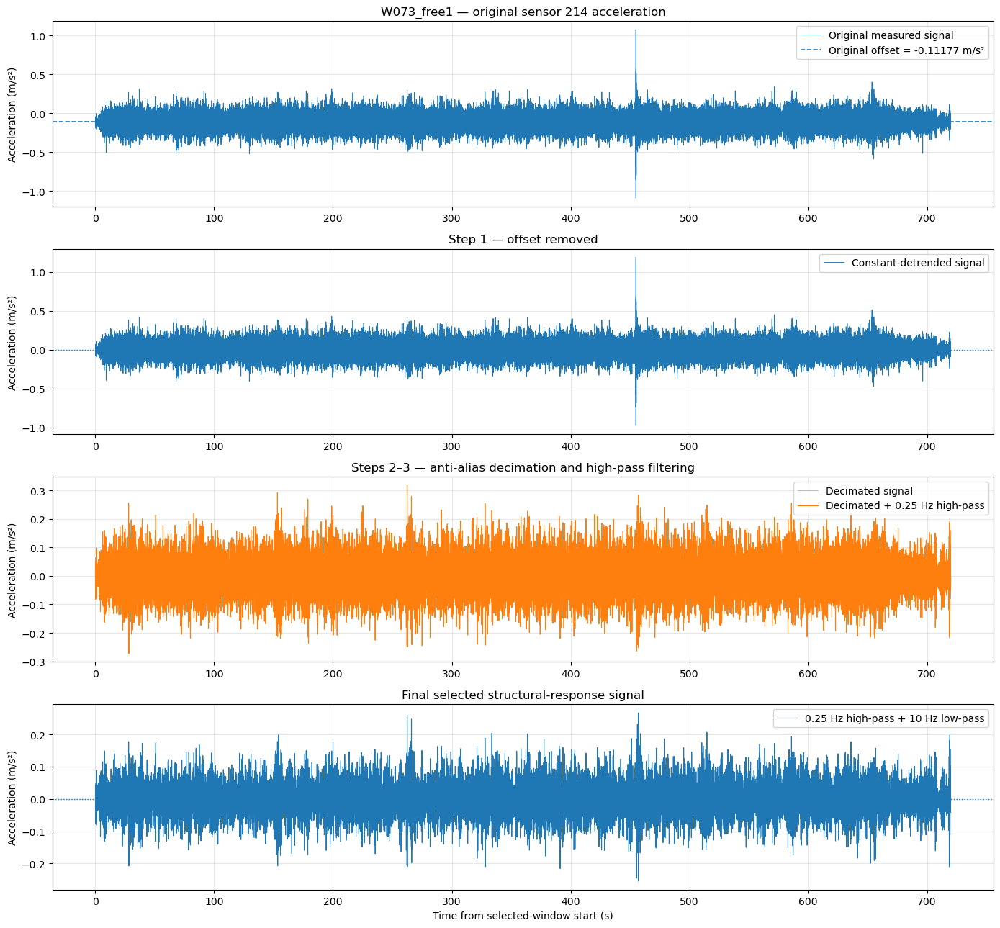

In [35]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import (
    butter,
    decimate,
    detrend,
    sosfiltfilt,
)


# ================================================================
# FILE
# ================================================================

mat_file = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set\W073_free1.mat"
)

if not mat_file.exists():
    raise FileNotFoundError(
        f"File not found:\n{mat_file}"
    )


# ================================================================
# PROCESSING SETTINGS
# ================================================================

REPORTED_DURATION_S = 720.0

DECIMATION_FACTOR = 2

HIGHPASS_CUTOFF_HZ = 0.25
HIGHPASS_ORDER = 5

LOWPASS_CUTOFF_HZ = 10.0

# The paper does not state the order of the final 10 Hz low-pass
# filter. A fourth-order Butterworth filter is used here.
LOWPASS_ORDER = 4

# Relevant event window.
#
# Leave WINDOW_END_S = None to retain the full record.
# Example:
# WINDOW_START_S = 120.0
# WINDOW_END_S = 240.0
WINDOW_START_S = 0.0
WINDOW_END_S = None


# ================================================================
# INSPECT AND LOAD MATLAB v7.3 FILE
# ================================================================

with h5py.File(mat_file, "r") as f:

    print("Top-level entries:")

    for key in f.keys():
        print(" ", key)

    print("\nStructural acceleration entries:")

    for key in f["structural_accelerations"].keys():

        obj = f["structural_accelerations"][key]

        print(
            f"  {key}: "
            f"shape={getattr(obj, 'shape', None)}, "
            f"type={type(obj)}"
        )

    z_accelerations = np.array(
        f["structural_accelerations"]["z"]
    )

    sensor_numbers = np.array(
        f["structural_accelerations"]["sensors"]
    ).squeeze()


# ================================================================
# CLEAN SENSOR NUMBERS
# ================================================================

sensor_numbers = (
    sensor_numbers
    .astype(int)
    .ravel()
)

print("\nRaw z shape:", z_accelerations.shape)
print("Sensors:", sensor_numbers)


# ================================================================
# FIX MATLAB/HDF5 ORIENTATION
# ================================================================
# Required orientation:
#     rows    = time samples
#     columns = sensors

number_of_sensors = len(
    sensor_numbers
)

if z_accelerations.shape[1] == number_of_sensors:

    pass

elif z_accelerations.shape[0] == number_of_sensors:

    z_accelerations = z_accelerations.T

else:

    raise ValueError(
        "Could not match the acceleration matrix to the sensor list.\n"
        f"Acceleration shape: {z_accelerations.shape}\n"
        f"Number of sensors: {number_of_sensors}"
    )

print(
    "Corrected z shape:",
    z_accelerations.shape,
)


# ================================================================
# EXTRACT SENSOR 214
# ================================================================

target_sensor = 214

matching_indices = np.where(
    sensor_numbers == target_sensor
)[0]

if len(matching_indices) == 0:

    raise ValueError(
        f"Sensor {target_sensor} was not found.\n"
        f"Available sensors: {sensor_numbers.tolist()}"
    )

sensor_column = int(
    matching_indices[0]
)

acceleration_original = np.asarray(
    z_accelerations[
        :,
        sensor_column,
    ],
    dtype=float,
).copy()

print(
    f"Sensor {target_sensor} is column {sensor_column} in Python "
    f"and column {sensor_column + 1} in MATLAB."
)


# ================================================================
# ORIGINAL SAMPLING INFORMATION
# ================================================================

number_of_original_samples = len(
    acceleration_original
)

original_dt = (
    REPORTED_DURATION_S
    / number_of_original_samples
)

original_sampling_frequency = (
    1.0
    / original_dt
)

original_time = (
    np.arange(
        number_of_original_samples
    )
    / original_sampling_frequency
)

print("\nOriginal sampling information")
print("=============================")

print(
    f"Original samples              = "
    f"{number_of_original_samples}"
)

print(
    f"Reported duration             = "
    f"{REPORTED_DURATION_S:.3f} s"
)

print(
    f"Original dt                   = "
    f"{original_dt:.6f} s"
)

print(
    f"Original sampling frequency   = "
    f"{original_sampling_frequency:.3f} Hz"
)


# ================================================================
# STEP 1: REMOVE OFFSET / CONSTANT DETREND
# ================================================================

measured_offset = float(
    np.mean(
        acceleration_original
    )
)

acceleration_detrended = detrend(
    acceleration_original,
    type="constant",
)

print("\nStep 1: constant detrend")
print("========================")

print(
    f"Measured original offset      = "
    f"{measured_offset:.8f} m/s²"
)

print(
    f"Mean after detrending         = "
    f"{np.mean(acceleration_detrended):.3e} m/s²"
)


# ================================================================
# STEP 2: ANTI-ALIAS FILTERING AND DECIMATION BY 2
# ================================================================
# scipy.signal.decimate performs:
#     1. anti-alias low-pass filtering;
#     2. downsampling by DECIMATION_FACTOR.
#
# zero_phase=True avoids a net time shift.

acceleration_decimated = decimate(
    acceleration_detrended,
    q=DECIMATION_FACTOR,
    ftype="iir",
    zero_phase=True,
)

decimated_sampling_frequency = (
    original_sampling_frequency
    / DECIMATION_FACTOR
)

decimated_dt = (
    1.0
    / decimated_sampling_frequency
)

decimated_nyquist_frequency = (
    0.5
    * decimated_sampling_frequency
)

decimated_time = (
    np.arange(
        len(acceleration_decimated)
    )
    / decimated_sampling_frequency
)

print("\nStep 2: decimation")
print("==================")

print(
    f"Decimation factor             = "
    f"{DECIMATION_FACTOR}"
)

print(
    f"Decimated samples             = "
    f"{len(acceleration_decimated)}"
)

print(
    f"Decimated sampling frequency  = "
    f"{decimated_sampling_frequency:.3f} Hz"
)

print(
    f"Decimated Nyquist frequency   = "
    f"{decimated_nyquist_frequency:.3f} Hz"
)

print(
    "Anti-alias low-pass filtering = "
    "applied internally by scipy.signal.decimate"
)

if not np.isclose(
    decimated_sampling_frequency,
    100.0,
    rtol=0.01,
):

    warnings.warn(
        "The decimated sampling frequency is not approximately "
        "100 Hz. Check the reported duration or original sample count."
    )


# ================================================================
# CHECK FILTER CUTOFF FREQUENCIES
# ================================================================

if HIGHPASS_CUTOFF_HZ <= 0.0:

    raise ValueError(
        "The high-pass cutoff frequency must be greater than zero."
    )

if HIGHPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"High-pass cutoff ({HIGHPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )

if LOWPASS_CUTOFF_HZ <= HIGHPASS_CUTOFF_HZ:

    raise ValueError(
        "The low-pass cutoff must be greater than the "
        "high-pass cutoff."
    )

if LOWPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"Low-pass cutoff ({LOWPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )


# ================================================================
# STEP 3: FIFTH-ORDER 0.25 Hz BUTTERWORTH HIGH-PASS FILTER
# ================================================================

highpass_sos = butter(
    N=HIGHPASS_ORDER,
    Wn=HIGHPASS_CUTOFF_HZ,
    btype="highpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_highpassed = sosfiltfilt(
    highpass_sos,
    acceleration_decimated,
)

print("\nStep 3: high-pass filtering")
print("===========================")

print(
    f"High-pass filter              = "
    f"{HIGHPASS_ORDER}th-order Butterworth"
)

print(
    f"High-pass cutoff              = "
    f"{HIGHPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "High-pass phase treatment     = "
    "zero phase using sosfiltfilt"
)


# ================================================================
# STEP 4: 10 Hz BUTTERWORTH LOW-PASS FILTER
# ================================================================
# This is the later structural-response low-pass filter.
# It is different from the anti-alias filter used during decimation.

lowpass_sos = butter(
    N=LOWPASS_ORDER,
    Wn=LOWPASS_CUTOFF_HZ,
    btype="lowpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_processed_full = sosfiltfilt(
    lowpass_sos,
    acceleration_highpassed,
)

# Remove any tiny numerical residual mean.
acceleration_processed_full -= np.mean(
    acceleration_processed_full
)

print("\nStep 4: low-pass filtering")
print("==========================")

print(
    f"Low-pass filter               = "
    f"{LOWPASS_ORDER}th-order Butterworth"
)

print(
    f"Low-pass cutoff               = "
    f"{LOWPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "Low-pass phase treatment      = "
    "zero phase using sosfiltfilt"
)

print(
    f"Final nominal passband        = "
    f"{HIGHPASS_CUTOFF_HZ:.2f}–"
    f"{LOWPASS_CUTOFF_HZ:.2f} Hz"
)


# ================================================================
# STEP 5: SELECT RELEVANT EVENT WINDOW
# ================================================================
# Filtering is applied before slicing the event window to reduce
# artificial edge effects at the selected event boundaries.

if WINDOW_END_S is None:

    window_end_s = float(
        decimated_time[-1]
        + decimated_dt
    )

else:

    window_end_s = float(
        WINDOW_END_S
    )

window_start_s = float(
    WINDOW_START_S
)

if window_start_s < 0.0:

    raise ValueError(
        "WINDOW_START_S cannot be negative."
    )

if window_end_s <= window_start_s:

    raise ValueError(
        "WINDOW_END_S must be greater than WINDOW_START_S."
    )

window_mask = (
    (decimated_time >= window_start_s)
    & (decimated_time < window_end_s)
)

if not np.any(window_mask):

    raise ValueError(
        "The selected event window contains no samples."
    )

time_selected = (
    decimated_time[
        window_mask
    ]
    - window_start_s
)

acceleration_selected = (
    acceleration_processed_full[
        window_mask
    ]
)

print("\nStep 5: event window")
print("====================")

print(
    f"Window start                  = "
    f"{window_start_s:.3f} s"
)

print(
    f"Window end                    = "
    f"{window_end_s:.3f} s"
)

print(
    f"Selected samples              = "
    f"{len(acceleration_selected)}"
)

print(
    f"Selected duration             = "
    f"{len(acceleration_selected) / decimated_sampling_frequency:.3f} s"
)


# ================================================================
# RESPONSE MEASURES FOR FINAL SELECTED SIGNAL
# ================================================================

filtered_peak_absolute = float(
    np.max(
        np.abs(
            acceleration_selected
        )
    )
)

filtered_p95_absolute = float(
    np.percentile(
        np.abs(
            acceleration_selected
        ),
        95,
    )
)

filtered_rms = float(
    np.sqrt(
        np.mean(
            acceleration_selected**2
        )
    )
)

print("\nFinal response measures")
print("=======================")

print(
    f"Final signal mean             = "
    f"{np.mean(acceleration_selected):.3e} m/s²"
)

print(
    f"Peak absolute                 = "
    f"{filtered_peak_absolute:.6f} m/s²"
)

print(
    f"P95 absolute                  = "
    f"{filtered_p95_absolute:.6f} m/s²"
)

print(
    f"RMS                           = "
    f"{filtered_rms:.6f} m/s²"
)


# ================================================================
# PLOT PROCESSING STAGES
# ================================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(
        14,
        13,
    ),
)


# ------------------------------------------------
# Panel 1: original raw signal
# ------------------------------------------------

axes[0].plot(
    original_time,
    acceleration_original,
    linewidth=0.65,
    label="Original measured signal",
)

axes[0].axhline(
    measured_offset,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Original offset = "
        f"{measured_offset:.5f} m/s²"
    ),
)

axes[0].set_ylabel(
    "Acceleration (m/s²)"
)

axes[0].set_title(
    "W073_free1 — original sensor 214 acceleration"
)

axes[0].grid(
    True,
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------
# Panel 2: detrended signal
# ------------------------------------------------

axes[1].plot(
    original_time,
    acceleration_detrended,
    linewidth=0.65,
    label="Constant-detrended signal",
)

axes[1].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[1].set_ylabel(
    "Acceleration (m/s²)"
)

axes[1].set_title(
    "Step 1 — offset removed"
)

axes[1].grid(
    True,
    alpha=0.3,
)

axes[1].legend()


# ------------------------------------------------
# Panel 3: decimated and high-pass-filtered
# ------------------------------------------------

axes[2].plot(
    decimated_time,
    acceleration_decimated,
    linewidth=0.55,
    alpha=0.55,
    label="Decimated signal",
)

axes[2].plot(
    decimated_time,
    acceleration_highpassed,
    linewidth=0.8,
    label="Decimated + 0.25 Hz high-pass",
)

axes[2].set_ylabel(
    "Acceleration (m/s²)"
)

axes[2].set_title(
    "Steps 2–3 — anti-alias decimation and high-pass filtering"
)

axes[2].grid(
    True,
    alpha=0.3,
)

axes[2].legend()


# ------------------------------------------------
# Panel 4: final selected processed signal
# ------------------------------------------------

axes[3].plot(
    time_selected,
    acceleration_selected,
    linewidth=0.8,
    label=(
        "0.25 Hz high-pass + "
        "10 Hz low-pass"
    ),
)

axes[3].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[3].set_xlabel(
    "Time from selected-window start (s)"
)

axes[3].set_ylabel(
    "Acceleration (m/s²)"
)

axes[3].set_title(
    "Final selected structural-response signal"
)

axes[3].grid(
    True,
    alpha=0.3,
)

axes[3].legend()

plt.tight_layout()
plt.show()

Top-level entries:
  #refs#
  body_accelerations
  general
  structural_accelerations
  trajectories

Structural acceleration entries:
  loc_sensors: shape=(2, 10), type=<class 'h5py._hl.dataset.Dataset'>
  sensors: shape=(10, 1), type=<class 'h5py._hl.dataset.Dataset'>
  x: shape=(10, 83274), type=<class 'h5py._hl.dataset.Dataset'>
  y: shape=(10, 83274), type=<class 'h5py._hl.dataset.Dataset'>
  z: shape=(10, 83274), type=<class 'h5py._hl.dataset.Dataset'>

Raw z shape: (10, 83274)
Sensors: [194 213 214 215 491 494 824 825 826 828]
Corrected z shape: (83274, 10)
Sensor 214 is column 2 in Python and column 3 in MATLAB.

Original sampling information
Original samples              = 83274
Reported duration             = 660.000 s
Original dt                   = 0.007926 s
Original sampling frequency   = 126.173 Hz

Step 1: constant detrend
Measured original offset      = -0.11177161 m/s²
Mean after detrending         = -9.551e-18 m/s²

Step 2: decimation
Decimation factor             = 

C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\3909875893.py:322: UserWarning: The decimated sampling frequency is not approximately 100 Hz. Check the reported duration or original sample count.
  warnings.warn(


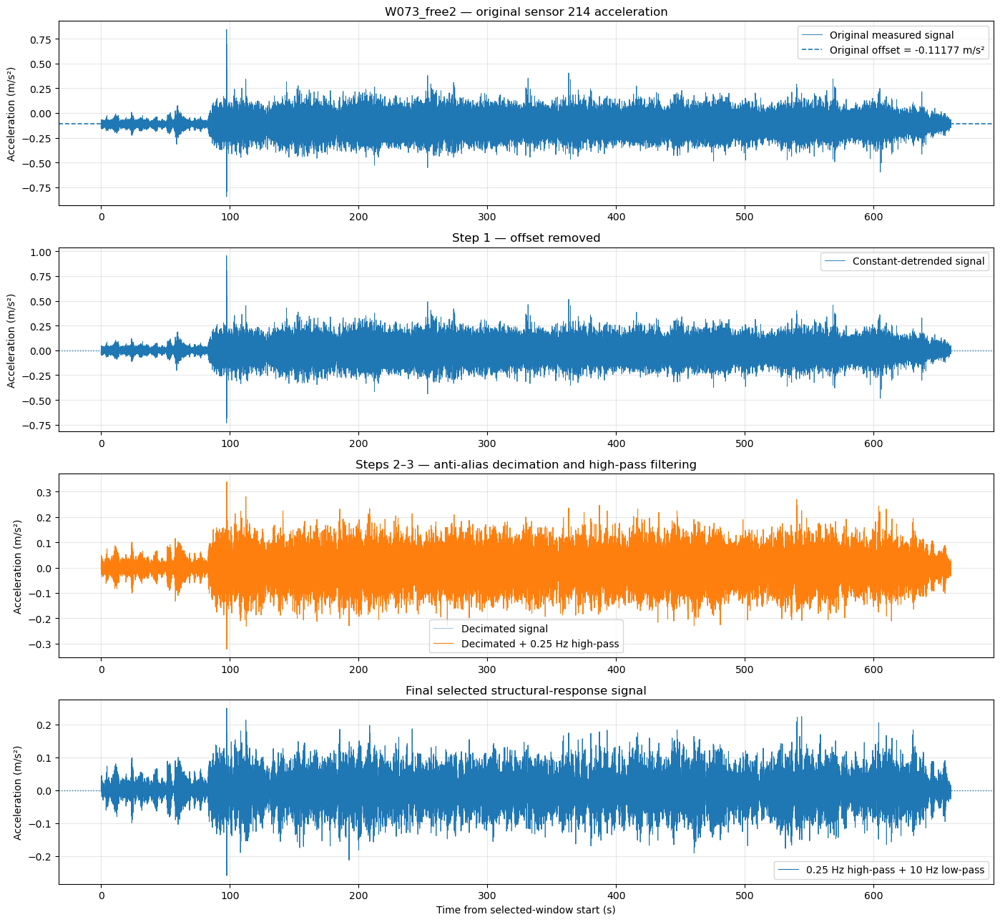

In [63]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import (
    butter,
    decimate,
    detrend,
    sosfiltfilt,
)


# ================================================================
# FILE
# ================================================================

mat_file = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set\W073_free2.mat"
)

if not mat_file.exists():
    raise FileNotFoundError(
        f"File not found:\n{mat_file}"
    )


# ================================================================
# PROCESSING SETTINGS
# ================================================================

REPORTED_DURATION_S = 660.0

DECIMATION_FACTOR = 2

HIGHPASS_CUTOFF_HZ = 0.25
HIGHPASS_ORDER = 5

LOWPASS_CUTOFF_HZ = 10.0

# The paper does not state the order of the final 10 Hz low-pass
# filter. A fourth-order Butterworth filter is used here.
LOWPASS_ORDER = 4

# Relevant event window.
#
# Leave WINDOW_END_S = None to retain the full record.
# Example:
# WINDOW_START_S = 120.0
# WINDOW_END_S = 240.0
WINDOW_START_S = 0.0
WINDOW_END_S = None


# ================================================================
# INSPECT AND LOAD MATLAB v7.3 FILE
# ================================================================

with h5py.File(mat_file, "r") as f:

    print("Top-level entries:")

    for key in f.keys():
        print(" ", key)

    print("\nStructural acceleration entries:")

    for key in f["structural_accelerations"].keys():

        obj = f["structural_accelerations"][key]

        print(
            f"  {key}: "
            f"shape={getattr(obj, 'shape', None)}, "
            f"type={type(obj)}"
        )

    z_accelerations = np.array(
        f["structural_accelerations"]["z"]
    )

    sensor_numbers = np.array(
        f["structural_accelerations"]["sensors"]
    ).squeeze()


# ================================================================
# CLEAN SENSOR NUMBERS
# ================================================================

sensor_numbers = (
    sensor_numbers
    .astype(int)
    .ravel()
)

print("\nRaw z shape:", z_accelerations.shape)
print("Sensors:", sensor_numbers)


# ================================================================
# FIX MATLAB/HDF5 ORIENTATION
# ================================================================
# Required orientation:
#     rows    = time samples
#     columns = sensors

number_of_sensors = len(
    sensor_numbers
)

if z_accelerations.shape[1] == number_of_sensors:

    pass

elif z_accelerations.shape[0] == number_of_sensors:

    z_accelerations = z_accelerations.T

else:

    raise ValueError(
        "Could not match the acceleration matrix to the sensor list.\n"
        f"Acceleration shape: {z_accelerations.shape}\n"
        f"Number of sensors: {number_of_sensors}"
    )

print(
    "Corrected z shape:",
    z_accelerations.shape,
)


# ================================================================
# EXTRACT SENSOR 214
# ================================================================

target_sensor = 214

matching_indices = np.where(
    sensor_numbers == target_sensor
)[0]

if len(matching_indices) == 0:

    raise ValueError(
        f"Sensor {target_sensor} was not found.\n"
        f"Available sensors: {sensor_numbers.tolist()}"
    )

sensor_column = int(
    matching_indices[0]
)

acceleration_original = np.asarray(
    z_accelerations[
        :,
        sensor_column,
    ],
    dtype=float,
).copy()

print(
    f"Sensor {target_sensor} is column {sensor_column} in Python "
    f"and column {sensor_column + 1} in MATLAB."
)


# ================================================================
# ORIGINAL SAMPLING INFORMATION
# ================================================================

number_of_original_samples = len(
    acceleration_original
)

original_dt = (
    REPORTED_DURATION_S
    / number_of_original_samples
)

original_sampling_frequency = (
    1.0
    / original_dt
)

original_time = (
    np.arange(
        number_of_original_samples
    )
    / original_sampling_frequency
)

print("\nOriginal sampling information")
print("=============================")

print(
    f"Original samples              = "
    f"{number_of_original_samples}"
)

print(
    f"Reported duration             = "
    f"{REPORTED_DURATION_S:.3f} s"
)

print(
    f"Original dt                   = "
    f"{original_dt:.6f} s"
)

print(
    f"Original sampling frequency   = "
    f"{original_sampling_frequency:.3f} Hz"
)


# ================================================================
# STEP 1: REMOVE OFFSET / CONSTANT DETREND
# ================================================================

measured_offset = float(
    np.mean(
        acceleration_original
    )
)

acceleration_detrended = detrend(
    acceleration_original,
    type="constant",
)

print("\nStep 1: constant detrend")
print("========================")

print(
    f"Measured original offset      = "
    f"{measured_offset:.8f} m/s²"
)

print(
    f"Mean after detrending         = "
    f"{np.mean(acceleration_detrended):.3e} m/s²"
)


# ================================================================
# STEP 2: ANTI-ALIAS FILTERING AND DECIMATION BY 2
# ================================================================
# scipy.signal.decimate performs:
#     1. anti-alias low-pass filtering;
#     2. downsampling by DECIMATION_FACTOR.
#
# zero_phase=True avoids a net time shift.

acceleration_decimated = decimate(
    acceleration_detrended,
    q=DECIMATION_FACTOR,
    ftype="iir",
    zero_phase=True,
)

decimated_sampling_frequency = (
    original_sampling_frequency
    / DECIMATION_FACTOR
)

decimated_dt = (
    1.0
    / decimated_sampling_frequency
)

decimated_nyquist_frequency = (
    0.5
    * decimated_sampling_frequency
)

decimated_time = (
    np.arange(
        len(acceleration_decimated)
    )
    / decimated_sampling_frequency
)

print("\nStep 2: decimation")
print("==================")

print(
    f"Decimation factor             = "
    f"{DECIMATION_FACTOR}"
)

print(
    f"Decimated samples             = "
    f"{len(acceleration_decimated)}"
)

print(
    f"Decimated sampling frequency  = "
    f"{decimated_sampling_frequency:.3f} Hz"
)

print(
    f"Decimated Nyquist frequency   = "
    f"{decimated_nyquist_frequency:.3f} Hz"
)

print(
    "Anti-alias low-pass filtering = "
    "applied internally by scipy.signal.decimate"
)

if not np.isclose(
    decimated_sampling_frequency,
    100.0,
    rtol=0.01,
):

    warnings.warn(
        "The decimated sampling frequency is not approximately "
        "100 Hz. Check the reported duration or original sample count."
    )


# ================================================================
# CHECK FILTER CUTOFF FREQUENCIES
# ================================================================

if HIGHPASS_CUTOFF_HZ <= 0.0:

    raise ValueError(
        "The high-pass cutoff frequency must be greater than zero."
    )

if HIGHPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"High-pass cutoff ({HIGHPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )

if LOWPASS_CUTOFF_HZ <= HIGHPASS_CUTOFF_HZ:

    raise ValueError(
        "The low-pass cutoff must be greater than the "
        "high-pass cutoff."
    )

if LOWPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"Low-pass cutoff ({LOWPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )


# ================================================================
# STEP 3: FIFTH-ORDER 0.25 Hz BUTTERWORTH HIGH-PASS FILTER
# ================================================================

highpass_sos = butter(
    N=HIGHPASS_ORDER,
    Wn=HIGHPASS_CUTOFF_HZ,
    btype="highpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_highpassed = sosfiltfilt(
    highpass_sos,
    acceleration_decimated,
)

print("\nStep 3: high-pass filtering")
print("===========================")

print(
    f"High-pass filter              = "
    f"{HIGHPASS_ORDER}th-order Butterworth"
)

print(
    f"High-pass cutoff              = "
    f"{HIGHPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "High-pass phase treatment     = "
    "zero phase using sosfiltfilt"
)


# ================================================================
# STEP 4: 10 Hz BUTTERWORTH LOW-PASS FILTER
# ================================================================
# This is the later structural-response low-pass filter.
# It is different from the anti-alias filter used during decimation.

lowpass_sos = butter(
    N=LOWPASS_ORDER,
    Wn=LOWPASS_CUTOFF_HZ,
    btype="lowpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_processed_full = sosfiltfilt(
    lowpass_sos,
    acceleration_highpassed,
)

# Remove any tiny numerical residual mean.
acceleration_processed_full -= np.mean(
    acceleration_processed_full
)

print("\nStep 4: low-pass filtering")
print("==========================")

print(
    f"Low-pass filter               = "
    f"{LOWPASS_ORDER}th-order Butterworth"
)

print(
    f"Low-pass cutoff               = "
    f"{LOWPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "Low-pass phase treatment      = "
    "zero phase using sosfiltfilt"
)

print(
    f"Final nominal passband        = "
    f"{HIGHPASS_CUTOFF_HZ:.2f}–"
    f"{LOWPASS_CUTOFF_HZ:.2f} Hz"
)


# ================================================================
# STEP 5: SELECT RELEVANT EVENT WINDOW
# ================================================================
# Filtering is applied before slicing the event window to reduce
# artificial edge effects at the selected event boundaries.

if WINDOW_END_S is None:

    window_end_s = float(
        decimated_time[-1]
        + decimated_dt
    )

else:

    window_end_s = float(
        WINDOW_END_S
    )

window_start_s = float(
    WINDOW_START_S
)

if window_start_s < 0.0:

    raise ValueError(
        "WINDOW_START_S cannot be negative."
    )

if window_end_s <= window_start_s:

    raise ValueError(
        "WINDOW_END_S must be greater than WINDOW_START_S."
    )

window_mask = (
    (decimated_time >= window_start_s)
    & (decimated_time < window_end_s)
)

if not np.any(window_mask):

    raise ValueError(
        "The selected event window contains no samples."
    )

time_selected = (
    decimated_time[
        window_mask
    ]
    - window_start_s
)

acceleration_selected = (
    acceleration_processed_full[
        window_mask
    ]
)

print("\nStep 5: event window")
print("====================")

print(
    f"Window start                  = "
    f"{window_start_s:.3f} s"
)

print(
    f"Window end                    = "
    f"{window_end_s:.3f} s"
)

print(
    f"Selected samples              = "
    f"{len(acceleration_selected)}"
)

print(
    f"Selected duration             = "
    f"{len(acceleration_selected) / decimated_sampling_frequency:.3f} s"
)


# ================================================================
# RESPONSE MEASURES FOR FINAL SELECTED SIGNAL
# ================================================================

filtered_peak_absolute = float(
    np.max(
        np.abs(
            acceleration_selected
        )
    )
)

filtered_p95_absolute = float(
    np.percentile(
        np.abs(
            acceleration_selected
        ),
        95,
    )
)

filtered_rms = float(
    np.sqrt(
        np.mean(
            acceleration_selected**2
        )
    )
)

print("\nFinal response measures")
print("=======================")

print(
    f"Final signal mean             = "
    f"{np.mean(acceleration_selected):.3e} m/s²"
)

print(
    f"Peak absolute                 = "
    f"{filtered_peak_absolute:.6f} m/s²"
)

print(
    f"P95 absolute                  = "
    f"{filtered_p95_absolute:.6f} m/s²"
)

print(
    f"RMS                           = "
    f"{filtered_rms:.6f} m/s²"
)


# ================================================================
# PLOT PROCESSING STAGES
# ================================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(
        14,
        13,
    ),
)


# ------------------------------------------------
# Panel 1: original raw signal
# ------------------------------------------------

axes[0].plot(
    original_time,
    acceleration_original,
    linewidth=0.65,
    label="Original measured signal",
)

axes[0].axhline(
    measured_offset,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Original offset = "
        f"{measured_offset:.5f} m/s²"
    ),
)

axes[0].set_ylabel(
    "Acceleration (m/s²)"
)

axes[0].set_title(
    "W073_free2 — original sensor 214 acceleration"
)

axes[0].grid(
    True,
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------
# Panel 2: detrended signal
# ------------------------------------------------

axes[1].plot(
    original_time,
    acceleration_detrended,
    linewidth=0.65,
    label="Constant-detrended signal",
)

axes[1].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[1].set_ylabel(
    "Acceleration (m/s²)"
)

axes[1].set_title(
    "Step 1 — offset removed"
)

axes[1].grid(
    True,
    alpha=0.3,
)

axes[1].legend()


# ------------------------------------------------
# Panel 3: decimated and high-pass-filtered
# ------------------------------------------------

axes[2].plot(
    decimated_time,
    acceleration_decimated,
    linewidth=0.55,
    alpha=0.55,
    label="Decimated signal",
)

axes[2].plot(
    decimated_time,
    acceleration_highpassed,
    linewidth=0.8,
    label="Decimated + 0.25 Hz high-pass",
)

axes[2].set_ylabel(
    "Acceleration (m/s²)"
)

axes[2].set_title(
    "Steps 2–3 — anti-alias decimation and high-pass filtering"
)

axes[2].grid(
    True,
    alpha=0.3,
)

axes[2].legend()


# ------------------------------------------------
# Panel 4: final selected processed signal
# ------------------------------------------------

axes[3].plot(
    time_selected,
    acceleration_selected,
    linewidth=0.8,
    label=(
        "0.25 Hz high-pass + "
        "10 Hz low-pass"
    ),
)

axes[3].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[3].set_xlabel(
    "Time from selected-window start (s)"
)

axes[3].set_ylabel(
    "Acceleration (m/s²)"
)

axes[3].set_title(
    "Final selected structural-response signal"
)

axes[3].grid(
    True,
    alpha=0.3,
)

axes[3].legend()

plt.tight_layout()
plt.show()

Top-level entries:
  #refs#
  body_accelerations
  general
  structural_accelerations
  trajectories

Structural acceleration entries:
  loc_sensors: shape=(2, 10), type=<class 'h5py._hl.dataset.Dataset'>
  sensors: shape=(10, 1), type=<class 'h5py._hl.dataset.Dataset'>
  x: shape=(10, 74994), type=<class 'h5py._hl.dataset.Dataset'>
  y: shape=(10, 74994), type=<class 'h5py._hl.dataset.Dataset'>
  z: shape=(10, 74994), type=<class 'h5py._hl.dataset.Dataset'>

Raw z shape: (10, 74994)
Sensors: [194 213 214 215 491 494 824 825 826 828]
Corrected z shape: (74994, 10)
Sensor 214 is column 2 in Python and column 3 in MATLAB.

Original sampling information
Original samples              = 74994
Reported duration             = 649.000 s
Original dt                   = 0.008654 s
Original sampling frequency   = 115.553 Hz

Step 1: constant detrend
Measured original offset      = -0.11209151 m/s²
Mean after detrending         = 1.034e-17 m/s²

Step 2: decimation
Decimation factor             = 2

C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\4119063920.py:322: UserWarning: The decimated sampling frequency is not approximately 100 Hz. Check the reported duration or original sample count.
  warnings.warn(


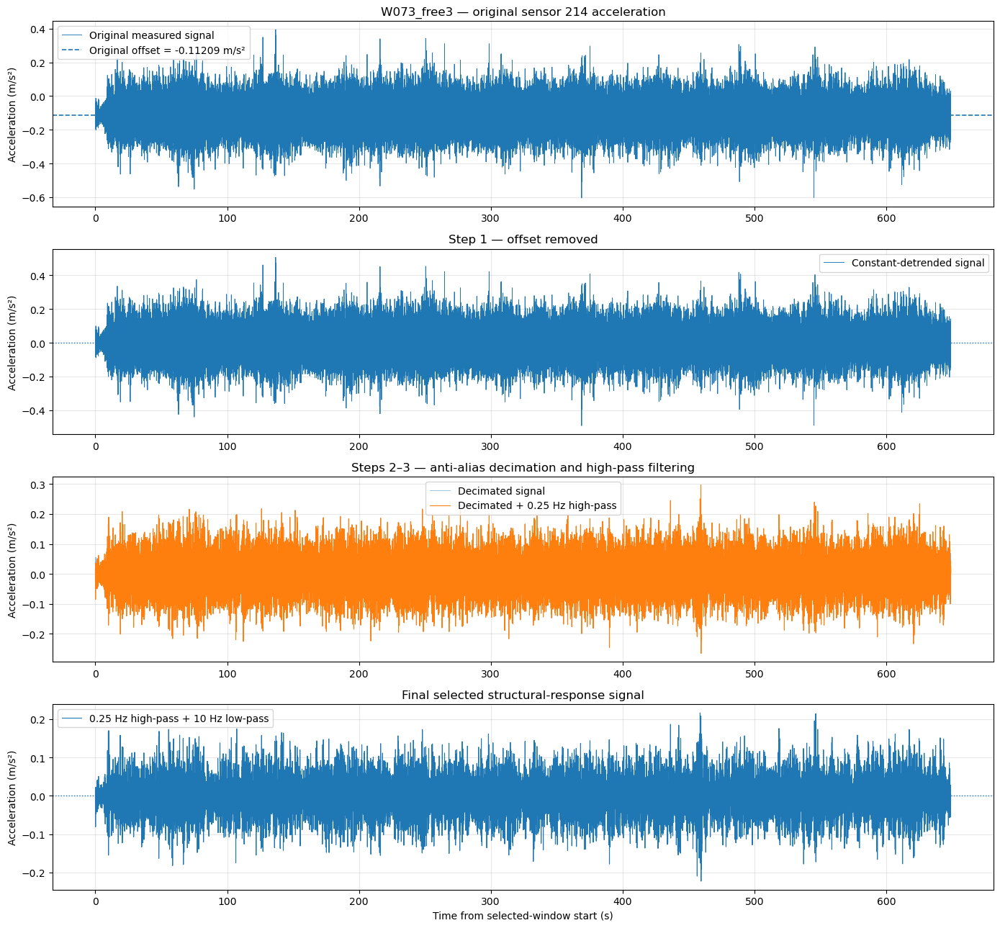

In [64]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import (
    butter,
    decimate,
    detrend,
    sosfiltfilt,
)


# ================================================================
# FILE
# ================================================================

mat_file = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set\W073_free3.mat"
)

if not mat_file.exists():
    raise FileNotFoundError(
        f"File not found:\n{mat_file}"
    )


# ================================================================
# PROCESSING SETTINGS
# ================================================================

REPORTED_DURATION_S = 649.0

DECIMATION_FACTOR = 2

HIGHPASS_CUTOFF_HZ = 0.25
HIGHPASS_ORDER = 5

LOWPASS_CUTOFF_HZ = 10.0

# The paper does not state the order of the final 10 Hz low-pass
# filter. A fourth-order Butterworth filter is used here.
LOWPASS_ORDER = 4

# Relevant event window.
#
# Leave WINDOW_END_S = None to retain the full record.
# Example:
# WINDOW_START_S = 120.0
# WINDOW_END_S = 240.0
WINDOW_START_S = 0.0
WINDOW_END_S = None


# ================================================================
# INSPECT AND LOAD MATLAB v7.3 FILE
# ================================================================

with h5py.File(mat_file, "r") as f:

    print("Top-level entries:")

    for key in f.keys():
        print(" ", key)

    print("\nStructural acceleration entries:")

    for key in f["structural_accelerations"].keys():

        obj = f["structural_accelerations"][key]

        print(
            f"  {key}: "
            f"shape={getattr(obj, 'shape', None)}, "
            f"type={type(obj)}"
        )

    z_accelerations = np.array(
        f["structural_accelerations"]["z"]
    )

    sensor_numbers = np.array(
        f["structural_accelerations"]["sensors"]
    ).squeeze()


# ================================================================
# CLEAN SENSOR NUMBERS
# ================================================================

sensor_numbers = (
    sensor_numbers
    .astype(int)
    .ravel()
)

print("\nRaw z shape:", z_accelerations.shape)
print("Sensors:", sensor_numbers)


# ================================================================
# FIX MATLAB/HDF5 ORIENTATION
# ================================================================
# Required orientation:
#     rows    = time samples
#     columns = sensors

number_of_sensors = len(
    sensor_numbers
)

if z_accelerations.shape[1] == number_of_sensors:

    pass

elif z_accelerations.shape[0] == number_of_sensors:

    z_accelerations = z_accelerations.T

else:

    raise ValueError(
        "Could not match the acceleration matrix to the sensor list.\n"
        f"Acceleration shape: {z_accelerations.shape}\n"
        f"Number of sensors: {number_of_sensors}"
    )

print(
    "Corrected z shape:",
    z_accelerations.shape,
)


# ================================================================
# EXTRACT SENSOR 214
# ================================================================

target_sensor = 214

matching_indices = np.where(
    sensor_numbers == target_sensor
)[0]

if len(matching_indices) == 0:

    raise ValueError(
        f"Sensor {target_sensor} was not found.\n"
        f"Available sensors: {sensor_numbers.tolist()}"
    )

sensor_column = int(
    matching_indices[0]
)

acceleration_original = np.asarray(
    z_accelerations[
        :,
        sensor_column,
    ],
    dtype=float,
).copy()

print(
    f"Sensor {target_sensor} is column {sensor_column} in Python "
    f"and column {sensor_column + 1} in MATLAB."
)


# ================================================================
# ORIGINAL SAMPLING INFORMATION
# ================================================================

number_of_original_samples = len(
    acceleration_original
)

original_dt = (
    REPORTED_DURATION_S
    / number_of_original_samples
)

original_sampling_frequency = (
    1.0
    / original_dt
)

original_time = (
    np.arange(
        number_of_original_samples
    )
    / original_sampling_frequency
)

print("\nOriginal sampling information")
print("=============================")

print(
    f"Original samples              = "
    f"{number_of_original_samples}"
)

print(
    f"Reported duration             = "
    f"{REPORTED_DURATION_S:.3f} s"
)

print(
    f"Original dt                   = "
    f"{original_dt:.6f} s"
)

print(
    f"Original sampling frequency   = "
    f"{original_sampling_frequency:.3f} Hz"
)


# ================================================================
# STEP 1: REMOVE OFFSET / CONSTANT DETREND
# ================================================================

measured_offset = float(
    np.mean(
        acceleration_original
    )
)

acceleration_detrended = detrend(
    acceleration_original,
    type="constant",
)

print("\nStep 1: constant detrend")
print("========================")

print(
    f"Measured original offset      = "
    f"{measured_offset:.8f} m/s²"
)

print(
    f"Mean after detrending         = "
    f"{np.mean(acceleration_detrended):.3e} m/s²"
)


# ================================================================
# STEP 2: ANTI-ALIAS FILTERING AND DECIMATION BY 2
# ================================================================
# scipy.signal.decimate performs:
#     1. anti-alias low-pass filtering;
#     2. downsampling by DECIMATION_FACTOR.
#
# zero_phase=True avoids a net time shift.

acceleration_decimated = decimate(
    acceleration_detrended,
    q=DECIMATION_FACTOR,
    ftype="iir",
    zero_phase=True,
)

decimated_sampling_frequency = (
    original_sampling_frequency
    / DECIMATION_FACTOR
)

decimated_dt = (
    1.0
    / decimated_sampling_frequency
)

decimated_nyquist_frequency = (
    0.5
    * decimated_sampling_frequency
)

decimated_time = (
    np.arange(
        len(acceleration_decimated)
    )
    / decimated_sampling_frequency
)

print("\nStep 2: decimation")
print("==================")

print(
    f"Decimation factor             = "
    f"{DECIMATION_FACTOR}"
)

print(
    f"Decimated samples             = "
    f"{len(acceleration_decimated)}"
)

print(
    f"Decimated sampling frequency  = "
    f"{decimated_sampling_frequency:.3f} Hz"
)

print(
    f"Decimated Nyquist frequency   = "
    f"{decimated_nyquist_frequency:.3f} Hz"
)

print(
    "Anti-alias low-pass filtering = "
    "applied internally by scipy.signal.decimate"
)

if not np.isclose(
    decimated_sampling_frequency,
    100.0,
    rtol=0.01,
):

    warnings.warn(
        "The decimated sampling frequency is not approximately "
        "100 Hz. Check the reported duration or original sample count."
    )


# ================================================================
# CHECK FILTER CUTOFF FREQUENCIES
# ================================================================

if HIGHPASS_CUTOFF_HZ <= 0.0:

    raise ValueError(
        "The high-pass cutoff frequency must be greater than zero."
    )

if HIGHPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"High-pass cutoff ({HIGHPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )

if LOWPASS_CUTOFF_HZ <= HIGHPASS_CUTOFF_HZ:

    raise ValueError(
        "The low-pass cutoff must be greater than the "
        "high-pass cutoff."
    )

if LOWPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"Low-pass cutoff ({LOWPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )


# ================================================================
# STEP 3: FIFTH-ORDER 0.25 Hz BUTTERWORTH HIGH-PASS FILTER
# ================================================================

highpass_sos = butter(
    N=HIGHPASS_ORDER,
    Wn=HIGHPASS_CUTOFF_HZ,
    btype="highpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_highpassed = sosfiltfilt(
    highpass_sos,
    acceleration_decimated,
)

print("\nStep 3: high-pass filtering")
print("===========================")

print(
    f"High-pass filter              = "
    f"{HIGHPASS_ORDER}th-order Butterworth"
)

print(
    f"High-pass cutoff              = "
    f"{HIGHPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "High-pass phase treatment     = "
    "zero phase using sosfiltfilt"
)


# ================================================================
# STEP 4: 10 Hz BUTTERWORTH LOW-PASS FILTER
# ================================================================
# This is the later structural-response low-pass filter.
# It is different from the anti-alias filter used during decimation.

lowpass_sos = butter(
    N=LOWPASS_ORDER,
    Wn=LOWPASS_CUTOFF_HZ,
    btype="lowpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_processed_full = sosfiltfilt(
    lowpass_sos,
    acceleration_highpassed,
)

# Remove any tiny numerical residual mean.
acceleration_processed_full -= np.mean(
    acceleration_processed_full
)

print("\nStep 4: low-pass filtering")
print("==========================")

print(
    f"Low-pass filter               = "
    f"{LOWPASS_ORDER}th-order Butterworth"
)

print(
    f"Low-pass cutoff               = "
    f"{LOWPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "Low-pass phase treatment      = "
    "zero phase using sosfiltfilt"
)

print(
    f"Final nominal passband        = "
    f"{HIGHPASS_CUTOFF_HZ:.2f}–"
    f"{LOWPASS_CUTOFF_HZ:.2f} Hz"
)


# ================================================================
# STEP 5: SELECT RELEVANT EVENT WINDOW
# ================================================================
# Filtering is applied before slicing the event window to reduce
# artificial edge effects at the selected event boundaries.

if WINDOW_END_S is None:

    window_end_s = float(
        decimated_time[-1]
        + decimated_dt
    )

else:

    window_end_s = float(
        WINDOW_END_S
    )

window_start_s = float(
    WINDOW_START_S
)

if window_start_s < 0.0:

    raise ValueError(
        "WINDOW_START_S cannot be negative."
    )

if window_end_s <= window_start_s:

    raise ValueError(
        "WINDOW_END_S must be greater than WINDOW_START_S."
    )

window_mask = (
    (decimated_time >= window_start_s)
    & (decimated_time < window_end_s)
)

if not np.any(window_mask):

    raise ValueError(
        "The selected event window contains no samples."
    )

time_selected = (
    decimated_time[
        window_mask
    ]
    - window_start_s
)

acceleration_selected = (
    acceleration_processed_full[
        window_mask
    ]
)

print("\nStep 5: event window")
print("====================")

print(
    f"Window start                  = "
    f"{window_start_s:.3f} s"
)

print(
    f"Window end                    = "
    f"{window_end_s:.3f} s"
)

print(
    f"Selected samples              = "
    f"{len(acceleration_selected)}"
)

print(
    f"Selected duration             = "
    f"{len(acceleration_selected) / decimated_sampling_frequency:.3f} s"
)


# ================================================================
# RESPONSE MEASURES FOR FINAL SELECTED SIGNAL
# ================================================================

filtered_peak_absolute = float(
    np.max(
        np.abs(
            acceleration_selected
        )
    )
)

filtered_p95_absolute = float(
    np.percentile(
        np.abs(
            acceleration_selected
        ),
        95,
    )
)

filtered_rms = float(
    np.sqrt(
        np.mean(
            acceleration_selected**2
        )
    )
)

print("\nFinal response measures")
print("=======================")

print(
    f"Final signal mean             = "
    f"{np.mean(acceleration_selected):.3e} m/s²"
)

print(
    f"Peak absolute                 = "
    f"{filtered_peak_absolute:.6f} m/s²"
)

print(
    f"P95 absolute                  = "
    f"{filtered_p95_absolute:.6f} m/s²"
)

print(
    f"RMS                           = "
    f"{filtered_rms:.6f} m/s²"
)


# ================================================================
# PLOT PROCESSING STAGES
# ================================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(
        14,
        13,
    ),
)


# ------------------------------------------------
# Panel 1: original raw signal
# ------------------------------------------------

axes[0].plot(
    original_time,
    acceleration_original,
    linewidth=0.65,
    label="Original measured signal",
)

axes[0].axhline(
    measured_offset,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Original offset = "
        f"{measured_offset:.5f} m/s²"
    ),
)

axes[0].set_ylabel(
    "Acceleration (m/s²)"
)

axes[0].set_title(
    "W073_free3 — original sensor 214 acceleration"
)

axes[0].grid(
    True,
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------
# Panel 2: detrended signal
# ------------------------------------------------

axes[1].plot(
    original_time,
    acceleration_detrended,
    linewidth=0.65,
    label="Constant-detrended signal",
)

axes[1].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[1].set_ylabel(
    "Acceleration (m/s²)"
)

axes[1].set_title(
    "Step 1 — offset removed"
)

axes[1].grid(
    True,
    alpha=0.3,
)

axes[1].legend()


# ------------------------------------------------
# Panel 3: decimated and high-pass-filtered
# ------------------------------------------------

axes[2].plot(
    decimated_time,
    acceleration_decimated,
    linewidth=0.55,
    alpha=0.55,
    label="Decimated signal",
)

axes[2].plot(
    decimated_time,
    acceleration_highpassed,
    linewidth=0.8,
    label="Decimated + 0.25 Hz high-pass",
)

axes[2].set_ylabel(
    "Acceleration (m/s²)"
)

axes[2].set_title(
    "Steps 2–3 — anti-alias decimation and high-pass filtering"
)

axes[2].grid(
    True,
    alpha=0.3,
)

axes[2].legend()


# ------------------------------------------------
# Panel 4: final selected processed signal
# ------------------------------------------------

axes[3].plot(
    time_selected,
    acceleration_selected,
    linewidth=0.8,
    label=(
        "0.25 Hz high-pass + "
        "10 Hz low-pass"
    ),
)

axes[3].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[3].set_xlabel(
    "Time from selected-window start (s)"
)

axes[3].set_ylabel(
    "Acceleration (m/s²)"
)

axes[3].set_title(
    "Final selected structural-response signal"
)

axes[3].grid(
    True,
    alpha=0.3,
)

axes[3].legend()

plt.tight_layout()
plt.show()

Top-level entries:
  #refs#
  body_accelerations
  general
  structural_accelerations
  trajectories

Structural acceleration entries:
  loc_sensors: shape=(2, 10), type=<class 'h5py._hl.dataset.Dataset'>
  sensors: shape=(10, 1), type=<class 'h5py._hl.dataset.Dataset'>
  x: shape=(10, 191995), type=<class 'h5py._hl.dataset.Dataset'>
  y: shape=(10, 191995), type=<class 'h5py._hl.dataset.Dataset'>
  z: shape=(10, 191995), type=<class 'h5py._hl.dataset.Dataset'>

Raw z shape: (10, 191995)
Sensors: [194 213 214 215 491 494 824 825 826 828]
Corrected z shape: (191995, 10)
Sensor 214 is column 2 in Python and column 3 in MATLAB.

Original sampling information
Original samples              = 191995
Reported duration             = 1860.000 s
Original dt                   = 0.009688 s
Original sampling frequency   = 103.223 Hz

Step 1: constant detrend
Measured original offset      = -0.11121685 m/s²
Mean after detrending         = -3.756e-17 m/s²

Step 2: decimation
Decimation factor        

C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\1375699427.py:322: UserWarning: The decimated sampling frequency is not approximately 100 Hz. Check the reported duration or original sample count.
  warnings.warn(


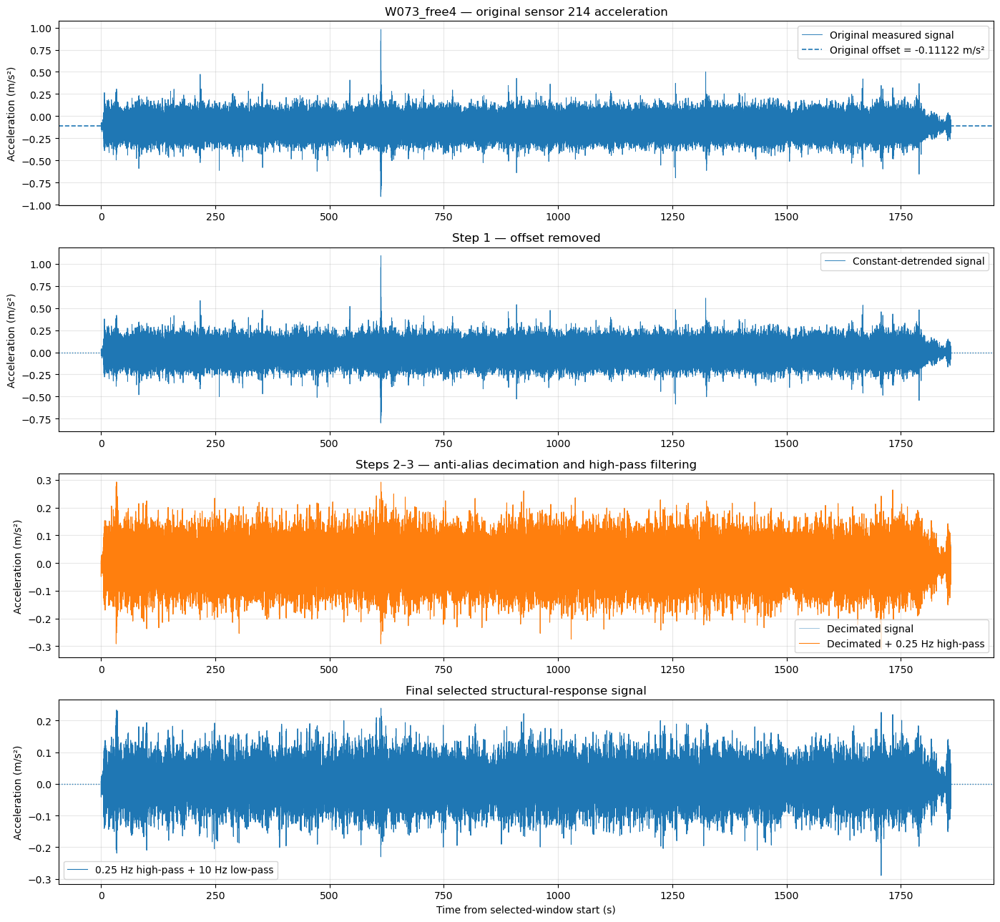

In [65]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import (
    butter,
    decimate,
    detrend,
    sosfiltfilt,
)


# ================================================================
# FILE
# ================================================================

mat_file = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set\W073_free4.mat"
)

if not mat_file.exists():
    raise FileNotFoundError(
        f"File not found:\n{mat_file}"
    )


# ================================================================
# PROCESSING SETTINGS
# ================================================================

REPORTED_DURATION_S = 1860.0

DECIMATION_FACTOR = 2

HIGHPASS_CUTOFF_HZ = 0.25
HIGHPASS_ORDER = 5

LOWPASS_CUTOFF_HZ = 10.0

# The paper does not state the order of the final 10 Hz low-pass
# filter. A fourth-order Butterworth filter is used here.
LOWPASS_ORDER = 4

# Relevant event window.
#
# Leave WINDOW_END_S = None to retain the full record.
# Example:
# WINDOW_START_S = 120.0
# WINDOW_END_S = 240.0
WINDOW_START_S = 0.0
WINDOW_END_S = None


# ================================================================
# INSPECT AND LOAD MATLAB v7.3 FILE
# ================================================================

with h5py.File(mat_file, "r") as f:

    print("Top-level entries:")

    for key in f.keys():
        print(" ", key)

    print("\nStructural acceleration entries:")

    for key in f["structural_accelerations"].keys():

        obj = f["structural_accelerations"][key]

        print(
            f"  {key}: "
            f"shape={getattr(obj, 'shape', None)}, "
            f"type={type(obj)}"
        )

    z_accelerations = np.array(
        f["structural_accelerations"]["z"]
    )

    sensor_numbers = np.array(
        f["structural_accelerations"]["sensors"]
    ).squeeze()


# ================================================================
# CLEAN SENSOR NUMBERS
# ================================================================

sensor_numbers = (
    sensor_numbers
    .astype(int)
    .ravel()
)

print("\nRaw z shape:", z_accelerations.shape)
print("Sensors:", sensor_numbers)


# ================================================================
# FIX MATLAB/HDF5 ORIENTATION
# ================================================================
# Required orientation:
#     rows    = time samples
#     columns = sensors

number_of_sensors = len(
    sensor_numbers
)

if z_accelerations.shape[1] == number_of_sensors:

    pass

elif z_accelerations.shape[0] == number_of_sensors:

    z_accelerations = z_accelerations.T

else:

    raise ValueError(
        "Could not match the acceleration matrix to the sensor list.\n"
        f"Acceleration shape: {z_accelerations.shape}\n"
        f"Number of sensors: {number_of_sensors}"
    )

print(
    "Corrected z shape:",
    z_accelerations.shape,
)


# ================================================================
# EXTRACT SENSOR 214
# ================================================================

target_sensor = 214

matching_indices = np.where(
    sensor_numbers == target_sensor
)[0]

if len(matching_indices) == 0:

    raise ValueError(
        f"Sensor {target_sensor} was not found.\n"
        f"Available sensors: {sensor_numbers.tolist()}"
    )

sensor_column = int(
    matching_indices[0]
)

acceleration_original = np.asarray(
    z_accelerations[
        :,
        sensor_column,
    ],
    dtype=float,
).copy()

print(
    f"Sensor {target_sensor} is column {sensor_column} in Python "
    f"and column {sensor_column + 1} in MATLAB."
)


# ================================================================
# ORIGINAL SAMPLING INFORMATION
# ================================================================

number_of_original_samples = len(
    acceleration_original
)

original_dt = (
    REPORTED_DURATION_S
    / number_of_original_samples
)

original_sampling_frequency = (
    1.0
    / original_dt
)

original_time = (
    np.arange(
        number_of_original_samples
    )
    / original_sampling_frequency
)

print("\nOriginal sampling information")
print("=============================")

print(
    f"Original samples              = "
    f"{number_of_original_samples}"
)

print(
    f"Reported duration             = "
    f"{REPORTED_DURATION_S:.3f} s"
)

print(
    f"Original dt                   = "
    f"{original_dt:.6f} s"
)

print(
    f"Original sampling frequency   = "
    f"{original_sampling_frequency:.3f} Hz"
)


# ================================================================
# STEP 1: REMOVE OFFSET / CONSTANT DETREND
# ================================================================

measured_offset = float(
    np.mean(
        acceleration_original
    )
)

acceleration_detrended = detrend(
    acceleration_original,
    type="constant",
)

print("\nStep 1: constant detrend")
print("========================")

print(
    f"Measured original offset      = "
    f"{measured_offset:.8f} m/s²"
)

print(
    f"Mean after detrending         = "
    f"{np.mean(acceleration_detrended):.3e} m/s²"
)


# ================================================================
# STEP 2: ANTI-ALIAS FILTERING AND DECIMATION BY 2
# ================================================================
# scipy.signal.decimate performs:
#     1. anti-alias low-pass filtering;
#     2. downsampling by DECIMATION_FACTOR.
#
# zero_phase=True avoids a net time shift.

acceleration_decimated = decimate(
    acceleration_detrended,
    q=DECIMATION_FACTOR,
    ftype="iir",
    zero_phase=True,
)

decimated_sampling_frequency = (
    original_sampling_frequency
    / DECIMATION_FACTOR
)

decimated_dt = (
    1.0
    / decimated_sampling_frequency
)

decimated_nyquist_frequency = (
    0.5
    * decimated_sampling_frequency
)

decimated_time = (
    np.arange(
        len(acceleration_decimated)
    )
    / decimated_sampling_frequency
)

print("\nStep 2: decimation")
print("==================")

print(
    f"Decimation factor             = "
    f"{DECIMATION_FACTOR}"
)

print(
    f"Decimated samples             = "
    f"{len(acceleration_decimated)}"
)

print(
    f"Decimated sampling frequency  = "
    f"{decimated_sampling_frequency:.3f} Hz"
)

print(
    f"Decimated Nyquist frequency   = "
    f"{decimated_nyquist_frequency:.3f} Hz"
)

print(
    "Anti-alias low-pass filtering = "
    "applied internally by scipy.signal.decimate"
)

if not np.isclose(
    decimated_sampling_frequency,
    100.0,
    rtol=0.01,
):

    warnings.warn(
        "The decimated sampling frequency is not approximately "
        "100 Hz. Check the reported duration or original sample count."
    )


# ================================================================
# CHECK FILTER CUTOFF FREQUENCIES
# ================================================================

if HIGHPASS_CUTOFF_HZ <= 0.0:

    raise ValueError(
        "The high-pass cutoff frequency must be greater than zero."
    )

if HIGHPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"High-pass cutoff ({HIGHPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )

if LOWPASS_CUTOFF_HZ <= HIGHPASS_CUTOFF_HZ:

    raise ValueError(
        "The low-pass cutoff must be greater than the "
        "high-pass cutoff."
    )

if LOWPASS_CUTOFF_HZ >= decimated_nyquist_frequency:

    raise ValueError(
        f"Low-pass cutoff ({LOWPASS_CUTOFF_HZ:.3f} Hz) must be "
        f"below the decimated Nyquist frequency "
        f"({decimated_nyquist_frequency:.3f} Hz)."
    )


# ================================================================
# STEP 3: FIFTH-ORDER 0.25 Hz BUTTERWORTH HIGH-PASS FILTER
# ================================================================

highpass_sos = butter(
    N=HIGHPASS_ORDER,
    Wn=HIGHPASS_CUTOFF_HZ,
    btype="highpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_highpassed = sosfiltfilt(
    highpass_sos,
    acceleration_decimated,
)

print("\nStep 3: high-pass filtering")
print("===========================")

print(
    f"High-pass filter              = "
    f"{HIGHPASS_ORDER}th-order Butterworth"
)

print(
    f"High-pass cutoff              = "
    f"{HIGHPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "High-pass phase treatment     = "
    "zero phase using sosfiltfilt"
)


# ================================================================
# STEP 4: 10 Hz BUTTERWORTH LOW-PASS FILTER
# ================================================================
# This is the later structural-response low-pass filter.
# It is different from the anti-alias filter used during decimation.

lowpass_sos = butter(
    N=LOWPASS_ORDER,
    Wn=LOWPASS_CUTOFF_HZ,
    btype="lowpass",
    fs=decimated_sampling_frequency,
    output="sos",
)

acceleration_processed_full = sosfiltfilt(
    lowpass_sos,
    acceleration_highpassed,
)

# Remove any tiny numerical residual mean.
acceleration_processed_full -= np.mean(
    acceleration_processed_full
)

print("\nStep 4: low-pass filtering")
print("==========================")

print(
    f"Low-pass filter               = "
    f"{LOWPASS_ORDER}th-order Butterworth"
)

print(
    f"Low-pass cutoff               = "
    f"{LOWPASS_CUTOFF_HZ:.3f} Hz"
)

print(
    "Low-pass phase treatment      = "
    "zero phase using sosfiltfilt"
)

print(
    f"Final nominal passband        = "
    f"{HIGHPASS_CUTOFF_HZ:.2f}–"
    f"{LOWPASS_CUTOFF_HZ:.2f} Hz"
)


# ================================================================
# STEP 5: SELECT RELEVANT EVENT WINDOW
# ================================================================
# Filtering is applied before slicing the event window to reduce
# artificial edge effects at the selected event boundaries.

if WINDOW_END_S is None:

    window_end_s = float(
        decimated_time[-1]
        + decimated_dt
    )

else:

    window_end_s = float(
        WINDOW_END_S
    )

window_start_s = float(
    WINDOW_START_S
)

if window_start_s < 0.0:

    raise ValueError(
        "WINDOW_START_S cannot be negative."
    )

if window_end_s <= window_start_s:

    raise ValueError(
        "WINDOW_END_S must be greater than WINDOW_START_S."
    )

window_mask = (
    (decimated_time >= window_start_s)
    & (decimated_time < window_end_s)
)

if not np.any(window_mask):

    raise ValueError(
        "The selected event window contains no samples."
    )

time_selected = (
    decimated_time[
        window_mask
    ]
    - window_start_s
)

acceleration_selected = (
    acceleration_processed_full[
        window_mask
    ]
)

print("\nStep 5: event window")
print("====================")

print(
    f"Window start                  = "
    f"{window_start_s:.3f} s"
)

print(
    f"Window end                    = "
    f"{window_end_s:.3f} s"
)

print(
    f"Selected samples              = "
    f"{len(acceleration_selected)}"
)

print(
    f"Selected duration             = "
    f"{len(acceleration_selected) / decimated_sampling_frequency:.3f} s"
)


# ================================================================
# RESPONSE MEASURES FOR FINAL SELECTED SIGNAL
# ================================================================

filtered_peak_absolute = float(
    np.max(
        np.abs(
            acceleration_selected
        )
    )
)

filtered_p95_absolute = float(
    np.percentile(
        np.abs(
            acceleration_selected
        ),
        95,
    )
)

filtered_rms = float(
    np.sqrt(
        np.mean(
            acceleration_selected**2
        )
    )
)

print("\nFinal response measures")
print("=======================")

print(
    f"Final signal mean             = "
    f"{np.mean(acceleration_selected):.3e} m/s²"
)

print(
    f"Peak absolute                 = "
    f"{filtered_peak_absolute:.6f} m/s²"
)

print(
    f"P95 absolute                  = "
    f"{filtered_p95_absolute:.6f} m/s²"
)

print(
    f"RMS                           = "
    f"{filtered_rms:.6f} m/s²"
)


# ================================================================
# PLOT PROCESSING STAGES
# ================================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(
        14,
        13,
    ),
)


# ------------------------------------------------
# Panel 1: original raw signal
# ------------------------------------------------

axes[0].plot(
    original_time,
    acceleration_original,
    linewidth=0.65,
    label="Original measured signal",
)

axes[0].axhline(
    measured_offset,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Original offset = "
        f"{measured_offset:.5f} m/s²"
    ),
)

axes[0].set_ylabel(
    "Acceleration (m/s²)"
)

axes[0].set_title(
    "W073_free4 — original sensor 214 acceleration"
)

axes[0].grid(
    True,
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------
# Panel 2: detrended signal
# ------------------------------------------------

axes[1].plot(
    original_time,
    acceleration_detrended,
    linewidth=0.65,
    label="Constant-detrended signal",
)

axes[1].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[1].set_ylabel(
    "Acceleration (m/s²)"
)

axes[1].set_title(
    "Step 1 — offset removed"
)

axes[1].grid(
    True,
    alpha=0.3,
)

axes[1].legend()


# ------------------------------------------------
# Panel 3: decimated and high-pass-filtered
# ------------------------------------------------

axes[2].plot(
    decimated_time,
    acceleration_decimated,
    linewidth=0.55,
    alpha=0.55,
    label="Decimated signal",
)

axes[2].plot(
    decimated_time,
    acceleration_highpassed,
    linewidth=0.8,
    label="Decimated + 0.25 Hz high-pass",
)

axes[2].set_ylabel(
    "Acceleration (m/s²)"
)

axes[2].set_title(
    "Steps 2–3 — anti-alias decimation and high-pass filtering"
)

axes[2].grid(
    True,
    alpha=0.3,
)

axes[2].legend()


# ------------------------------------------------
# Panel 4: final selected processed signal
# ------------------------------------------------

axes[3].plot(
    time_selected,
    acceleration_selected,
    linewidth=0.8,
    label=(
        "0.25 Hz high-pass + "
        "10 Hz low-pass"
    ),
)

axes[3].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

axes[3].set_xlabel(
    "Time from selected-window start (s)"
)

axes[3].set_ylabel(
    "Acceleration (m/s²)"
)

axes[3].set_title(
    "Final selected structural-response signal"
)

axes[3].grid(
    True,
    alpha=0.3,
)

axes[3].legend()

plt.tight_layout()
plt.show()

Loaded 100 Monte Carlo realizations.
Monte Carlo sampling frequency = 100.000 Hz
Applied constant detrending, 0.25 Hz high-pass and 10.0 Hz low-pass filtering to all Monte Carlo histories.

W073_free1
Selected interval              = 100–600 s
Original measured fs           = 111.492 Hz
Final measured fs              = 55.746 Hz
Removed measured offset        = -0.11176574 m/s²
Selected-window mean           = -4.494e-06 m/s²
Measured P95 1-sec RMS         = 0.077785 m/s²
Number of bias values          = 100
Mean bias                      = 0.7530
P5–P95 bias                    = [0.6682, 0.8587]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\1043423330.py:804: UserWarning: W073_free1: final measured sampling frequency is 55.746 Hz, not approximately 100.0 Hz.
  warnings.warn(
C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\1043423330.py:804: UserWarning: W073_free2: final measured sampling frequency is 63.086 Hz, not approximately 100.0 Hz.
  warnings.warn(



W073_free2
Selected interval              = 110–610 s
Original measured fs           = 126.173 Hz
Final measured fs              = 63.086 Hz
Removed measured offset        = -0.11177161 m/s²
Selected-window mean           = -1.908e-05 m/s²
Measured P95 1-sec RMS         = 0.072754 m/s²
Number of bias values          = 100
Mean bias                      = 0.7049
P5–P95 bias                    = [0.6215, 0.8033]

W073_free3
Selected interval              = 100–600 s
Original measured fs           = 115.553 Hz
Final measured fs              = 57.777 Hz
Removed measured offset        = -0.11209151 m/s²
Selected-window mean           = 2.741e-05 m/s²
Measured P95 1-sec RMS         = 0.070181 m/s²
Number of bias values          = 100
Mean bias                      = 0.6794
P5–P95 bias                    = [0.6029, 0.7748]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\1043423330.py:804: UserWarning: W073_free3: final measured sampling frequency is 57.777 Hz, not approximately 100.0 Hz.
  warnings.warn(
C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\1043423330.py:804: UserWarning: W073_free4: final measured sampling frequency is 51.612 Hz, not approximately 100.0 Hz.
  warnings.warn(



W073_free4
Selected interval              = 100–600 s
Original measured fs           = 103.223 Hz
Final measured fs              = 51.612 Hz
Removed measured offset        = -0.11121685 m/s²
Selected-window mean           = 3.449e-05 m/s²
Measured P95 1-sec RMS         = 0.074872 m/s²
Number of bias values          = 100
Mean bias                      = 0.7248
P5–P95 bias                    = [0.6432, 0.8266]

Preprocessed P95 RMS bias summary
      Test    Window  Original measured sampling frequency (Hz)  Final measured sampling frequency (Hz)  Monte Carlo sampling frequency (Hz)  Removed measured offset (m/s²)  Measured selected-window mean (m/s²)  Measured P95 1-sec RMS (m/s²)  Mean simulated P95 RMS (m/s²)  Median simulated P95 RMS (m/s²)  Mean bias  P5 bias  Median bias  P95 bias
W073_free1 100–600 s                                 111.491667                               55.745833                           100.000000                       -0.111766                             -

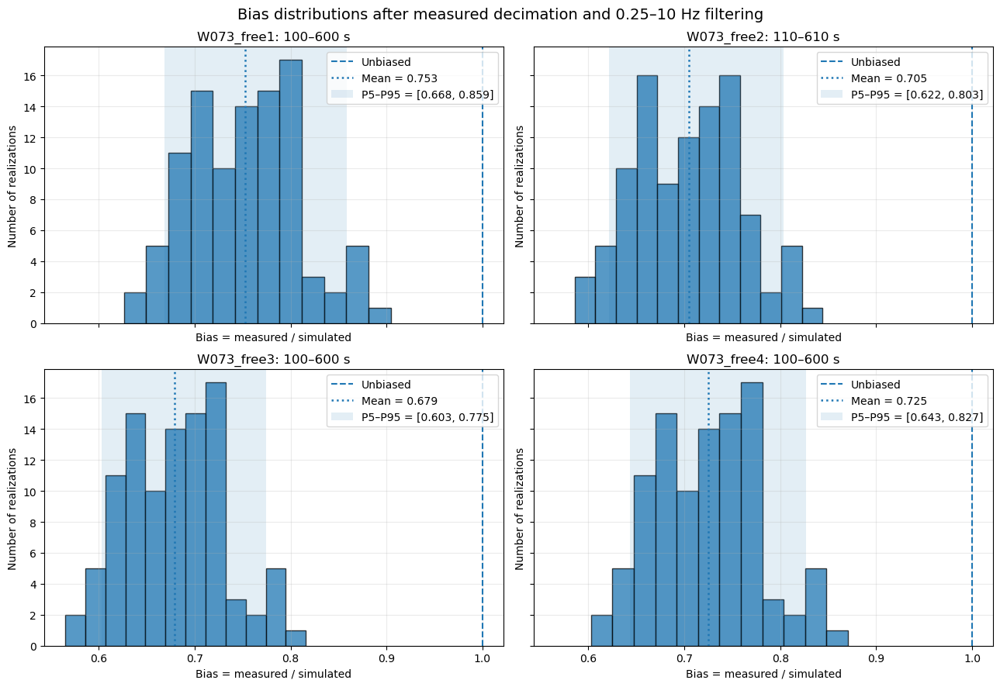

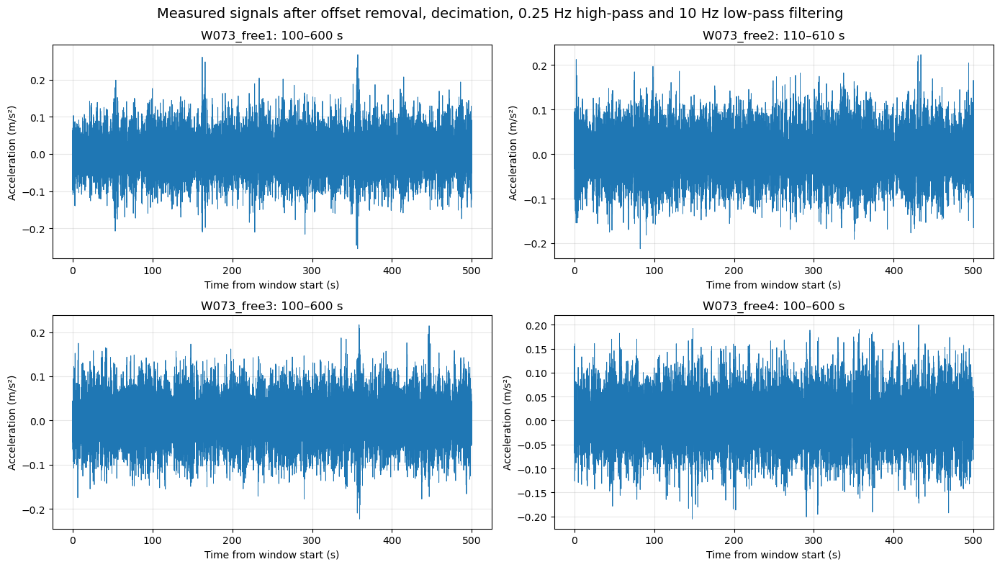


Saved: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\W073_four_experiment_preprocessed_bias_distributions.pkl


In [36]:
import pickle
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.signal import (
    butter,
    decimate,
    detrend,
    sosfiltfilt,
)


# ================================================================
# SETTINGS
# ================================================================

data_folder = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set"
)

# Monte Carlo acceleration histories
mc_file = Path("W73_free2_MC100.pkl")

target_sensor = 214

RMS_WINDOW_SECONDS = 1.0

# ------------------------------------------------
# Measured-signal preprocessing
# ------------------------------------------------
# Original measured records are expected to be approximately 200 Hz.
# They are decimated by 2 to approximately 100 Hz.
MEASURED_DECIMATION_FACTOR = 2

# Fifth-order Butterworth high-pass stated in the paper
HIGHPASS_CUTOFF_HZ = 0.25
HIGHPASS_ORDER = 5

# Later structural-response low-pass filter
LOWPASS_CUTOFF_HZ = 10.0

# The paper excerpt does not state the order of the 10 Hz filter.
# Keep this at 4 unless another source gives the actual order.
LOWPASS_ORDER = 4

EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ = 100.0

# ------------------------------------------------
# Actual durations and selected comparison windows
# ------------------------------------------------

test_settings = {
    1: {
        "duration": 720.0,
        "window": (100.0, 600.0),
    },
    2: {
        "duration": 660.0,
        "window": (110.0, 610.0),
    },
    3: {
        "duration": 649.0,
        "window": (100.0, 600.0),
    },
    4: {
        "duration": 1860.0,
        "window": (100.0, 600.0),
    },
}


# ================================================================
# MOVING 1-SECOND RMS
# ================================================================

def calculate_moving_rms(
    acceleration,
    dt,
    window_seconds=1.0,
):

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    if dt <= 0.0:
        raise ValueError(
            "Time step must be positive."
        )

    window_samples = int(
        round(
            window_seconds / dt
        )
    )

    if window_samples < 1:
        raise ValueError(
            "RMS window contains fewer than one sample."
        )

    if len(acceleration) < window_samples:
        raise ValueError(
            "Acceleration history is shorter than the RMS window."
        )

    squared_acceleration = acceleration**2

    cumulative_sum = np.concatenate(
        (
            [0.0],
            np.cumsum(
                squared_acceleration
            ),
        )
    )

    moving_mean_square = (
        cumulative_sum[window_samples:]
        - cumulative_sum[:-window_samples]
    ) / window_samples

    moving_rms = np.sqrt(
        np.maximum(
            moving_mean_square,
            0.0,
        )
    )

    time_rms = (
        np.arange(
            len(moving_rms),
            dtype=float,
        )
        + (window_samples - 1) / 2.0
    ) * dt

    return (
        time_rms,
        moving_rms,
    )


# ================================================================
# HIGH-PASS + LOW-PASS FILTERING
# ================================================================

def apply_structural_response_filters(
    acceleration,
    sampling_frequency,
):
    """
    Apply the final structural-response filters:

        1. fifth-order Butterworth high-pass at 0.25 Hz;
        2. Butterworth low-pass at 10 Hz.

    Both filters are applied forwards and backwards using
    sosfiltfilt, so there is no net phase shift.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze().copy()

    if acceleration.ndim != 1:
        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    if sampling_frequency <= 0.0:
        raise ValueError(
            "Sampling frequency must be positive."
        )

    nyquist_frequency = (
        0.5 * sampling_frequency
    )

    if not (
        0.0
        < HIGHPASS_CUTOFF_HZ
        < LOWPASS_CUTOFF_HZ
        < nyquist_frequency
    ):
        raise ValueError(
            "The filter cutoffs must satisfy:\n"
            "0 < high-pass cutoff < low-pass cutoff < Nyquist.\n"
            f"High-pass = {HIGHPASS_CUTOFF_HZ:.3f} Hz\n"
            f"Low-pass  = {LOWPASS_CUTOFF_HZ:.3f} Hz\n"
            f"Nyquist   = {nyquist_frequency:.3f} Hz"
        )

    highpass_sos = butter(
        N=HIGHPASS_ORDER,
        Wn=HIGHPASS_CUTOFF_HZ,
        btype="highpass",
        fs=sampling_frequency,
        output="sos",
    )

    highpassed = sosfiltfilt(
        highpass_sos,
        acceleration,
    )

    lowpass_sos = butter(
        N=LOWPASS_ORDER,
        Wn=LOWPASS_CUTOFF_HZ,
        btype="lowpass",
        fs=sampling_frequency,
        output="sos",
    )

    processed = sosfiltfilt(
        lowpass_sos,
        highpassed,
    )

    # Remove only the tiny numerical mean remaining after filtering.
    processed -= np.mean(
        processed
    )

    return processed


# ================================================================
# PREPROCESS ONE MEASURED SIGNAL
# ================================================================

def preprocess_measured_signal(
    acceleration,
    duration,
):
    """
    Apply the measured-data preprocessing sequence:

        1. remove the constant offset;
        2. anti-alias filter and decimate by 2;
        3. fifth-order 0.25 Hz Butterworth high-pass;
        4. 10 Hz Butterworth low-pass.

    The comparison window is selected later, after full-record
    filtering, to reduce artificial filter-edge effects.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Measured acceleration must be one-dimensional."
        )

    number_of_original_samples = len(
        acceleration
    )

    original_dt = (
        float(duration)
        / number_of_original_samples
    )

    original_sampling_frequency = (
        1.0 / original_dt
    )

    original_offset = float(
        np.mean(
            acceleration
        )
    )

    acceleration_detrended = detrend(
        acceleration,
        type="constant",
    )

    # scipy.signal.decimate applies anti-alias low-pass filtering
    # before downsampling. zero_phase=True avoids a net time shift.
    acceleration_decimated = decimate(
        acceleration_detrended,
        q=MEASURED_DECIMATION_FACTOR,
        ftype="iir",
        zero_phase=True,
    )

    final_sampling_frequency = (
        original_sampling_frequency
        / MEASURED_DECIMATION_FACTOR
    )

    final_dt = (
        1.0 / final_sampling_frequency
    )

    final_time = (
        np.arange(
            len(acceleration_decimated),
            dtype=float,
        )
        * final_dt
    )

    acceleration_processed = (
        apply_structural_response_filters(
            acceleration=acceleration_decimated,
            sampling_frequency=final_sampling_frequency,
        )
    )

    return {
        "time":
            final_time,

        "acceleration":
            acceleration_processed,

        "dt":
            final_dt,

        "original_offset":
            original_offset,

        "original_sampling_frequency":
            original_sampling_frequency,

        "final_sampling_frequency":
            final_sampling_frequency,
    }


# ================================================================
# PREPROCESS ONE MONTE CARLO SIGNAL
# ================================================================

def preprocess_simulated_signal(
    acceleration,
    dt,
):
    """
    The Monte Carlo histories are already sampled at approximately
    100 Hz when dt = 0.01 s, so they are NOT decimated again.

    They receive the same final analysis passband as the measured
    signals:

        - constant-offset removal;
        - fifth-order 0.25 Hz high-pass;
        - 10 Hz low-pass.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Simulated acceleration must be one-dimensional."
        )

    if dt <= 0.0:
        raise ValueError(
            "Simulation time step must be positive."
        )

    sampled_offset = float(
        np.mean(
            acceleration
        )
    )

    acceleration_detrended = detrend(
        acceleration,
        type="constant",
    )

    sampling_frequency = (
        1.0 / dt
    )

    acceleration_processed = (
        apply_structural_response_filters(
            acceleration=acceleration_detrended,
            sampling_frequency=sampling_frequency,
        )
    )

    return (
        acceleration_processed,
        sampled_offset,
    )


# ================================================================
# SELECT COMPARISON WINDOW
# ================================================================

def select_window(
    time,
    acceleration,
    start_time,
    end_time,
):
    """
    Select [start_time, end_time) from a signal that has already
    been preprocessed over its complete available record.

    No additional mean is removed from the selected window.
    """

    time = np.asarray(
        time,
        dtype=float,
    ).squeeze()

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if len(time) != len(acceleration):
        raise ValueError(
            "Time and acceleration must have the same length."
        )

    mask = (
        (time >= start_time)
        & (time < end_time)
    )

    if not np.any(mask):
        raise ValueError(
            f"No samples exist between "
            f"{start_time:.3f} and {end_time:.3f} seconds."
        )

    selected_time = time[
        mask
    ].copy()

    selected_acceleration = acceleration[
        mask
    ].copy()

    # Reset the selected interval to begin at zero.
    selected_time -= selected_time[0]

    return (
        selected_time,
        selected_acceleration,
    )


# ================================================================
# LOAD ONE MEASURED MATLAB FILE
# ================================================================

def load_measured_sensor(
    mat_file,
    sensor_number,
):

    if not mat_file.exists():
        raise FileNotFoundError(
            f"Measured file not found:\n{mat_file}"
        )

    with h5py.File(
        mat_file,
        "r",
    ) as mat_data:

        z_accelerations = np.asarray(
            mat_data[
                "structural_accelerations"
            ]["z"],
            dtype=float,
        )

        sensor_numbers = np.asarray(
            mat_data[
                "structural_accelerations"
            ]["sensors"]
        ).squeeze().astype(int).ravel()

    number_of_sensors = len(
        sensor_numbers
    )

    # Required final orientation: samples × sensors
    if z_accelerations.shape[1] == number_of_sensors:

        pass

    elif z_accelerations.shape[0] == number_of_sensors:

        z_accelerations = z_accelerations.T

    else:

        raise ValueError(
            f"Could not match acceleration dimensions in "
            f"{mat_file.name}.\n"
            f"Acceleration shape = {z_accelerations.shape}\n"
            f"Number of sensors  = {number_of_sensors}"
        )

    matching_columns = np.where(
        sensor_numbers == sensor_number
    )[0]

    if len(matching_columns) == 0:

        raise ValueError(
            f"Sensor {sensor_number} was not found in "
            f"{mat_file.name}.\n"
            f"Available sensors: {sensor_numbers.tolist()}"
        )

    sensor_column = int(
        matching_columns[0]
    )

    acceleration = z_accelerations[
        :,
        sensor_column,
    ].astype(float).copy()

    return acceleration


# ================================================================
# LOAD MONTE CARLO RESULTS
# ================================================================

if not mc_file.exists():

    raise FileNotFoundError(
        f"Monte Carlo file not found:\n{mc_file.resolve()}"
    )

with open(
    mc_file,
    "rb",
) as file:

    mc_data = pickle.load(
        file
    )

mc_accelerations = np.asarray(
    mc_data[
        "accelerations"
    ],
    dtype=float,
)

if mc_accelerations.ndim == 1:

    mc_accelerations = (
        mc_accelerations[None, :]
    )

if mc_accelerations.ndim != 2:

    raise ValueError(
        "Saved accelerations must have shape "
        "(number_of_simulations, number_of_time_steps)."
    )

number_of_simulations = (
    mc_accelerations.shape[0]
)

mc_hht = float(
    mc_data.get(
        "hht",
        mc_data.get(
            "time_step",
            0.01,
        ),
    )
)

if "time" in mc_data:

    mc_time = np.asarray(
        mc_data[
            "time"
        ],
        dtype=float,
    ).squeeze()

else:

    mc_time = (
        np.arange(
            mc_accelerations.shape[1],
            dtype=float,
        )
        * mc_hht
    )

if len(mc_time) != mc_accelerations.shape[1]:

    raise ValueError(
        "The stored Monte Carlo time vector does not match "
        "the acceleration-history length."
    )

mc_sampling_frequency = (
    1.0 / mc_hht
)

print(
    f"Loaded {number_of_simulations} Monte Carlo realizations."
)

print(
    f"Monte Carlo sampling frequency = "
    f"{mc_sampling_frequency:.3f} Hz"
)

if not np.isclose(
    mc_sampling_frequency,
    EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ,
    rtol=0.01,
):

    warnings.warn(
        "The Monte Carlo sampling frequency is not approximately "
        f"{EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ:.1f} Hz. "
        "The same 0.25–10 Hz filters will still be applied, but "
        "the measured and simulated sampling frequencies differ."
    )


# ================================================================
# PREPROCESS ALL MONTE CARLO HISTORIES
# ================================================================
# Simulated histories are already approximately 100 Hz, so no
# additional decimation is applied.

processed_mc_accelerations = np.empty_like(
    mc_accelerations,
    dtype=float,
)

mc_full_offsets = np.zeros(
    number_of_simulations,
    dtype=float,
)

for simulation_index in range(
    number_of_simulations
):

    (
        processed_mc_accelerations[
            simulation_index
        ],
        mc_full_offsets[
            simulation_index
        ],
    ) = preprocess_simulated_signal(
        acceleration=mc_accelerations[
            simulation_index
        ],
        dt=mc_hht,
    )

print(
    "Applied constant detrending, "
    f"{HIGHPASS_CUTOFF_HZ:.2f} Hz high-pass and "
    f"{LOWPASS_CUTOFF_HZ:.1f} Hz low-pass filtering "
    "to all Monte Carlo histories."
)


# ================================================================
# ANALYSE THE FOUR EXPERIMENTS
# ================================================================

measured_p95_rms = {}
simulated_p95_rms_by_test = {}
bias_distributions = {}

measured_original_offsets = {}
measured_original_sampling_frequencies = {}
measured_final_sampling_frequencies = {}
measured_window_means = {}

measured_processed_windows = {}
measured_window_times = {}

summary_rows = []


for test_number, settings in test_settings.items():

    measured_duration = float(
        settings[
            "duration"
        ]
    )

    start_time, end_time = (
        settings[
            "window"
        ]
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )

    # ------------------------------------------------------------
    # Load measured signal
    # ------------------------------------------------------------

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    # ------------------------------------------------------------
    # Complete measured preprocessing:
    #
    #   offset removal
    #   anti-alias filtering + decimation by 2
    #   fifth-order 0.25 Hz high-pass
    #   10 Hz low-pass
    # ------------------------------------------------------------

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    measured_time_full = (
        measured_processed[
            "time"
        ]
    )

    measured_acceleration_full = (
        measured_processed[
            "acceleration"
        ]
    )

    measured_dt = float(
        measured_processed[
            "dt"
        ]
    )

    measured_original_offset = float(
        measured_processed[
            "original_offset"
        ]
    )

    measured_original_sampling_frequency = float(
        measured_processed[
            "original_sampling_frequency"
        ]
    )

    measured_final_sampling_frequency = float(
        measured_processed[
            "final_sampling_frequency"
        ]
    )

    if not np.isclose(
        measured_final_sampling_frequency,
        EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ,
        rtol=0.01,
    ):

        warnings.warn(
            f"W073_free{test_number}: final measured sampling "
            f"frequency is {measured_final_sampling_frequency:.3f} Hz, "
            f"not approximately "
            f"{EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ:.1f} Hz."
        )

    # ------------------------------------------------------------
    # Select measured comparison window after full-record filtering
    # ------------------------------------------------------------

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_time_full,
        acceleration=measured_acceleration_full,
        start_time=start_time,
        end_time=end_time,
    )

    measured_window_mean = float(
        np.mean(
            measured_acceleration_window
        )
    )

    measured_original_offsets[
        test_number
    ] = measured_original_offset

    measured_original_sampling_frequencies[
        test_number
    ] = measured_original_sampling_frequency

    measured_final_sampling_frequencies[
        test_number
    ] = measured_final_sampling_frequency

    measured_window_means[
        test_number
    ] = measured_window_mean

    measured_processed_windows[
        test_number
    ] = measured_acceleration_window

    measured_window_times[
        test_number
    ] = measured_time_window

    # ------------------------------------------------------------
    # Measured P95 of moving 1-second RMS
    # ------------------------------------------------------------

    (
        measured_rms_time,
        measured_rms_history,
    ) = calculate_moving_rms(
        acceleration=measured_acceleration_window,
        dt=measured_dt,
        window_seconds=RMS_WINDOW_SECONDS,
    )

    measured_p95 = float(
        np.percentile(
            measured_rms_history,
            95,
        )
    )

    measured_p95_rms[
        test_number
    ] = measured_p95

    # ------------------------------------------------------------
    # Simulated P95 RMS values using the same test window
    # ------------------------------------------------------------

    simulated_p95_values = []

    for simulation_index in range(
        number_of_simulations
    ):

        (
            simulated_time_window,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        (
            _,
            simulated_rms_history,
        ) = calculate_moving_rms(
            acceleration=simulated_acceleration_window,
            dt=mc_hht,
            window_seconds=RMS_WINDOW_SECONDS,
        )

        simulated_p95_values.append(
            float(
                np.percentile(
                    simulated_rms_history,
                    95,
                )
            )
        )

    simulated_p95_values = np.asarray(
        simulated_p95_values,
        dtype=float,
    )

    if np.any(
        ~np.isfinite(
            simulated_p95_values
        )
    ):

        raise ValueError(
            f"W073_free{test_number}: at least one simulated "
            "P95 RMS value is not finite."
        )

    if np.any(
        simulated_p95_values <= 0.0
    ):

        raise ValueError(
            f"W073_free{test_number}: at least one simulated "
            "P95 RMS value is zero or negative."
        )

    simulated_p95_rms_by_test[
        test_number
    ] = simulated_p95_values

    # ------------------------------------------------------------
    # Bias distribution
    #
    # Bias > 1: simulation underpredicts measured response.
    # Bias < 1: simulation overpredicts measured response.
    # ------------------------------------------------------------

    test_biases = (
        measured_p95
        / simulated_p95_values
    )

    bias_distributions[
        test_number
    ] = test_biases

    # ------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------

    summary_rows.append(
        {
            "Test":
                f"W073_free{test_number}",

            "Window":
                f"{start_time:.0f}–{end_time:.0f} s",

            "Original measured sampling frequency (Hz)":
                measured_original_sampling_frequency,

            "Final measured sampling frequency (Hz)":
                measured_final_sampling_frequency,

            "Monte Carlo sampling frequency (Hz)":
                mc_sampling_frequency,

            "Removed measured offset (m/s²)":
                measured_original_offset,

            "Measured selected-window mean (m/s²)":
                measured_window_mean,

            "Measured P95 1-sec RMS (m/s²)":
                measured_p95,

            "Mean simulated P95 RMS (m/s²)":
                np.mean(
                    simulated_p95_values
                ),

            "Median simulated P95 RMS (m/s²)":
                np.median(
                    simulated_p95_values
                ),

            "Mean bias":
                np.mean(
                    test_biases
                ),

            "P5 bias":
                np.percentile(
                    test_biases,
                    5,
                ),

            "Median bias":
                np.percentile(
                    test_biases,
                    50,
                ),

            "P95 bias":
                np.percentile(
                    test_biases,
                    95,
                ),
        }
    )

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 45
    )

    print(
        f"Selected interval              = "
        f"{start_time:.0f}–{end_time:.0f} s"
    )

    print(
        f"Original measured fs           = "
        f"{measured_original_sampling_frequency:.3f} Hz"
    )

    print(
        f"Final measured fs              = "
        f"{measured_final_sampling_frequency:.3f} Hz"
    )

    print(
        f"Removed measured offset        = "
        f"{measured_original_offset:.8f} m/s²"
    )

    print(
        f"Selected-window mean           = "
        f"{measured_window_mean:.3e} m/s²"
    )

    print(
        f"Measured P95 1-sec RMS         = "
        f"{measured_p95:.6f} m/s²"
    )

    print(
        f"Number of bias values          = "
        f"{len(test_biases)}"
    )

    print(
        f"Mean bias                      = "
        f"{np.mean(test_biases):.4f}"
    )

    print(
        f"P5–P95 bias                    = "
        f"[{np.percentile(test_biases, 5):.4f}, "
        f"{np.percentile(test_biases, 95):.4f}]"
    )


# ================================================================
# SUMMARY TABLE
# ================================================================

summary_df = pd.DataFrame(
    summary_rows
)

print(
    "\nPreprocessed P95 RMS bias summary"
)

print(
    "================================="
)

print(
    summary_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# ================================================================
# PLOT FOUR BIAS DISTRIBUTIONS
# ================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        13,
        9,
    ),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for plot_index, test_number in enumerate(
    test_settings
):

    ax = axes[
        plot_index
    ]

    biases = bias_distributions[
        test_number
    ]

    mean_value = float(
        np.mean(
            biases
        )
    )

    p5_value = float(
        np.percentile(
            biases,
            5,
        )
    )

    p95_value = float(
        np.percentile(
            biases,
            95,
        )
    )

    ax.hist(
        biases,
        bins=12,
        alpha=0.75,
        edgecolor="black",
    )

    ax.axvline(
        1.0,
        linestyle="--",
        linewidth=1.5,
        label="Unbiased",
    )

    ax.axvline(
        mean_value,
        linestyle=":",
        linewidth=1.8,
        label=f"Mean = {mean_value:.3f}",
    )

    ax.axvspan(
        p5_value,
        p95_value,
        alpha=0.12,
        label=(
            f"P5–P95 = "
            f"[{p5_value:.3f}, {p95_value:.3f}]"
        ),
    )

    start_time, end_time = (
        test_settings[
            test_number
        ]["window"]
    )

    ax.set_title(
        f"W073_free{test_number}: "
        f"{start_time:.0f}–{end_time:.0f} s"
    )

    ax.set_xlabel(
        "Bias = measured / simulated"
    )

    ax.set_ylabel(
        "Number of realizations"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend()

fig.suptitle(
    "Bias distributions after measured decimation and "
    "0.25–10 Hz filtering",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ================================================================
# OPTIONAL: PLOT THE FOUR PROCESSED MEASURED WINDOWS
# ================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        14,
        8,
    ),
)

axes = axes.ravel()

for plot_index, test_number in enumerate(
    test_settings
):

    ax = axes[
        plot_index
    ]

    ax.plot(
        measured_window_times[
            test_number
        ],
        measured_processed_windows[
            test_number
        ],
        linewidth=0.65,
    )

    start_time, end_time = (
        test_settings[
            test_number
        ]["window"]
    )

    ax.set_title(
        f"W073_free{test_number}: "
        f"{start_time:.0f}–{end_time:.0f} s"
    )

    ax.set_xlabel(
        "Time from window start (s)"
    )

    ax.set_ylabel(
        "Acceleration (m/s²)"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

fig.suptitle(
    "Measured signals after offset removal, decimation, "
    "0.25 Hz high-pass and 10 Hz low-pass filtering",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ================================================================
# SAVE FILTERED BIAS RESULTS
# ================================================================

bias_results = {
    "measured_decimation_factor":
        MEASURED_DECIMATION_FACTOR,

    "highpass_cutoff_hz":
        HIGHPASS_CUTOFF_HZ,

    "highpass_order":
        HIGHPASS_ORDER,

    "lowpass_cutoff_hz":
        LOWPASS_CUTOFF_HZ,

    "lowpass_order":
        LOWPASS_ORDER,

    "rms_window_seconds":
        RMS_WINDOW_SECONDS,

    "test_settings":
        test_settings,

    "bias_definition":
        "measured P95 1-sec RMS / simulated P95 1-sec RMS",

    "bias_distributions":
        bias_distributions,

    "measured_p95_rms":
        measured_p95_rms,

    "simulated_p95_rms_by_test":
        simulated_p95_rms_by_test,

    "measured_original_offsets":
        measured_original_offsets,

    "measured_original_sampling_frequencies":
        measured_original_sampling_frequencies,

    "measured_final_sampling_frequencies":
        measured_final_sampling_frequencies,

    "measured_window_means":
        measured_window_means,

    "mc_full_offsets":
        mc_full_offsets,

    "summary":
        summary_df,
}

output_file = Path(
    "W073_four_experiment_preprocessed_bias_distributions.pkl"
)

with open(
    output_file,
    "wb",
) as file:

    pickle.dump(
        bias_results,
        file,
    )

print(
    f"\nSaved: {output_file.resolve()}"
)

Loaded 100 Monte Carlo realizations.
Monte Carlo sampling frequency = 100.000 Hz
Applied constant detrending, 0.25 Hz high-pass and 25.0 Hz low-pass filtering to all Monte Carlo histories.


C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\3272377274.py:876: UserWarning: W073_free1: final measured sampling frequency is 55.746 Hz, not approximately 100.0 Hz.
  warnings.warn(



W073_free1
Selected interval              = 100-600 s
Original measured fs           = 111.492 Hz
Final measured fs              = 55.746 Hz
Removed measured offset        = -0.11176574 m/s²

Peak 1-sec RMS
  Measured value               = 0.133648 m/s²
  Mean bias                    = 0.8788
  P5-P95 bias                  = [0.7164, 1.0581]

Peak absolute acceleration
  Measured value               = 0.315467 m/s²
  Mean bias                    = 1.1622
  P5-P95 bias                  = [0.9981, 1.3474]

P95 absolute acceleration
  Measured value               = 0.127299 m/s²
  Mean bias                    = 0.9641
  P5-P95 bias                  = [0.8632, 1.0657]

W073_free2
Selected interval              = 110-610 s
Original measured fs           = 126.173 Hz
Final measured fs              = 63.086 Hz
Removed measured offset        = -0.11177161 m/s²

Peak 1-sec RMS
  Measured value               = 0.110566 m/s²
  Mean bias                    = 0.7269
  P5-P95 bias                  

C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\3272377274.py:876: UserWarning: W073_free2: final measured sampling frequency is 63.086 Hz, not approximately 100.0 Hz.
  warnings.warn(
C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\3272377274.py:876: UserWarning: W073_free3: final measured sampling frequency is 57.777 Hz, not approximately 100.0 Hz.
  warnings.warn(



W073_free3
Selected interval              = 100-600 s
Original measured fs           = 115.553 Hz
Final measured fs              = 57.777 Hz
Removed measured offset        = -0.11209151 m/s²

Peak 1-sec RMS
  Measured value               = 0.136640 m/s²
  Mean bias                    = 0.8985
  P5-P95 bias                  = [0.7324, 1.0818]

Peak absolute acceleration
  Measured value               = 0.291699 m/s²
  Mean bias                    = 1.0747
  P5-P95 bias                  = [0.9229, 1.2459]

P95 absolute acceleration
  Measured value               = 0.119336 m/s²
  Mean bias                    = 0.9038
  P5-P95 bias                  = [0.8092, 0.9991]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_10812\3272377274.py:876: UserWarning: W073_free4: final measured sampling frequency is 51.612 Hz, not approximately 100.0 Hz.
  warnings.warn(



W073_free4
Selected interval              = 100-600 s
Original measured fs           = 103.223 Hz
Final measured fs              = 51.612 Hz
Removed measured offset        = -0.11121685 m/s²

Peak 1-sec RMS
  Measured value               = 0.117081 m/s²
  Mean bias                    = 0.7699
  P5-P95 bias                  = [0.6276, 0.9269]

Peak absolute acceleration
  Measured value               = 0.253848 m/s²
  Mean bias                    = 0.9352
  P5-P95 bias                  = [0.8032, 1.0843]

P95 absolute acceleration
  Measured value               = 0.120953 m/s²
  Mean bias                    = 0.9160
  P5-P95 bias                  = [0.8202, 1.0126]

Three-measure bias summary
      Test    Window                    Measure  Measured value (m/s²)  Mean simulated value (m/s²)  Median simulated value (m/s²)  Mean bias  P5 bias  Median bias  P95 bias  Original measured fs (Hz)  Final measured fs (Hz)  Monte Carlo fs (Hz)  Removed measured offset (m/s²)
W073_free1 100-600 s

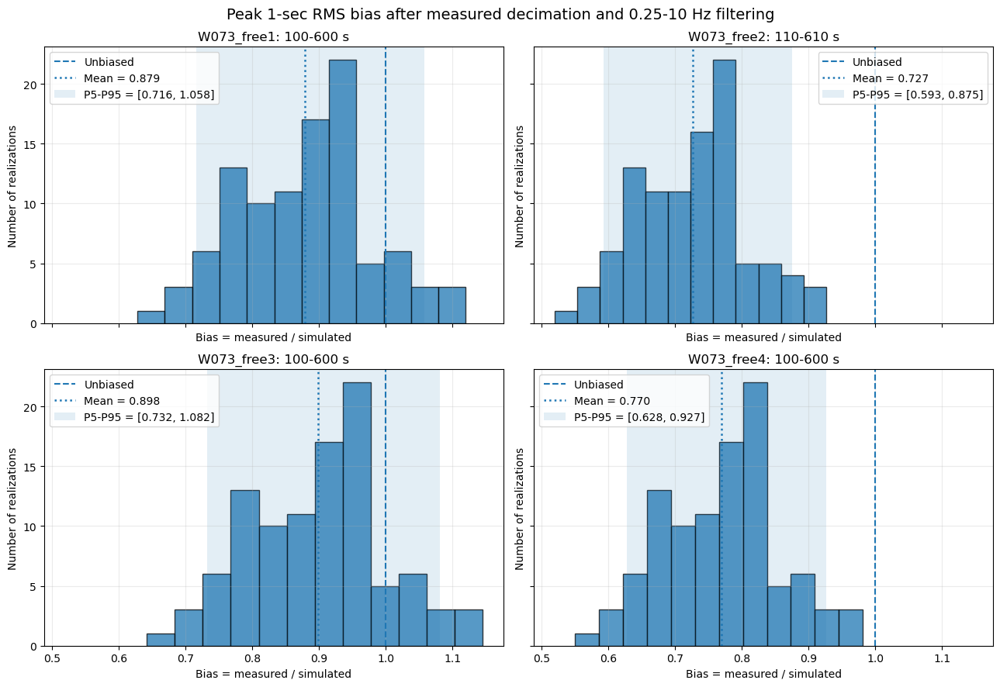

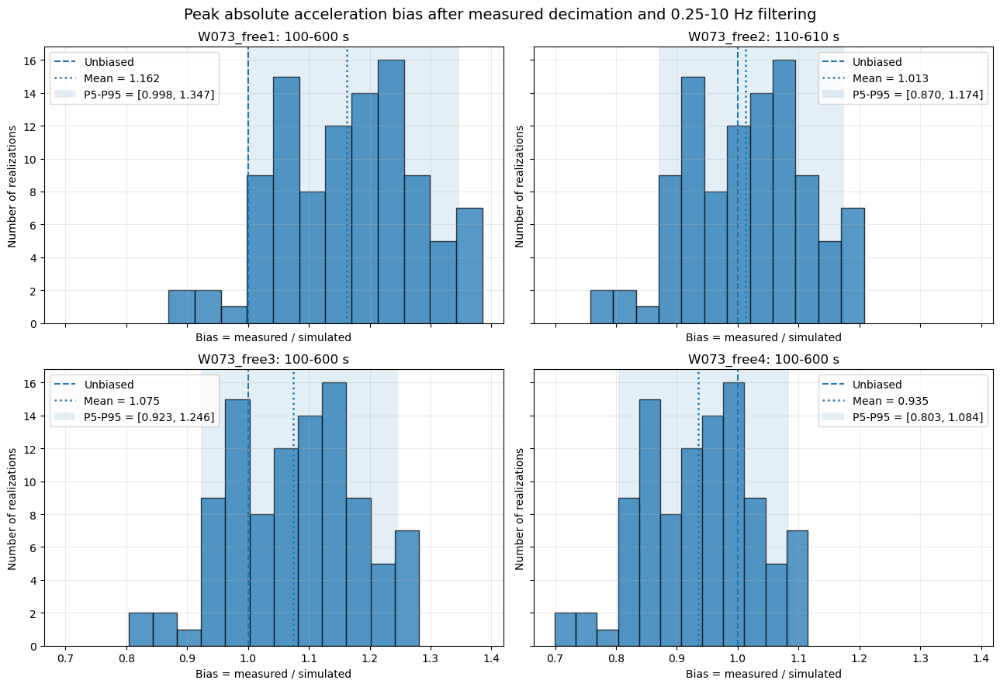

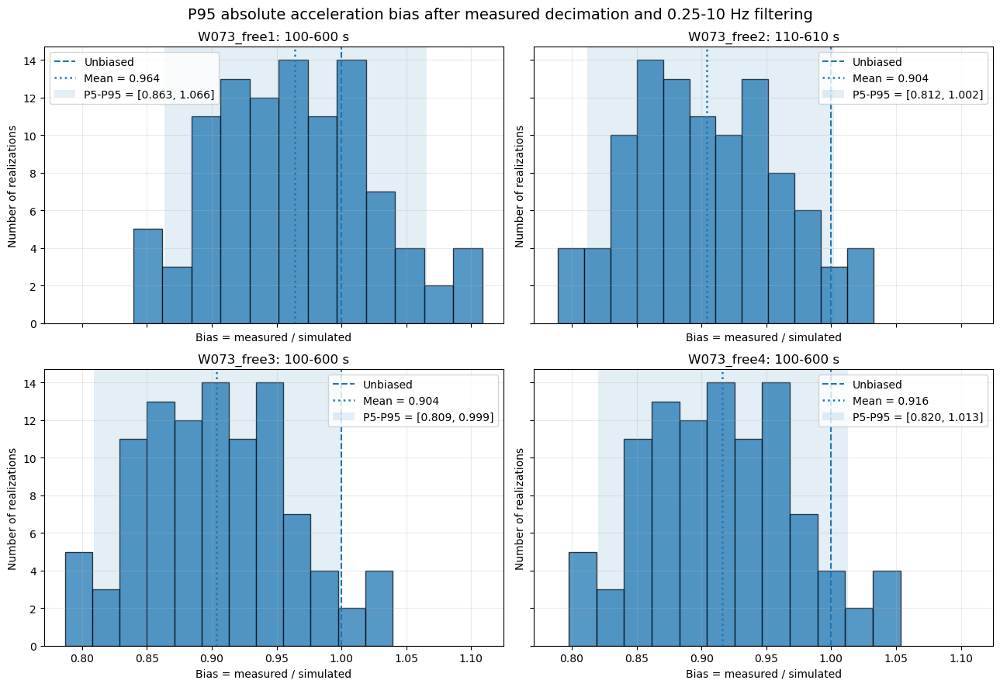

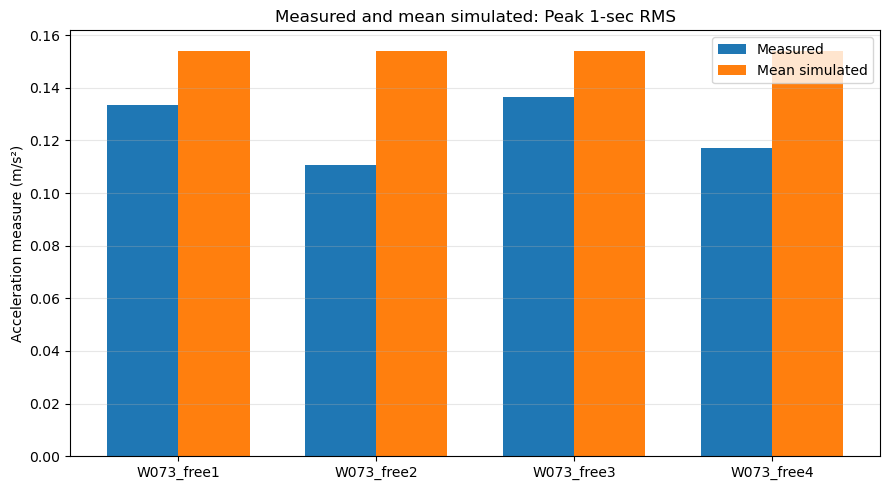

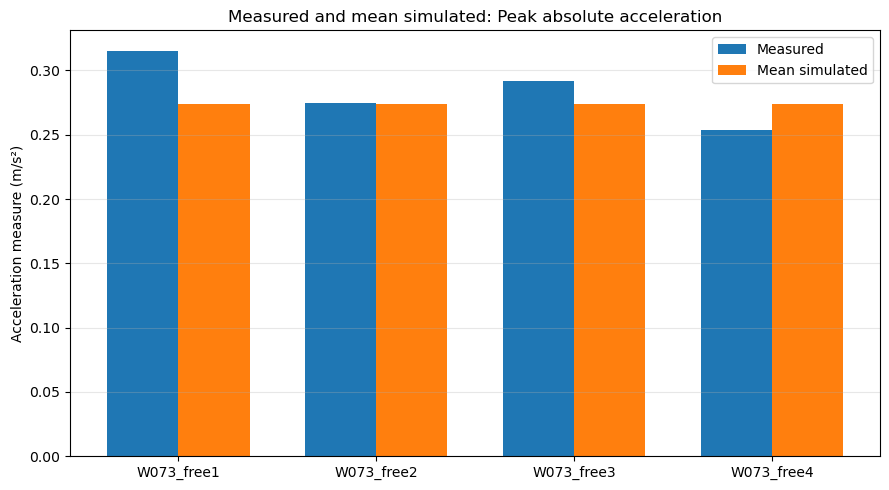

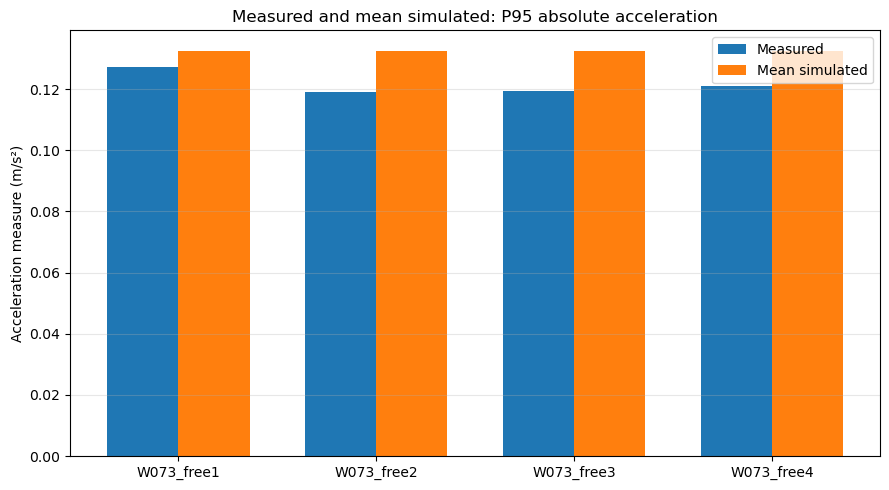

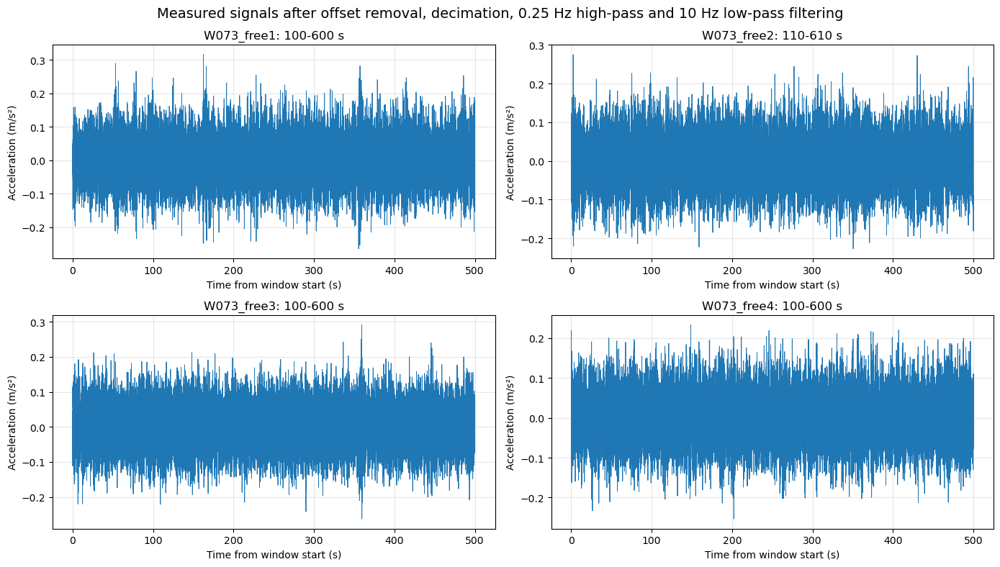


Saved: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\W073_four_experiment_three_measure_bias_distributions.pkl
Saved: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\W073_four_experiment_three_measure_bias_summary.csv


In [46]:
import pickle
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.signal import (
    butter,
    decimate,
    detrend,
    sosfiltfilt,
)


# ================================================================
# SETTINGS
# ================================================================

data_folder = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set"
)

# Monte Carlo acceleration histories
mc_file = Path("W73_free2_MC100.pkl")

target_sensor = 214

RMS_WINDOW_SECONDS = 1.0

# ------------------------------------------------
# Measured-signal preprocessing
# ------------------------------------------------

MEASURED_DECIMATION_FACTOR = 2

HIGHPASS_CUTOFF_HZ = 0.25
HIGHPASS_ORDER = 4

LOWPASS_CUTOFF_HZ = 25.0

# The quoted description does not state the order of the final
# 10 Hz low-pass filter. Keep this at 4 unless the source gives
# another value.
LOWPASS_ORDER = 2

EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ = 100.0


# ------------------------------------------------
# Actual durations and selected comparison windows
# ------------------------------------------------

test_settings = {
    1: {
        "duration": 720.0,
        "window": (100.0, 600.0),
    },
    2: {
        "duration": 660.0,
        "window": (110.0, 610.0),
    },
    3: {
        "duration": 649.0,
        "window": (100.0, 600.0),
    },
    4: {
        "duration": 1860.0,
        "window": (100.0, 600.0),
    },
}


# ================================================================
# RESPONSE-MEASURE NAMES
# ================================================================

MEASURE_PEAK_RMS = "Peak 1-sec RMS"
MEASURE_PEAK_ABS = "Peak absolute acceleration"
MEASURE_P95_ABS = "P95 absolute acceleration"

MEASURE_ORDER = [
    MEASURE_PEAK_RMS,
    MEASURE_PEAK_ABS,
    MEASURE_P95_ABS,
]


# ================================================================
# MOVING 1-SECOND RMS
# ================================================================

def calculate_moving_rms(
    acceleration,
    dt,
    window_seconds=1.0,
):
    """
    Calculate the moving RMS using a rectangular window.

    The returned RMS time corresponds to the centre of each
    moving window.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    if dt <= 0.0:
        raise ValueError(
            "Time step must be positive."
        )

    window_samples = int(
        round(
            window_seconds / dt
        )
    )

    if window_samples < 1:
        raise ValueError(
            "RMS window contains fewer than one sample."
        )

    if len(acceleration) < window_samples:
        raise ValueError(
            "Acceleration history is shorter than the RMS window."
        )

    squared_acceleration = acceleration**2

    cumulative_sum = np.concatenate(
        (
            [0.0],
            np.cumsum(
                squared_acceleration
            ),
        )
    )

    moving_mean_square = (
        cumulative_sum[window_samples:]
        - cumulative_sum[:-window_samples]
    ) / window_samples

    moving_rms = np.sqrt(
        np.maximum(
            moving_mean_square,
            0.0,
        )
    )

    time_rms = (
        np.arange(
            len(moving_rms),
            dtype=float,
        )
        + (window_samples - 1) / 2.0
    ) * dt

    return (
        time_rms,
        moving_rms,
    )


# ================================================================
# THREE RESPONSE MEASURES
# ================================================================

def calculate_response_measures(
    acceleration,
    dt,
):
    """
    Calculate:

        1. peak of the moving 1-second RMS history;
        2. peak absolute acceleration;
        3. 95th percentile of absolute acceleration.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    (
        rms_time,
        moving_rms,
    ) = calculate_moving_rms(
        acceleration=acceleration,
        dt=dt,
        window_seconds=RMS_WINDOW_SECONDS,
    )

    measures = {
        MEASURE_PEAK_RMS:
            float(
                np.max(
                    moving_rms
                )
            ),

        MEASURE_PEAK_ABS:
            float(
                np.max(
                    np.abs(
                        acceleration
                    )
                )
            ),

        MEASURE_P95_ABS:
            float(
                np.percentile(
                    np.abs(
                        acceleration
                    ),
                    95,
                )
            ),
    }

    return {
        "measures":
            measures,

        "rms_time":
            rms_time,

        "moving_rms":
            moving_rms,
    }


# ================================================================
# HIGH-PASS + LOW-PASS FILTERING
# ================================================================

def apply_structural_response_filters(
    acceleration,
    sampling_frequency,
):
    """
    Apply:

        1. fifth-order Butterworth high-pass at 0.25 Hz;
        2. Butterworth low-pass at 10 Hz.

    Both filters are applied forwards and backwards using
    sosfiltfilt, so there is no net phase shift.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze().copy()

    if acceleration.ndim != 1:
        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    if sampling_frequency <= 0.0:
        raise ValueError(
            "Sampling frequency must be positive."
        )

    nyquist_frequency = (
        0.5 * sampling_frequency
    )

    if not (
        0.0
        < HIGHPASS_CUTOFF_HZ
        < LOWPASS_CUTOFF_HZ
        < nyquist_frequency
    ):
        raise ValueError(
            "The filter cutoffs must satisfy:\n"
            "0 < high-pass cutoff < low-pass cutoff < Nyquist.\n"
            f"High-pass = {HIGHPASS_CUTOFF_HZ:.3f} Hz\n"
            f"Low-pass  = {LOWPASS_CUTOFF_HZ:.3f} Hz\n"
            f"Nyquist   = {nyquist_frequency:.3f} Hz"
        )

    highpass_sos = butter(
        N=HIGHPASS_ORDER,
        Wn=HIGHPASS_CUTOFF_HZ,
        btype="highpass",
        fs=sampling_frequency,
        output="sos",
    )

    highpassed = sosfiltfilt(
        highpass_sos,
        acceleration,
    )

    lowpass_sos = butter(
        N=LOWPASS_ORDER,
        Wn=LOWPASS_CUTOFF_HZ,
        btype="lowpass",
        fs=sampling_frequency,
        output="sos",
    )

    processed = sosfiltfilt(
        lowpass_sos,
        highpassed,
    )

    # Remove only a tiny numerical residual mean.
    processed -= np.mean(
        processed
    )

    return processed


# ================================================================
# PREPROCESS ONE MEASURED SIGNAL
# ================================================================

def preprocess_measured_signal(
    acceleration,
    duration,
):
    """
    Measured-data processing sequence:

        1. remove constant offset;
        2. anti-alias filter and decimate by 2;
        3. fifth-order 0.25 Hz Butterworth high-pass;
        4. 10 Hz Butterworth low-pass.

    The comparison window is selected after filtering the complete
    measured record.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Measured acceleration must be one-dimensional."
        )

    number_of_original_samples = len(
        acceleration
    )

    original_dt = (
        float(duration)
        / number_of_original_samples
    )

    original_sampling_frequency = (
        1.0 / original_dt
    )

    original_offset = float(
        np.mean(
            acceleration
        )
    )

    acceleration_detrended = detrend(
        acceleration,
        type="constant",
    )

    # Anti-alias filtering + downsampling.
    acceleration_decimated = decimate(
        acceleration_detrended,
        q=MEASURED_DECIMATION_FACTOR,
        ftype="iir",
        zero_phase=True,
    )

    final_sampling_frequency = (
        original_sampling_frequency
        / MEASURED_DECIMATION_FACTOR
    )

    final_dt = (
        1.0 / final_sampling_frequency
    )

    final_time = (
        np.arange(
            len(acceleration_decimated),
            dtype=float,
        )
        * final_dt
    )

    acceleration_processed = (
        apply_structural_response_filters(
            acceleration=acceleration_decimated,
            sampling_frequency=final_sampling_frequency,
        )
    )

    return {
        "time":
            final_time,

        "acceleration":
            acceleration_processed,

        "dt":
            final_dt,

        "original_offset":
            original_offset,

        "original_sampling_frequency":
            original_sampling_frequency,

        "final_sampling_frequency":
            final_sampling_frequency,
    }


# ================================================================
# PREPROCESS ONE MONTE CARLO SIGNAL
# ================================================================

def preprocess_simulated_signal(
    acceleration,
    dt,
):
    """
    The Monte Carlo signals are assumed to already have a time step
    close to 0.01 s, so they are not decimated again.

    They receive the same final 0.25-10 Hz analysis passband.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:
        raise ValueError(
            "Simulated acceleration must be one-dimensional."
        )

    if dt <= 0.0:
        raise ValueError(
            "Simulation time step must be positive."
        )

    sampled_offset = float(
        np.mean(
            acceleration
        )
    )

    acceleration_detrended = detrend(
        acceleration,
        type="constant",
    )

    sampling_frequency = (
        1.0 / dt
    )

    acceleration_processed = (
        apply_structural_response_filters(
            acceleration=acceleration_detrended,
            sampling_frequency=sampling_frequency,
        )
    )

    return (
        acceleration_processed,
        sampled_offset,
    )


# ================================================================
# SELECT COMPARISON WINDOW
# ================================================================

def select_window(
    time,
    acceleration,
    start_time,
    end_time,
):
    """
    Select [start_time, end_time) after full-record preprocessing.
    """

    time = np.asarray(
        time,
        dtype=float,
    ).squeeze()

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if len(time) != len(acceleration):
        raise ValueError(
            "Time and acceleration must have the same length."
        )

    mask = (
        (time >= start_time)
        & (time < end_time)
    )

    if not np.any(mask):
        raise ValueError(
            f"No samples exist between "
            f"{start_time:.3f} and {end_time:.3f} seconds."
        )

    selected_time = time[
        mask
    ].copy()

    selected_acceleration = acceleration[
        mask
    ].copy()

    selected_time -= selected_time[0]

    return (
        selected_time,
        selected_acceleration,
    )


# ================================================================
# LOAD ONE MEASURED MATLAB FILE
# ================================================================

def load_measured_sensor(
    mat_file,
    sensor_number,
):

    if not mat_file.exists():
        raise FileNotFoundError(
            f"Measured file not found:\n{mat_file}"
        )

    with h5py.File(
        mat_file,
        "r",
    ) as mat_data:

        z_accelerations = np.asarray(
            mat_data[
                "structural_accelerations"
            ]["z"],
            dtype=float,
        )

        sensor_numbers = np.asarray(
            mat_data[
                "structural_accelerations"
            ]["sensors"]
        ).squeeze().astype(int).ravel()

    number_of_sensors = len(
        sensor_numbers
    )

    # Final orientation: samples × sensors
    if z_accelerations.shape[1] == number_of_sensors:

        pass

    elif z_accelerations.shape[0] == number_of_sensors:

        z_accelerations = z_accelerations.T

    else:

        raise ValueError(
            f"Could not match acceleration dimensions in "
            f"{mat_file.name}.\n"
            f"Acceleration shape = {z_accelerations.shape}\n"
            f"Number of sensors  = {number_of_sensors}"
        )

    matching_columns = np.where(
        sensor_numbers == sensor_number
    )[0]

    if len(matching_columns) == 0:

        raise ValueError(
            f"Sensor {sensor_number} was not found in "
            f"{mat_file.name}.\n"
            f"Available sensors: {sensor_numbers.tolist()}"
        )

    sensor_column = int(
        matching_columns[0]
    )

    acceleration = z_accelerations[
        :,
        sensor_column,
    ].astype(float).copy()

    return acceleration


# ================================================================
# LOAD MONTE CARLO RESULTS
# ================================================================

if not mc_file.exists():

    raise FileNotFoundError(
        f"Monte Carlo file not found:\n{mc_file.resolve()}"
    )

with open(
    mc_file,
    "rb",
) as file:

    mc_data = pickle.load(
        file
    )

mc_accelerations = np.asarray(
    mc_data[
        "accelerations"
    ],
    dtype=float,
)

if mc_accelerations.ndim == 1:

    mc_accelerations = (
        mc_accelerations[None, :]
    )

if mc_accelerations.ndim != 2:

    raise ValueError(
        "Saved accelerations must have shape "
        "(number_of_simulations, number_of_time_steps)."
    )

number_of_simulations = (
    mc_accelerations.shape[0]
)

mc_hht = float(
    mc_data.get(
        "hht",
        mc_data.get(
            "time_step",
            0.01,
        ),
    )
)

if "time" in mc_data:

    mc_time = np.asarray(
        mc_data[
            "time"
        ],
        dtype=float,
    ).squeeze()

else:

    mc_time = (
        np.arange(
            mc_accelerations.shape[1],
            dtype=float,
        )
        * mc_hht
    )

if len(mc_time) != mc_accelerations.shape[1]:

    raise ValueError(
        "The stored Monte Carlo time vector does not match "
        "the acceleration-history length."
    )

mc_sampling_frequency = (
    1.0 / mc_hht
)

print(
    f"Loaded {number_of_simulations} Monte Carlo realizations."
)

print(
    f"Monte Carlo sampling frequency = "
    f"{mc_sampling_frequency:.3f} Hz"
)

if not np.isclose(
    mc_sampling_frequency,
    EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ,
    rtol=0.01,
):

    warnings.warn(
        "The Monte Carlo sampling frequency is not approximately "
        f"{EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ:.1f} Hz. "
        "The same 0.25-10 Hz filters will still be applied."
    )


# ================================================================
# PREPROCESS ALL MONTE CARLO HISTORIES
# ================================================================

processed_mc_accelerations = np.empty_like(
    mc_accelerations,
    dtype=float,
)

mc_full_offsets = np.zeros(
    number_of_simulations,
    dtype=float,
)

for simulation_index in range(
    number_of_simulations
):

    (
        processed_mc_accelerations[
            simulation_index
        ],
        mc_full_offsets[
            simulation_index
        ],
    ) = preprocess_simulated_signal(
        acceleration=mc_accelerations[
            simulation_index
        ],
        dt=mc_hht,
    )

print(
    "Applied constant detrending, "
    f"{HIGHPASS_CUTOFF_HZ:.2f} Hz high-pass and "
    f"{LOWPASS_CUTOFF_HZ:.1f} Hz low-pass filtering "
    "to all Monte Carlo histories."
)


# ================================================================
# ANALYSE THE FOUR EXPERIMENTS
# ================================================================

measured_measures_by_test = {}
simulated_measures_by_test = {}
bias_distributions = {}

measured_original_offsets = {}
measured_original_sampling_frequencies = {}
measured_final_sampling_frequencies = {}

measured_processed_windows = {}
measured_window_times = {}

summary_rows = []


for test_number, settings in test_settings.items():

    measured_duration = float(
        settings[
            "duration"
        ]
    )

    start_time, end_time = (
        settings[
            "window"
        ]
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )

    # ------------------------------------------------------------
    # Load and preprocess measured signal
    # ------------------------------------------------------------

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    measured_time_full = (
        measured_processed[
            "time"
        ]
    )

    measured_acceleration_full = (
        measured_processed[
            "acceleration"
        ]
    )

    measured_dt = float(
        measured_processed[
            "dt"
        ]
    )

    measured_original_offset = float(
        measured_processed[
            "original_offset"
        ]
    )

    measured_original_sampling_frequency = float(
        measured_processed[
            "original_sampling_frequency"
        ]
    )

    measured_final_sampling_frequency = float(
        measured_processed[
            "final_sampling_frequency"
        ]
    )

    if not np.isclose(
        measured_final_sampling_frequency,
        EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ,
        rtol=0.01,
    ):

        warnings.warn(
            f"W073_free{test_number}: final measured sampling "
            f"frequency is {measured_final_sampling_frequency:.3f} Hz, "
            f"not approximately "
            f"{EXPECTED_FINAL_SAMPLING_FREQUENCY_HZ:.1f} Hz."
        )

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_time_full,
        acceleration=measured_acceleration_full,
        start_time=start_time,
        end_time=end_time,
    )

    measured_result = (
        calculate_response_measures(
            acceleration=measured_acceleration_window,
            dt=measured_dt,
        )
    )

    measured_measures = (
        measured_result[
            "measures"
        ]
    )

    measured_measures_by_test[
        test_number
    ] = measured_measures

    measured_original_offsets[
        test_number
    ] = measured_original_offset

    measured_original_sampling_frequencies[
        test_number
    ] = measured_original_sampling_frequency

    measured_final_sampling_frequencies[
        test_number
    ] = measured_final_sampling_frequency

    measured_processed_windows[
        test_number
    ] = measured_acceleration_window

    measured_window_times[
        test_number
    ] = measured_time_window

    # ------------------------------------------------------------
    # Calculate the same three measures for every MC realization
    # ------------------------------------------------------------

    simulated_measure_values = {
        measure_name:
            []
        for measure_name in MEASURE_ORDER
    }

    for simulation_index in range(
        number_of_simulations
    ):

        (
            simulated_time_window,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        simulated_result = (
            calculate_response_measures(
                acceleration=simulated_acceleration_window,
                dt=mc_hht,
            )
        )

        simulated_measures = (
            simulated_result[
                "measures"
            ]
        )

        for measure_name in MEASURE_ORDER:

            simulated_measure_values[
                measure_name
            ].append(
                simulated_measures[
                    measure_name
                ]
            )

    for measure_name in MEASURE_ORDER:

        simulated_measure_values[
            measure_name
        ] = np.asarray(
            simulated_measure_values[
                measure_name
            ],
            dtype=float,
        )

        if np.any(
            ~np.isfinite(
                simulated_measure_values[
                    measure_name
                ]
            )
        ):

            raise ValueError(
                f"W073_free{test_number}, {measure_name}: "
                "at least one simulated value is not finite."
            )

        if np.any(
            simulated_measure_values[
                measure_name
            ] <= 0.0
        ):

            raise ValueError(
                f"W073_free{test_number}, {measure_name}: "
                "at least one simulated value is zero or negative."
            )

    simulated_measures_by_test[
        test_number
    ] = simulated_measure_values

    # ------------------------------------------------------------
    # Bias distributions for all three measures
    #
    # Bias = measured / simulated
    # ------------------------------------------------------------

    bias_distributions[
        test_number
    ] = {}

    for measure_name in MEASURE_ORDER:

        measured_value = float(
            measured_measures[
                measure_name
            ]
        )

        simulated_values = (
            simulated_measure_values[
                measure_name
            ]
        )

        biases = (
            measured_value
            / simulated_values
        )

        bias_distributions[
            test_number
        ][
            measure_name
        ] = biases

        summary_rows.append(
            {
                "Test":
                    f"W073_free{test_number}",

                "Window":
                    f"{start_time:.0f}-{end_time:.0f} s",

                "Measure":
                    measure_name,

                "Measured value (m/s²)":
                    measured_value,

                "Mean simulated value (m/s²)":
                    np.mean(
                        simulated_values
                    ),

                "Median simulated value (m/s²)":
                    np.median(
                        simulated_values
                    ),

                "Mean bias":
                    np.mean(
                        biases
                    ),

                "P5 bias":
                    np.percentile(
                        biases,
                        5,
                    ),

                "Median bias":
                    np.percentile(
                        biases,
                        50,
                    ),

                "P95 bias":
                    np.percentile(
                        biases,
                        95,
                    ),

                "Original measured fs (Hz)":
                    measured_original_sampling_frequency,

                "Final measured fs (Hz)":
                    measured_final_sampling_frequency,

                "Monte Carlo fs (Hz)":
                    mc_sampling_frequency,

                "Removed measured offset (m/s²)":
                    measured_original_offset,
            }
        )

    # ------------------------------------------------------------
    # Print test-specific results
    # ------------------------------------------------------------

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 62
    )

    print(
        f"Selected interval              = "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    print(
        f"Original measured fs           = "
        f"{measured_original_sampling_frequency:.3f} Hz"
    )

    print(
        f"Final measured fs              = "
        f"{measured_final_sampling_frequency:.3f} Hz"
    )

    print(
        f"Removed measured offset        = "
        f"{measured_original_offset:.8f} m/s²"
    )

    for measure_name in MEASURE_ORDER:

        measured_value = (
            measured_measures[
                measure_name
            ]
        )

        biases = (
            bias_distributions[
                test_number
            ][
                measure_name
            ]
        )

        print(
            f"\n{measure_name}"
        )

        print(
            f"  Measured value               = "
            f"{measured_value:.6f} m/s²"
        )

        print(
            f"  Mean bias                    = "
            f"{np.mean(biases):.4f}"
        )

        print(
            f"  P5-P95 bias                  = "
            f"[{np.percentile(biases, 5):.4f}, "
            f"{np.percentile(biases, 95):.4f}]"
        )


# ================================================================
# SUMMARY TABLE
# ================================================================

summary_df = pd.DataFrame(
    summary_rows
)

print(
    "\nThree-measure bias summary"
)

print(
    "=========================="
)

print(
    summary_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# ================================================================
# PLOT BIAS DISTRIBUTIONS
#
# One figure for each response measure.
# Each figure contains the four experiments.
# ================================================================

for measure_name in MEASURE_ORDER:

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            13,
            9,
        ),
        sharex=True,
        sharey=True,
    )

    axes = axes.ravel()

    for plot_index, test_number in enumerate(
        test_settings
    ):

        ax = axes[
            plot_index
        ]

        biases = (
            bias_distributions[
                test_number
            ][
                measure_name
            ]
        )

        mean_value = float(
            np.mean(
                biases
            )
        )

        p5_value = float(
            np.percentile(
                biases,
                5,
            )
        )

        p95_value = float(
            np.percentile(
                biases,
                95,
            )
        )

        ax.hist(
            biases,
            bins=12,
            alpha=0.75,
            edgecolor="black",
        )

        ax.axvline(
            1.0,
            linestyle="--",
            linewidth=1.5,
            label="Unbiased",
        )

        ax.axvline(
            mean_value,
            linestyle=":",
            linewidth=1.8,
            label=f"Mean = {mean_value:.3f}",
        )

        ax.axvspan(
            p5_value,
            p95_value,
            alpha=0.12,
            label=(
                f"P5-P95 = "
                f"[{p5_value:.3f}, {p95_value:.3f}]"
            ),
        )

        start_time, end_time = (
            test_settings[
                test_number
            ]["window"]
        )

        ax.set_title(
            f"W073_free{test_number}: "
            f"{start_time:.0f}-{end_time:.0f} s"
        )

        ax.set_xlabel(
            "Bias = measured / simulated"
        )

        ax.set_ylabel(
            "Number of realizations"
        )

        ax.grid(
            True,
            alpha=0.25,
        )

        ax.legend()

    fig.suptitle(
        f"{measure_name} bias after measured decimation and "
        "0.25-10 Hz filtering",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# OPTIONAL: COMPARE MEASURED VALUES ACROSS THE FOUR TESTS
# ================================================================

comparison_rows = []

for test_number in test_settings:

    for measure_name in MEASURE_ORDER:

        comparison_rows.append(
            {
                "Test":
                    f"W073_free{test_number}",

                "Measure":
                    measure_name,

                "Measured value (m/s²)":
                    measured_measures_by_test[
                        test_number
                    ][
                        measure_name
                    ],

                "Mean simulated value (m/s²)":
                    np.mean(
                        simulated_measures_by_test[
                            test_number
                        ][
                            measure_name
                        ]
                    ),
            }
        )

comparison_df = pd.DataFrame(
    comparison_rows
)

for measure_name in MEASURE_ORDER:

    selected = comparison_df[
        comparison_df[
            "Measure"
        ] == measure_name
    ]

    x = np.arange(
        len(
            selected
        )
    )

    width = 0.36

    plt.figure(
        figsize=(
            9,
            5,
        )
    )

    plt.bar(
        x - width / 2.0,
        selected[
            "Measured value (m/s²)"
        ],
        width=width,
        label="Measured",
    )

    plt.bar(
        x + width / 2.0,
        selected[
            "Mean simulated value (m/s²)"
        ],
        width=width,
        label="Mean simulated",
    )

    plt.xticks(
        x,
        selected[
            "Test"
        ],
    )

    plt.ylabel(
        "Acceleration measure (m/s²)"
    )

    plt.title(
        f"Measured and mean simulated: {measure_name}"
    )

    plt.grid(
        True,
        axis="y",
        alpha=0.3,
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# ================================================================
# OPTIONAL: PLOT THE FOUR PROCESSED MEASURED WINDOWS
# ================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        14,
        8,
    ),
)

axes = axes.ravel()

for plot_index, test_number in enumerate(
    test_settings
):

    ax = axes[
        plot_index
    ]

    ax.plot(
        measured_window_times[
            test_number
        ],
        measured_processed_windows[
            test_number
        ],
        linewidth=0.65,
    )

    start_time, end_time = (
        test_settings[
            test_number
        ]["window"]
    )

    ax.set_title(
        f"W073_free{test_number}: "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    ax.set_xlabel(
        "Time from window start (s)"
    )

    ax.set_ylabel(
        "Acceleration (m/s²)"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

fig.suptitle(
    "Measured signals after offset removal, decimation, "
    "0.25 Hz high-pass and 10 Hz low-pass filtering",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ================================================================
# SAVE RESULTS
# ================================================================

bias_results = {
    "measured_decimation_factor":
        MEASURED_DECIMATION_FACTOR,

    "highpass_cutoff_hz":
        HIGHPASS_CUTOFF_HZ,

    "highpass_order":
        HIGHPASS_ORDER,

    "lowpass_cutoff_hz":
        LOWPASS_CUTOFF_HZ,

    "lowpass_order":
        LOWPASS_ORDER,

    "rms_window_seconds":
        RMS_WINDOW_SECONDS,

    "test_settings":
        test_settings,

    "measure_order":
        MEASURE_ORDER,

    "bias_definition":
        "measured response measure / simulated response measure",

    "measured_measures_by_test":
        measured_measures_by_test,

    "simulated_measures_by_test":
        simulated_measures_by_test,

    "bias_distributions":
        bias_distributions,

    "measured_original_offsets":
        measured_original_offsets,

    "measured_original_sampling_frequencies":
        measured_original_sampling_frequencies,

    "measured_final_sampling_frequencies":
        measured_final_sampling_frequencies,

    "mc_full_offsets":
        mc_full_offsets,

    "summary":
        summary_df,

    "comparison":
        comparison_df,
}

output_file = Path(
    "W073_four_experiment_three_measure_bias_distributions.pkl"
)

with open(
    output_file,
    "wb",
) as file:

    pickle.dump(
        bias_results,
        file,
    )

summary_csv = Path(
    "W073_four_experiment_three_measure_bias_summary.csv"
)

summary_df.to_csv(
    summary_csv,
    index=False,
)

print(
    f"\nSaved: {output_file.resolve()}"
)

print(
    f"Saved: {summary_csv.resolve()}"
)


Peak 1-sec RMS
Number of pooled bias values = 400
Combined mean bias           = 0.818496
Combined SD bias             = 0.118072
Combined median bias         = 0.806262
Combined P5-P95 bias         = [0.632945, 1.022124]


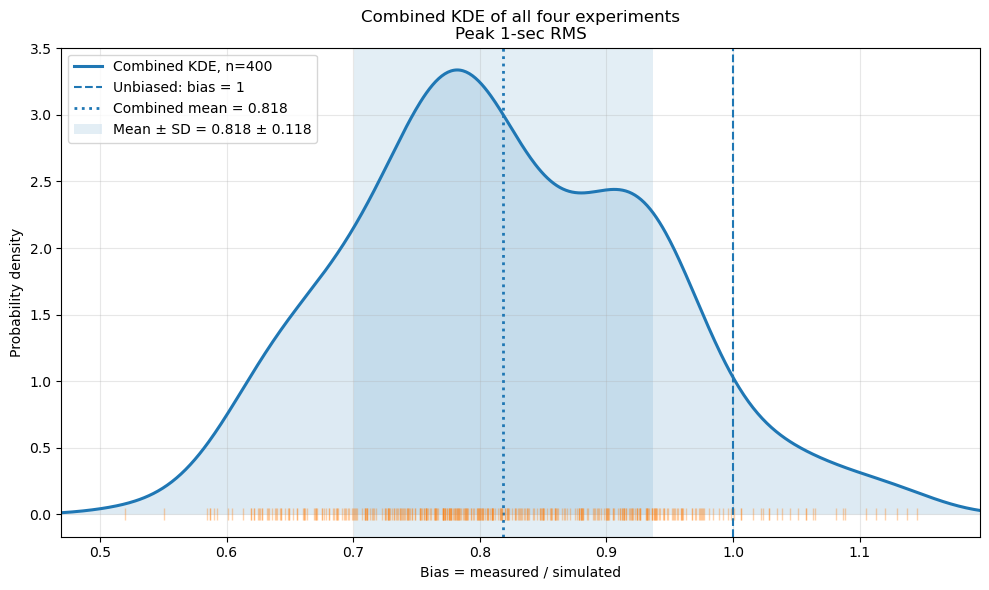

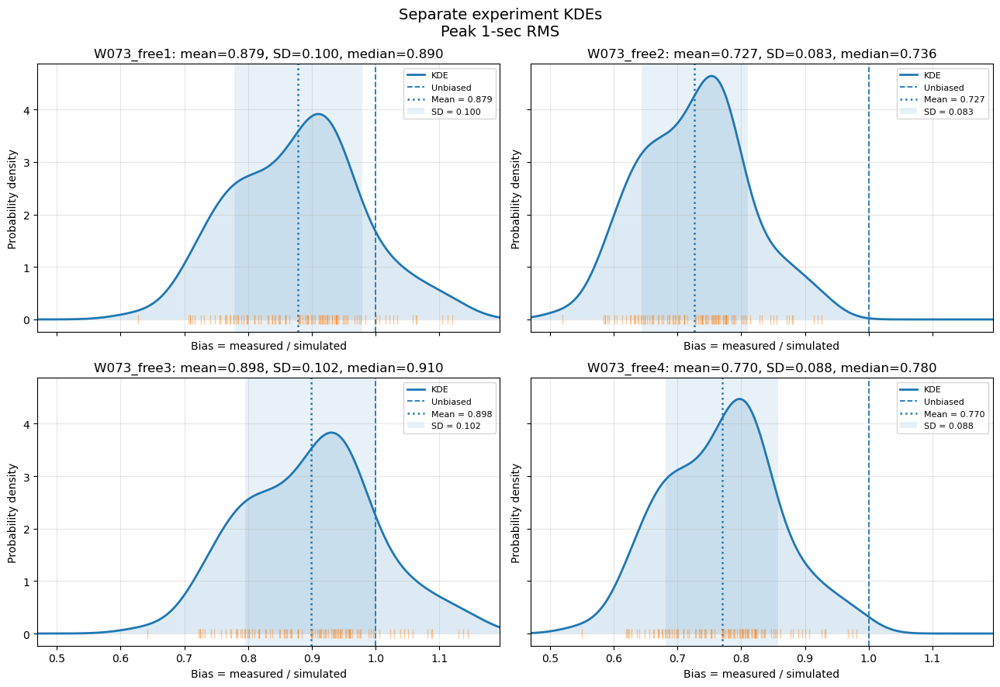


Peak absolute acceleration
Number of pooled bias values = 400
Combined mean bias           = 1.046279
Combined SD bias             = 0.129869
Combined median bias         = 1.044088
Combined P5-P95 bias         = [0.842737, 1.262915]


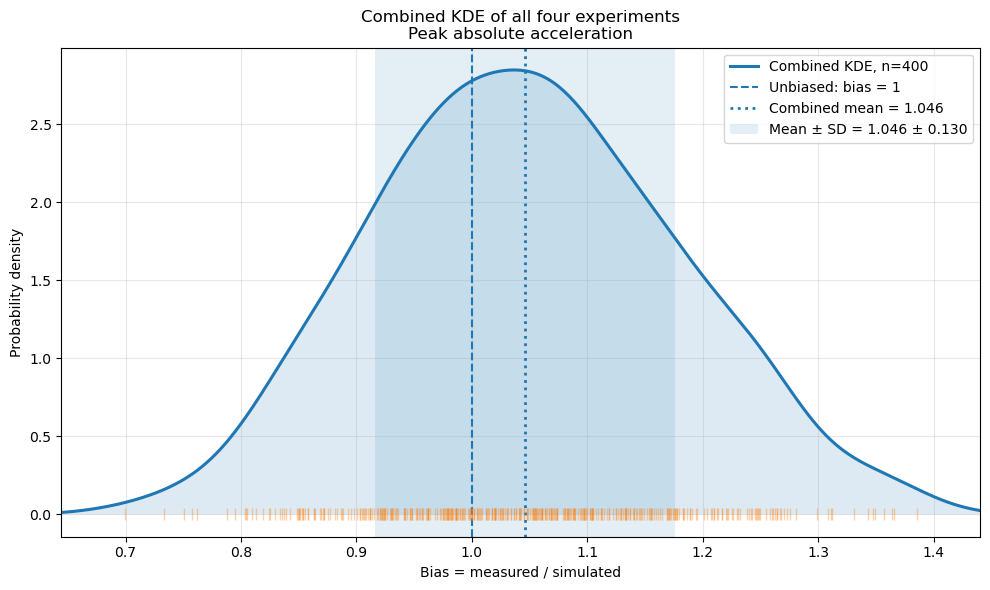

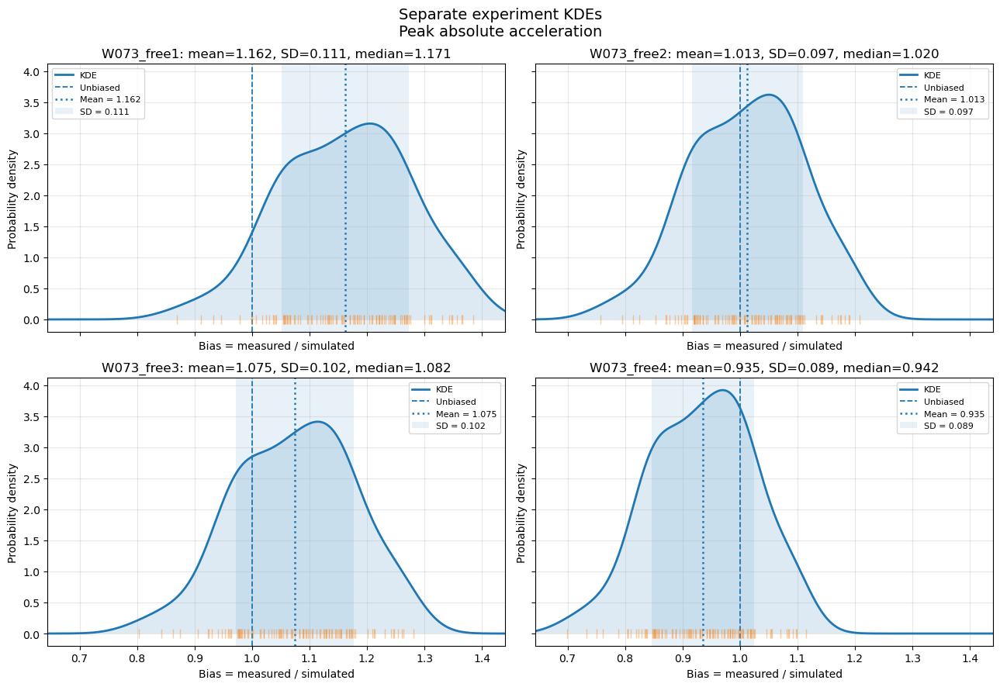


P95 absolute acceleration
Number of pooled bias values = 400
Combined mean bias           = 0.921921
Combined SD bias             = 0.063471
Combined median bias         = 0.919719
Combined P5-P95 bias         = [0.820277, 1.032796]


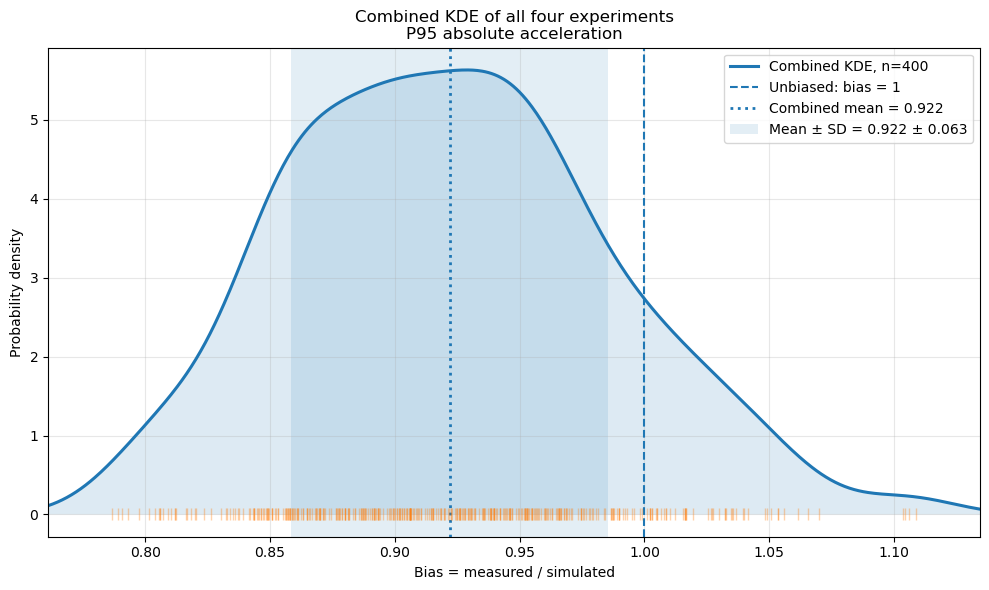

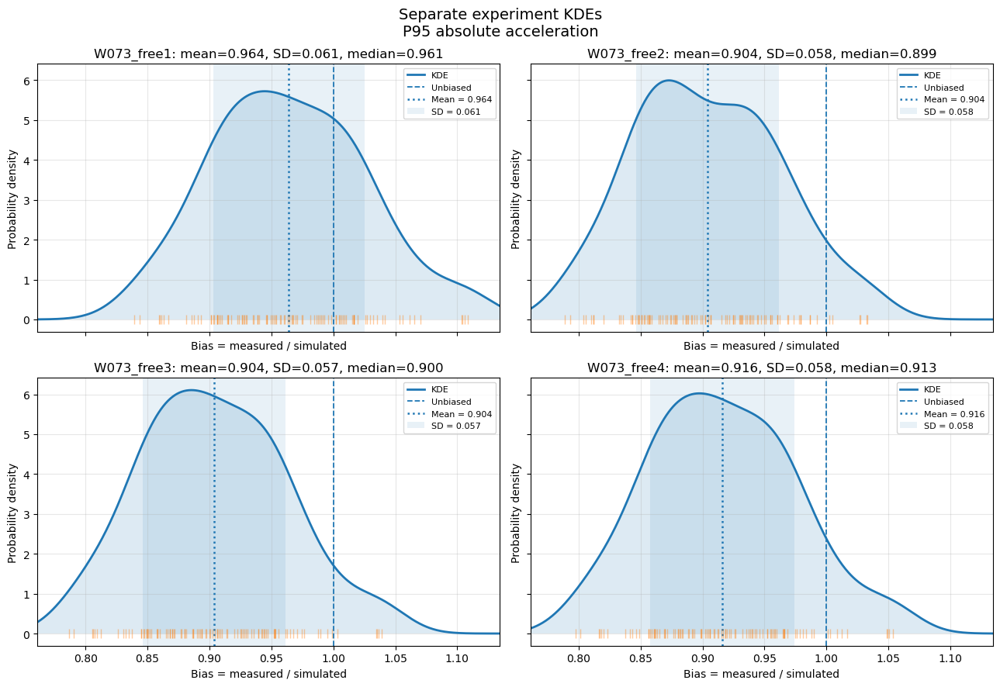


Combined KDE statistics for all four experiments
              Bias measure  Number of pooled bias values  Combined mean bias  Combined SD bias  Combined median bias  Combined P5 bias  Combined P95 bias
            Peak 1-sec RMS                           400            0.818496          0.118072              0.806262          0.632945           1.022124
Peak absolute acceleration                           400            1.046279          0.129869              1.044088          0.842737           1.262915
 P95 absolute acceleration                           400            0.921921          0.063471              0.919719          0.820277           1.032796

Saved: W073_combined_KDE_mean_SD_summary.csv


In [66]:
# ================================================================
# KDE OF THE THREE BIAS MEASURES
#
# For each response measure:
#   1. Pool bias values from all four experiments.
#   2. Fit ONE combined KDE to the pooled values.
#   3. Report the pooled mean and standard deviation.
#   4. Plot four separate experiment-specific KDEs.
# ================================================================

from scipy.stats import gaussian_kde


# ================================================================
# KDE SETTINGS
# ================================================================

KDE_NUMBER_OF_POINTS = 600

# Common choices:
#     "scott"
#     "silverman"
KDE_BANDWIDTH = "scott"

KDE_X_PADDING_FRACTION = 0.08

# ddof=1 gives the sample standard deviation.
# Use ddof=0 for the population standard deviation.
STANDARD_DEVIATION_DDOF = 1


# ================================================================
# BIAS MEASURES
# ================================================================

KDE_MEASURES = [
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "P95 absolute acceleration",
]


# ================================================================
# HELPER: CLEAN BIAS VALUES
# ================================================================

def clean_bias_values(values):

    values = np.asarray(
        values,
        dtype=float,
    ).ravel()

    values = values[
        np.isfinite(values)
    ]

    if len(values) < 2:

        raise ValueError(
            "At least two finite bias values are required "
            "to calculate a KDE."
        )

    return values


# ================================================================
# HELPER: CALCULATE KDE SAFELY
# ================================================================

def calculate_kde(
    bias_values,
    x_grid,
):

    bias_values = clean_bias_values(
        bias_values
    )

    # gaussian_kde cannot handle a distribution with exactly
    # zero variance. Add extremely small deterministic jitter
    # only in that exceptional case.
    if np.isclose(
        np.std(
            bias_values
        ),
        0.0,
    ):

        scale = max(
            abs(
                float(
                    np.mean(
                        bias_values
                    )
                )
            ),
            1.0,
        )

        jitter = np.linspace(
            -1.0e-6,
            1.0e-6,
            len(bias_values),
        ) * scale

        bias_values = (
            bias_values
            + jitter
        )

    kde = gaussian_kde(
        bias_values,
        bw_method=KDE_BANDWIDTH,
    )

    density = kde(
        x_grid
    )

    return density


# ================================================================
# HELPER: CREATE X-GRID
# ================================================================

def create_kde_grid(
    bias_values,
):

    bias_values = clean_bias_values(
        bias_values
    )

    minimum_bias = float(
        np.min(
            bias_values
        )
    )

    maximum_bias = float(
        np.max(
            bias_values
        )
    )

    bias_range = (
        maximum_bias
        - minimum_bias
    )

    if bias_range <= 0.0:

        bias_range = max(
            abs(
                minimum_bias
            ),
            1.0,
        )

    padding = (
        KDE_X_PADDING_FRACTION
        * bias_range
    )

    x_minimum = max(
        0.0,
        minimum_bias - padding,
    )

    x_maximum = (
        maximum_bias
        + padding
    )

    return np.linspace(
        x_minimum,
        x_maximum,
        KDE_NUMBER_OF_POINTS,
    )


# ================================================================
# KDE SUMMARY
# ================================================================

combined_kde_summary_rows = []


# ================================================================
# LOOP THROUGH THE THREE RESPONSE MEASURES
# ================================================================

for measure_name in KDE_MEASURES:

    # ------------------------------------------------------------
    # Pool all four bias distributions
    # ------------------------------------------------------------

    pooled_bias_arrays = []

    for test_number in test_settings:

        test_biases = clean_bias_values(
            bias_distributions[
                test_number
            ][
                measure_name
            ]
        )

        pooled_bias_arrays.append(
            test_biases
        )

    pooled_biases = np.concatenate(
        pooled_bias_arrays
    )

    # ------------------------------------------------------------
    # Final pooled statistics
    # ------------------------------------------------------------

    pooled_mean = float(
        np.mean(
            pooled_biases
        )
    )

    pooled_sd = float(
        np.std(
            pooled_biases,
            ddof=STANDARD_DEVIATION_DDOF,
        )
    )

    pooled_median = float(
        np.median(
            pooled_biases
        )
    )

    pooled_p5 = float(
        np.percentile(
            pooled_biases,
            5,
        )
    )

    pooled_p95 = float(
        np.percentile(
            pooled_biases,
            95,
        )
    )

    pooled_number = len(
        pooled_biases
    )

    combined_kde_summary_rows.append(
        {
            "Bias measure":
                measure_name,

            "Number of pooled bias values":
                pooled_number,

            "Combined mean bias":
                pooled_mean,

            "Combined SD bias":
                pooled_sd,

            "Combined median bias":
                pooled_median,

            "Combined P5 bias":
                pooled_p5,

            "Combined P95 bias":
                pooled_p95,
        }
    )

    print(
        f"\n{measure_name}"
    )

    print(
        "=" * 60
    )

    print(
        f"Number of pooled bias values = "
        f"{pooled_number}"
    )

    print(
        f"Combined mean bias           = "
        f"{pooled_mean:.6f}"
    )

    print(
        f"Combined SD bias             = "
        f"{pooled_sd:.6f}"
    )

    print(
        f"Combined median bias         = "
        f"{pooled_median:.6f}"
    )

    print(
        f"Combined P5-P95 bias         = "
        f"[{pooled_p5:.6f}, {pooled_p95:.6f}]"
    )

    # Use the pooled bias range for both the combined and
    # experiment-specific plots.
    x_grid = create_kde_grid(
        pooled_biases
    )

    pooled_density = calculate_kde(
        bias_values=pooled_biases,
        x_grid=x_grid,
    )

    # ============================================================
    # FIGURE 1: ONE COMBINED KDE FROM ALL FOUR TESTS
    # ============================================================

    plt.figure(
        figsize=(
            10,
            6,
        )
    )

    plt.plot(
        x_grid,
        pooled_density,
        linewidth=2.2,
        label=(
            f"Combined KDE, n={pooled_number}"
        ),
    )

    plt.fill_between(
        x_grid,
        0.0,
        pooled_density,
        alpha=0.15,
    )

    # Perfect agreement
    plt.axvline(
        1.0,
        linestyle="--",
        linewidth=1.5,
        label="Unbiased: bias = 1",
    )

    # Combined mean
    plt.axvline(
        pooled_mean,
        linestyle=":",
        linewidth=2.0,
        label=(
            f"Combined mean = {pooled_mean:.3f}"
        ),
    )

    # Mean ± one standard deviation
    plt.axvspan(
        max(
            0.0,
            pooled_mean - pooled_sd,
        ),
        pooled_mean + pooled_sd,
        alpha=0.12,
        label=(
            f"Mean ± SD = "
            f"{pooled_mean:.3f} ± {pooled_sd:.3f}"
        ),
    )

    # Rug marks for every pooled bias value
    plt.plot(
        pooled_biases,
        np.zeros_like(
            pooled_biases
        ),
        "|",
        markersize=8,
        alpha=0.35,
    )

    plt.xlabel(
        "Bias = measured / simulated"
    )

    plt.ylabel(
        "Probability density"
    )

    plt.title(
        f"Combined KDE of all four experiments\n"
        f"{measure_name}"
    )

    plt.xlim(
        x_grid[0],
        x_grid[-1],
    )

    plt.grid(
        True,
        alpha=0.3,
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


    # ============================================================
    # FIGURE 2: FOUR SEPARATE KDEs
    # ============================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            13,
            9,
        ),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(
        axes
    ).ravel()

    for plot_index, test_number in enumerate(
        test_settings
    ):

        ax = axes[
            plot_index
        ]

        test_biases = clean_bias_values(
            bias_distributions[
                test_number
            ][
                measure_name
            ]
        )

        test_density = calculate_kde(
            bias_values=test_biases,
            x_grid=x_grid,
        )

        test_mean = float(
            np.mean(
                test_biases
            )
        )

        test_sd = float(
            np.std(
                test_biases,
                ddof=STANDARD_DEVIATION_DDOF,
            )
        )

        test_median = float(
            np.median(
                test_biases
            )
        )

        ax.plot(
            x_grid,
            test_density,
            linewidth=2.0,
            label="KDE",
        )

        ax.fill_between(
            x_grid,
            0.0,
            test_density,
            alpha=0.15,
        )

        ax.axvline(
            1.0,
            linestyle="--",
            linewidth=1.3,
            label="Unbiased",
        )

        ax.axvline(
            test_mean,
            linestyle=":",
            linewidth=1.8,
            label=(
                f"Mean = {test_mean:.3f}"
            ),
        )

        ax.axvspan(
            max(
                0.0,
                test_mean - test_sd,
            ),
            test_mean + test_sd,
            alpha=0.10,
            label=(
                f"SD = {test_sd:.3f}"
            ),
        )

        ax.plot(
            test_biases,
            np.zeros_like(
                test_biases
            ),
            "|",
            markersize=8,
            alpha=0.40,
        )

        start_time, end_time = (
            test_settings[
                test_number
            ][
                "window"
            ]
        )

        ax.set_title(
            f"W073_free{test_number}: "
            
            f"mean={test_mean:.3f}, "
            f"SD={test_sd:.3f}, "
            f"median={test_median:.3f}"
        )

        ax.set_xlabel(
            "Bias = measured / simulated"
        )

        ax.set_ylabel(
            "Probability density"
        )

        ax.set_xlim(
            x_grid[0],
            x_grid[-1],
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            fontsize=8,
        )

    fig.suptitle(
        f"Separate experiment KDEs\n{measure_name}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# FINAL COMBINED MEAN AND SD TABLE
# ================================================================

combined_kde_summary_df = pd.DataFrame(
    combined_kde_summary_rows
)

print(
    "\nCombined KDE statistics for all four experiments"
)

print(
    "================================================"
)

print(
    combined_kde_summary_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# ================================================================
# SAVE COMBINED KDE SUMMARY
# ================================================================

combined_kde_summary_df.to_csv(
    "W073_combined_KDE_mean_SD_summary.csv",
    index=False,
)

print(
    "\nSaved: W073_combined_KDE_mean_SD_summary.csv"
)


W073_free1
Window                              = 100-600 s
Global MC correction factor         = 1.046
Measured peak absolute              = 0.315467 m/s²
Mean corrected-MC peak absolute     = 0.286575 m/s²
Measured peak 1-sec RMS             = 0.133648 m/s²
Mean corrected-MC peak 1-sec RMS    = 0.161170 m/s²
Measured P95 absolute               = 0.127299 m/s²


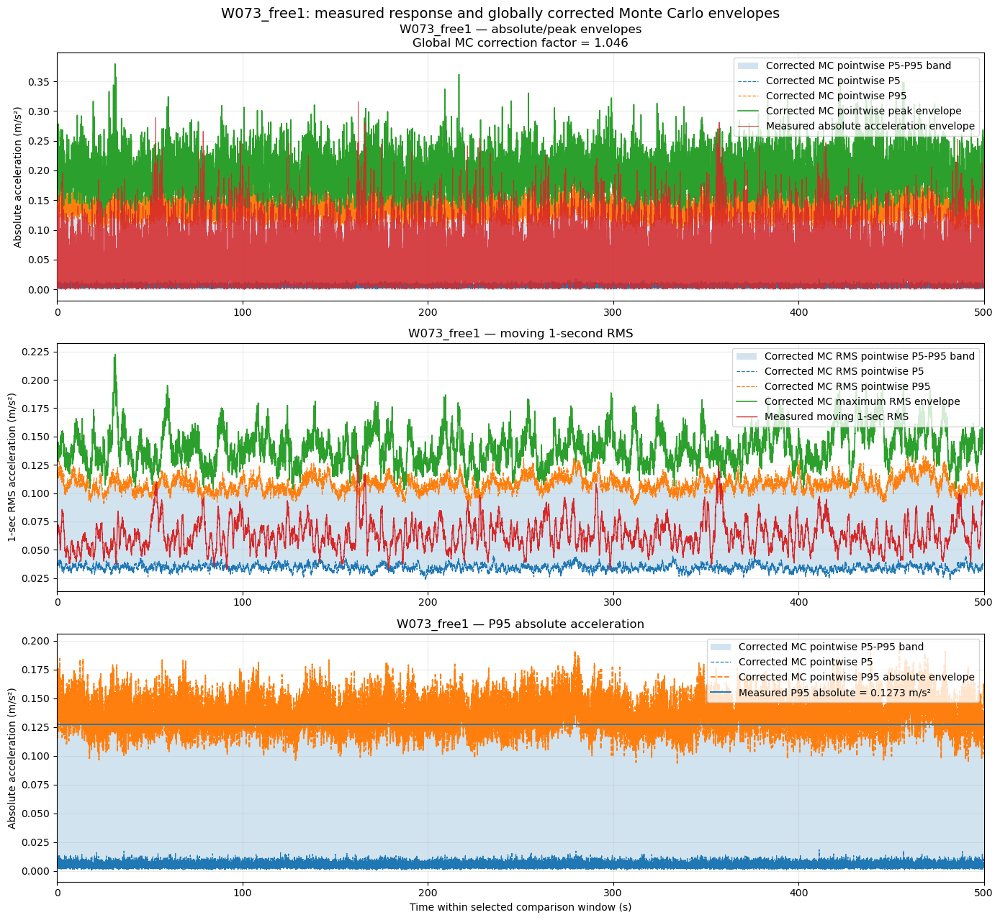


W073_free2
Window                              = 110-610 s
Global MC correction factor         = 1.046
Measured peak absolute              = 0.274956 m/s²
Mean corrected-MC peak absolute     = 0.286575 m/s²
Measured peak 1-sec RMS             = 0.110566 m/s²
Mean corrected-MC peak 1-sec RMS    = 0.161225 m/s²
Measured P95 absolute               = 0.119176 m/s²


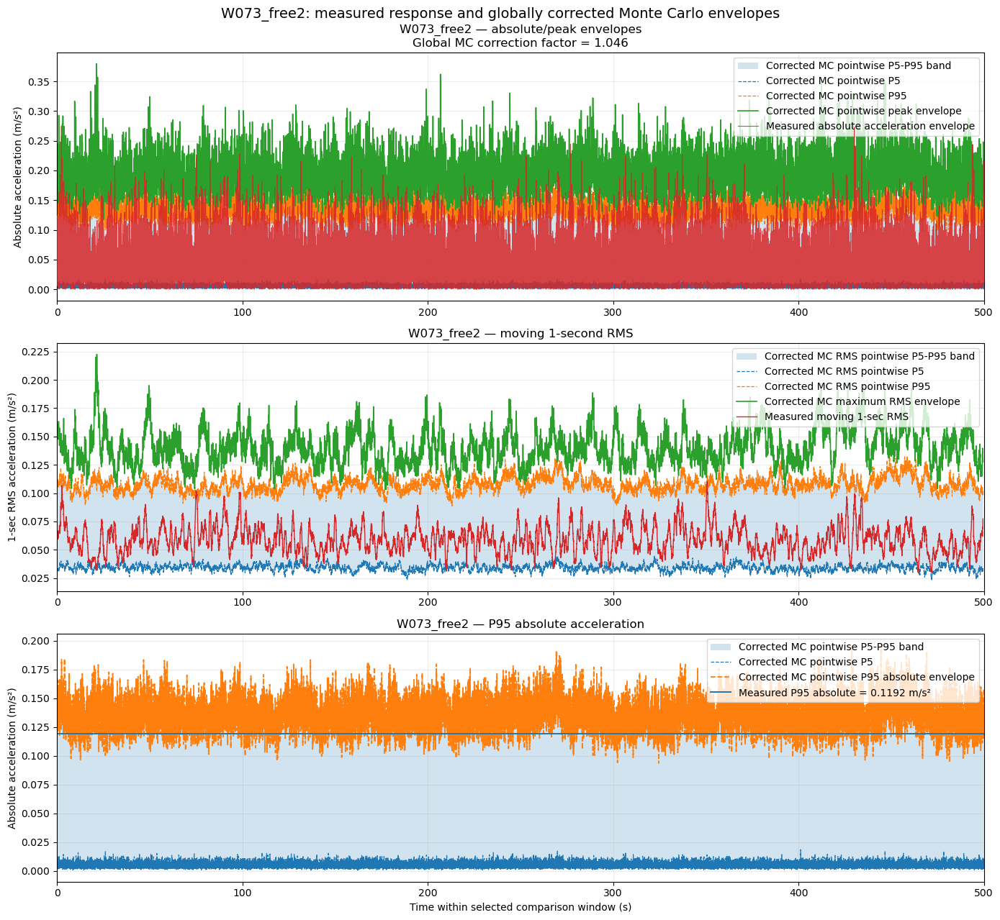


W073_free3
Window                              = 100-600 s
Global MC correction factor         = 1.046
Measured peak absolute              = 0.291699 m/s²
Mean corrected-MC peak absolute     = 0.286575 m/s²
Measured peak 1-sec RMS             = 0.136640 m/s²
Mean corrected-MC peak 1-sec RMS    = 0.161170 m/s²
Measured P95 absolute               = 0.119336 m/s²


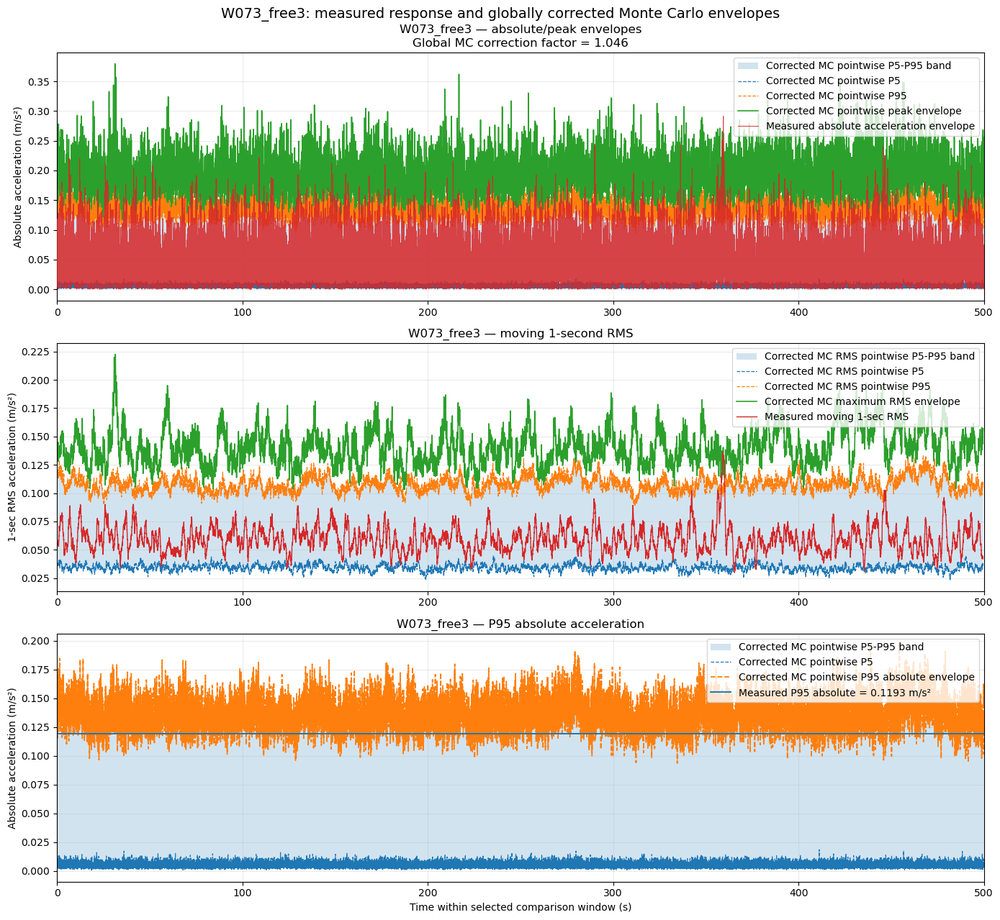


W073_free4
Window                              = 100-600 s
Global MC correction factor         = 1.046
Measured peak absolute              = 0.253848 m/s²
Mean corrected-MC peak absolute     = 0.286575 m/s²
Measured peak 1-sec RMS             = 0.117081 m/s²
Mean corrected-MC peak 1-sec RMS    = 0.161170 m/s²
Measured P95 absolute               = 0.120953 m/s²


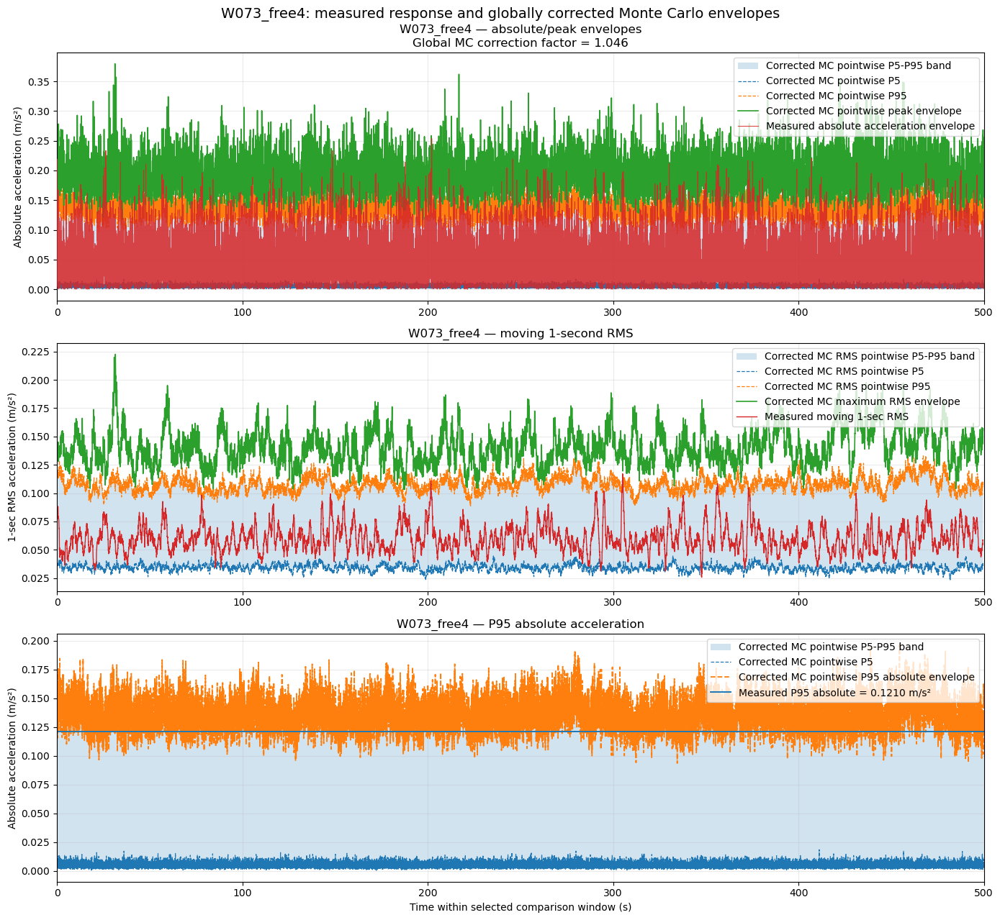

In [48]:
# ================================================================
# FOUR EXPERIMENTS × THREE RESPONSE DIAGRAMS
#
# Run this AFTER the previous three-measure bias code.
#
# A single correction factor is applied to every Monte Carlo
# acceleration history:
#
#     corrected MC = original processed MC × 1.046
#
# The processed measured signal is NOT multiplied by the correction
# factor.
#
# For each experiment, one figure with three panels is produced:
#
#   Panel 1 — Absolute/peak envelope
#       measured |a(t)|
#       pointwise maximum corrected-MC |a_i(t)|
#       pointwise corrected-MC P5–P95 band
#
#   Panel 2 — Moving 1-second RMS
#       measured RMS(t)
#       pointwise maximum corrected-MC RMS_i(t)
#       pointwise corrected-MC P5–P95 band
#
#   Panel 3 — P95 absolute acceleration
#       measured P95(|a|), shown as a horizontal line
#       pointwise corrected-MC P95(|a_i(t)|) envelope
#       pointwise corrected-MC P5–P95 band
#
# Four experiments × three panels = 12 diagrams.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# SETTINGS
# ================================================================

GLOBAL_CORRECTION_FACTOR = 1.046

LOWER_MC_PERCENTILE = 5.0
UPPER_MC_PERCENTILE = 95.0

SAVE_FIGURES = False
FIGURE_DPI = 300


# ================================================================
# CHECK THAT THE PREVIOUS CODE HAS BEEN RUN
# ================================================================

required_names = [
    "test_settings",
    "data_folder",
    "target_sensor",
    "number_of_simulations",
    "mc_time",
    "mc_hht",
    "processed_mc_accelerations",
    "load_measured_sensor",
    "preprocess_measured_signal",
    "select_window",
    "calculate_moving_rms",
    "RMS_WINDOW_SECONDS",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:

    raise NameError(
        "Run the previous three-measure bias code first.\n"
        "The following objects are missing:\n"
        + "\n".join(
            f"  {name}"
            for name in missing_names
        )
    )


# ================================================================
# STORAGE
# ================================================================

twelve_diagram_results = {}


# ================================================================
# LOOP THROUGH THE FOUR EXPERIMENTS
# ================================================================

for test_number, settings in test_settings.items():

    measured_duration = float(
        settings[
            "duration"
        ]
    )

    start_time, end_time = (
        settings[
            "window"
        ]
    )

    selected_duration = (
        end_time
        - start_time
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )


    # ============================================================
    # LOAD AND PREPROCESS MEASURED SIGNAL
    # ============================================================

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    measured_time_full = (
        measured_processed[
            "time"
        ]
    )

    measured_acceleration_full = (
        measured_processed[
            "acceleration"
        ]
    )

    measured_dt = float(
        measured_processed[
            "dt"
        ]
    )

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_time_full,
        acceleration=measured_acceleration_full,
        start_time=start_time,
        end_time=end_time,
    )


    # ============================================================
    # EXTRACT THE SAME WINDOW FROM EVERY PROCESSED MC HISTORY
    # ============================================================

    original_mc_windows = []

    simulated_time_window = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_simulated_time_window,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        if simulated_time_window is None:

            simulated_time_window = (
                current_simulated_time_window
            )

        elif len(
            current_simulated_time_window
        ) != len(
            simulated_time_window
        ):

            raise ValueError(
                f"W073_free{test_number}: Monte Carlo windows "
                "do not all have the same number of samples."
            )

        original_mc_windows.append(
            simulated_acceleration_window
        )

    original_mc_windows = np.asarray(
        original_mc_windows,
        dtype=float,
    )


    # ============================================================
    # APPLY ONE GLOBAL CORRECTION FACTOR TO ALL MC HISTORIES
    # ============================================================

    corrected_mc_windows = (
        original_mc_windows
        * GLOBAL_CORRECTION_FACTOR
    )


    # ============================================================
    # PANEL 1 QUANTITIES:
    # ABSOLUTE/PEAK ENVELOPES
    # ============================================================

    measured_absolute_envelope = np.abs(
        measured_acceleration_window
    )

    corrected_mc_absolute = np.abs(
        corrected_mc_windows
    )

    # Pointwise MC P5 and P95.
    mc_absolute_p5 = np.percentile(
        corrected_mc_absolute,
        LOWER_MC_PERCENTILE,
        axis=0,
    )

    mc_absolute_p95 = np.percentile(
        corrected_mc_absolute,
        UPPER_MC_PERCENTILE,
        axis=0,
    )

    # Pointwise peak envelope:
    # maximum across all MC realizations at each time step.
    mc_absolute_maximum_envelope = np.max(
        corrected_mc_absolute,
        axis=0,
    )


    # ============================================================
    # PANEL 2 QUANTITIES:
    # MOVING 1-SECOND RMS
    # ============================================================

    (
        measured_rms_time,
        measured_rms_history,
    ) = calculate_moving_rms(
        acceleration=measured_acceleration_window,
        dt=measured_dt,
        window_seconds=RMS_WINDOW_SECONDS,
    )

    corrected_mc_rms_histories = []

    simulated_rms_time = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_rms_time,
            current_rms_history,
        ) = calculate_moving_rms(
            acceleration=corrected_mc_windows[
                simulation_index
            ],
            dt=mc_hht,
            window_seconds=RMS_WINDOW_SECONDS,
        )

        if simulated_rms_time is None:

            simulated_rms_time = (
                current_rms_time
            )

        elif len(
            current_rms_time
        ) != len(
            simulated_rms_time
        ):

            raise ValueError(
                f"W073_free{test_number}: Monte Carlo RMS histories "
                "do not all have the same length."
            )

        corrected_mc_rms_histories.append(
            current_rms_history
        )

    corrected_mc_rms_histories = np.asarray(
        corrected_mc_rms_histories,
        dtype=float,
    )

    mc_rms_p5 = np.percentile(
        corrected_mc_rms_histories,
        LOWER_MC_PERCENTILE,
        axis=0,
    )

    mc_rms_p95 = np.percentile(
        corrected_mc_rms_histories,
        UPPER_MC_PERCENTILE,
        axis=0,
    )

    mc_rms_maximum_envelope = np.max(
        corrected_mc_rms_histories,
        axis=0,
    )


    # ============================================================
    # PANEL 3 QUANTITIES:
    # P95 ABSOLUTE ACCELERATION
    # ============================================================

    # One measured P95 absolute value for the selected experiment.
    measured_p95_absolute = float(
        np.percentile(
            np.abs(
                measured_acceleration_window
            ),
            95,
        )
    )

    # Pointwise MC P95 envelope:
    # at every time step, take the 95th percentile across all
    # corrected MC absolute accelerations.
    mc_pointwise_p95_absolute_envelope = (
        mc_absolute_p95
    )


    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    measured_peak_absolute = float(
        np.max(
            measured_absolute_envelope
        )
    )

    mc_mean_peak_absolute = float(
        np.mean(
            np.max(
                corrected_mc_absolute,
                axis=1,
            )
        )
    )

    measured_peak_rms = float(
        np.max(
            measured_rms_history
        )
    )

    mc_mean_peak_rms = float(
        np.mean(
            np.max(
                corrected_mc_rms_histories,
                axis=1,
            )
        )
    )

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 60
    )

    print(
        f"Window                              = "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    print(
        f"Global MC correction factor         = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    print(
        f"Measured peak absolute              = "
        f"{measured_peak_absolute:.6f} m/s²"
    )

    print(
        f"Mean corrected-MC peak absolute     = "
        f"{mc_mean_peak_absolute:.6f} m/s²"
    )

    print(
        f"Measured peak 1-sec RMS             = "
        f"{measured_peak_rms:.6f} m/s²"
    )

    print(
        f"Mean corrected-MC peak 1-sec RMS    = "
        f"{mc_mean_peak_rms:.6f} m/s²"
    )

    print(
        f"Measured P95 absolute               = "
        f"{measured_p95_absolute:.6f} m/s²"
    )


    # ============================================================
    # STORE RESULTS
    # ============================================================

    twelve_diagram_results[
        test_number
    ] = {
        "correction_factor":
            GLOBAL_CORRECTION_FACTOR,

        "measured_time":
            measured_time_window,

        "measured_acceleration":
            measured_acceleration_window,

        "measured_absolute_envelope":
            measured_absolute_envelope,

        "simulated_time":
            simulated_time_window,

        "corrected_mc_windows":
            corrected_mc_windows,

        "mc_absolute_p5":
            mc_absolute_p5,

        "mc_absolute_p95":
            mc_absolute_p95,

        "mc_absolute_maximum_envelope":
            mc_absolute_maximum_envelope,

        "measured_rms_time":
            measured_rms_time,

        "measured_rms_history":
            measured_rms_history,

        "simulated_rms_time":
            simulated_rms_time,

        "corrected_mc_rms_histories":
            corrected_mc_rms_histories,

        "mc_rms_p5":
            mc_rms_p5,

        "mc_rms_p95":
            mc_rms_p95,

        "mc_rms_maximum_envelope":
            mc_rms_maximum_envelope,

        "measured_p95_absolute":
            measured_p95_absolute,

        "mc_pointwise_p95_absolute_envelope":
            mc_pointwise_p95_absolute_envelope,
    }


    # ============================================================
    # CREATE THREE DIAGRAMS FOR THIS EXPERIMENT
    # ============================================================

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(
            14,
            13,
        ),
        sharex=False,
    )


    # ------------------------------------------------------------
    # DIAGRAM 1:
    # MEASURED ABSOLUTE ENVELOPE AND MC PEAK ENVELOPE
    # ------------------------------------------------------------

    axes[0].fill_between(
        simulated_time_window,
        mc_absolute_p5,
        mc_absolute_p95,
        alpha=0.20,
        label="Corrected MC pointwise P5-P95 band",
    )

    axes[0].plot(
        simulated_time_window,
        mc_absolute_p5,
        linestyle="--",
        linewidth=0.9,
        label="Corrected MC pointwise P5",
    )

    axes[0].plot(
        simulated_time_window,
        mc_absolute_p95,
        linestyle="--",
        linewidth=0.9,
        label="Corrected MC pointwise P95",
    )

    axes[0].plot(
        simulated_time_window,
        mc_absolute_maximum_envelope,
        linewidth=1.2,
        label="Corrected MC pointwise peak envelope",
    )

    axes[0].plot(
        measured_time_window,
        measured_absolute_envelope,
        linewidth=0.8,
        alpha=0.85,
        zorder=10,
        label="Measured absolute acceleration envelope",
    )

    axes[0].set_xlim(
        0.0,
        selected_duration,
    )

    axes[0].set_ylabel(
        "Absolute acceleration (m/s²)"
    )

    axes[0].set_title(
        f"W073_free{test_number} — absolute/peak envelopes\n"
        f"Global MC correction factor = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    axes[0].grid(
        True,
        alpha=0.25,
    )

    axes[0].legend(
        loc="upper right",
    )


    # ------------------------------------------------------------
    # DIAGRAM 2:
    # MEASURED 1-SECOND RMS AND MAXIMUM MC RMS ENVELOPE
    # ------------------------------------------------------------

    axes[1].fill_between(
        simulated_rms_time,
        mc_rms_p5,
        mc_rms_p95,
        alpha=0.20,
        label="Corrected MC RMS pointwise P5-P95 band",
    )

    axes[1].plot(
        simulated_rms_time,
        mc_rms_p5,
        linestyle="--",
        linewidth=0.9,
        label="Corrected MC RMS pointwise P5",
    )

    axes[1].plot(
        simulated_rms_time,
        mc_rms_p95,
        linestyle="--",
        linewidth=0.9,
        label="Corrected MC RMS pointwise P95",
    )

    axes[1].plot(
        simulated_rms_time,
        mc_rms_maximum_envelope,
        linewidth=1.2,
        label="Corrected MC maximum RMS envelope",
    )

    axes[1].plot(
        measured_rms_time,
        measured_rms_history,
        linewidth=1.0,
        zorder=10,
        label="Measured moving 1-sec RMS",
    )

    axes[1].set_xlim(
        0.0,
        selected_duration,
    )

    axes[1].set_ylabel(
        "1-sec RMS acceleration (m/s²)"
    )

    axes[1].set_title(
        f"W073_free{test_number} — moving 1-second RMS"
    )

    axes[1].grid(
        True,
        alpha=0.25,
    )

    axes[1].legend(
        loc="upper right",
    )


    # ------------------------------------------------------------
    # DIAGRAM 3:
    # MEASURED P95 ABSOLUTE AND POINTWISE MC P95 ENVELOPE
    # ------------------------------------------------------------

    axes[2].fill_between(
        simulated_time_window,
        mc_absolute_p5,
        mc_absolute_p95,
        alpha=0.20,
        label="Corrected MC pointwise P5-P95 band",
    )

    axes[2].plot(
        simulated_time_window,
        mc_absolute_p5,
        linestyle="--",
        linewidth=0.9,
        label="Corrected MC pointwise P5",
    )

    axes[2].plot(
        simulated_time_window,
        mc_pointwise_p95_absolute_envelope,
        linestyle="--",
        linewidth=1.3,
        label="Corrected MC pointwise P95 absolute envelope",
    )

    axes[2].axhline(
        measured_p95_absolute,
        linewidth=1.4,
        label=(
            f"Measured P95 absolute = "
            f"{measured_p95_absolute:.4f} m/s²"
        ),
    )

    axes[2].set_xlim(
        0.0,
        selected_duration,
    )

    axes[2].set_xlabel(
        "Time within selected comparison window (s)"
    )

    axes[2].set_ylabel(
        "Absolute acceleration (m/s²)"
    )

    axes[2].set_title(
        f"W073_free{test_number} — P95 absolute acceleration"
    )

    axes[2].grid(
        True,
        alpha=0.25,
    )

    axes[2].legend(
        loc="upper right",
    )


    fig.suptitle(
        f"W073_free{test_number}: measured response and "
        "globally corrected Monte Carlo envelopes",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()


    # ============================================================
    # OPTIONAL SAVE
    # ============================================================

    if SAVE_FIGURES:

        output_name = (
            f"W073_free{test_number}_"
            f"three_corrected_MC_envelope_diagrams.png"
        )

        fig.savefig(
            output_name,
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

        print(
            f"Saved: {output_name}"
        )


W073_free1
Window                         = 100-600 s
Correction factor              = 1.046
Measured samples               = 27873
MC samples per realization     = 50000
Number of MC realizations      = 100
Measured peak absolute         = 0.315467 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


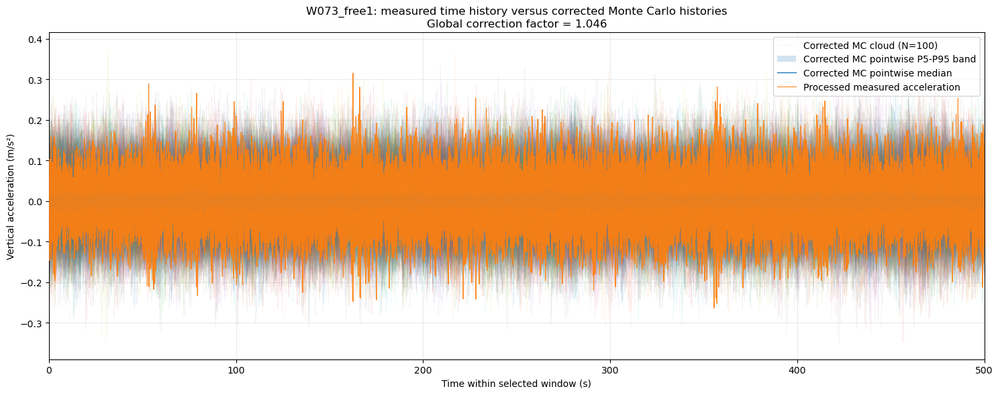


W073_free2
Window                         = 110-610 s
Correction factor              = 1.046
Measured samples               = 31543
MC samples per realization     = 50000
Number of MC realizations      = 100
Measured peak absolute         = 0.274956 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


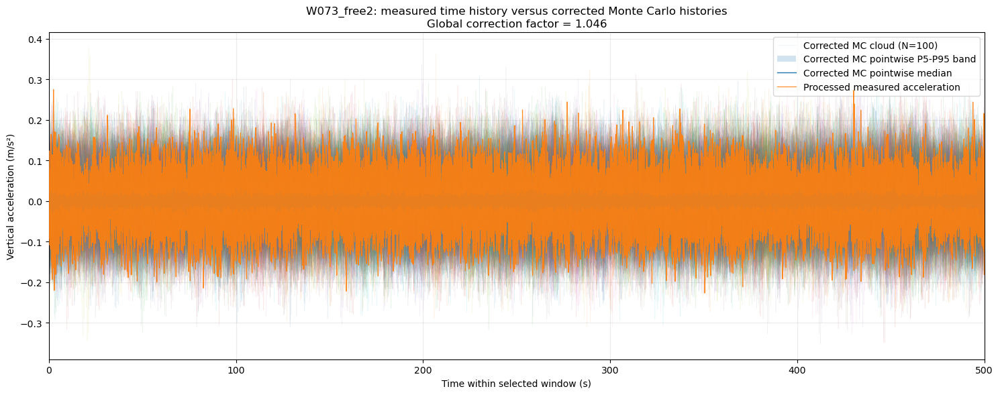


W073_free3
Window                         = 100-600 s
Correction factor              = 1.046
Measured samples               = 28888
MC samples per realization     = 50000
Number of MC realizations      = 100
Measured peak absolute         = 0.291699 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


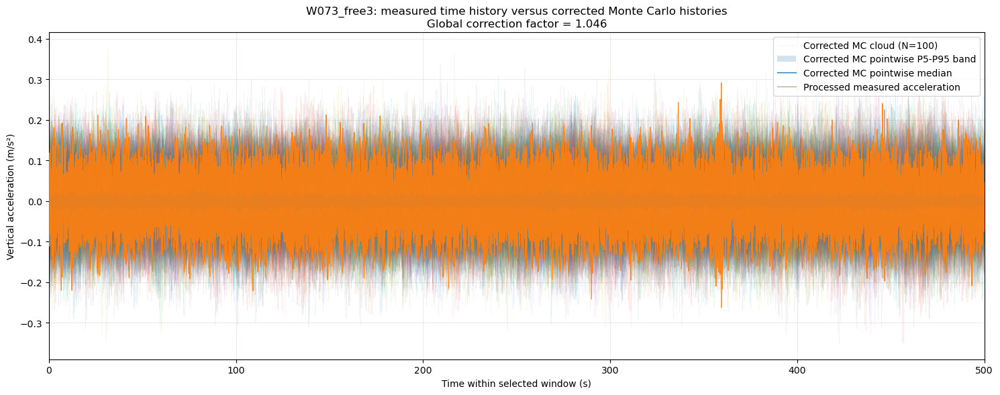


W073_free4
Window                         = 100-600 s
Correction factor              = 1.046
Measured samples               = 25805
MC samples per realization     = 50000
Number of MC realizations      = 100
Measured peak absolute         = 0.253848 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


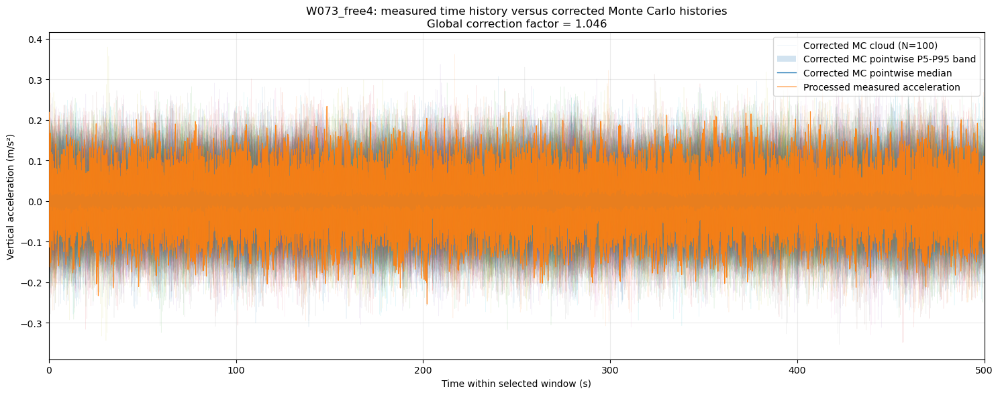

In [49]:
# ================================================================
# MEASURED TIME HISTORY VS CORRECTED MONTE CARLO TIME HISTORIES
#
# Run this AFTER the previous three-measure bias code.
#
# The measured signal remains unchanged.
# Every processed Monte Carlo acceleration history is multiplied by:
#
#     GLOBAL_CORRECTION_FACTOR = 1.046
#
# One figure is produced for each of the four experiments.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# SETTINGS
# ================================================================

GLOBAL_CORRECTION_FACTOR = 1.046

# Show every corrected MC realization as a light line.
PLOT_MC_CLOUD = True

# Also show the pointwise MC P5-P95 band and median.
PLOT_PERCENTILE_BAND = True

LOWER_MC_PERCENTILE = 5.0
UPPER_MC_PERCENTILE = 95.0

SAVE_FIGURES = False
FIGURE_DPI = 300


# ================================================================
# CHECK REQUIRED OBJECTS
# ================================================================

required_names = [
    "test_settings",
    "data_folder",
    "target_sensor",
    "number_of_simulations",
    "mc_time",
    "processed_mc_accelerations",
    "load_measured_sensor",
    "preprocess_measured_signal",
    "select_window",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:

    raise NameError(
        "Run the previous three-measure bias code first.\n"
        "Missing objects:\n"
        + "\n".join(
            f"  {name}"
            for name in missing_names
        )
    )


# ================================================================
# STORAGE
# ================================================================

measured_vs_corrected_mc_results = {}


# ================================================================
# LOOP THROUGH THE FOUR EXPERIMENTS
# ================================================================

for test_number, settings in test_settings.items():

    measured_duration = float(
        settings["duration"]
    )

    start_time, end_time = (
        settings["window"]
    )

    selected_duration = (
        end_time - start_time
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )


    # ============================================================
    # LOAD AND PREPROCESS THE MEASURED SIGNAL
    # ============================================================

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_processed["time"],
        acceleration=measured_processed["acceleration"],
        start_time=start_time,
        end_time=end_time,
    )


    # ============================================================
    # EXTRACT AND CORRECT THE SAME WINDOW FROM EVERY MC RUN
    # ============================================================

    corrected_mc_windows = []
    simulated_time_window = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_simulated_time,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        if simulated_time_window is None:

            simulated_time_window = (
                current_simulated_time
            )

        elif len(
            current_simulated_time
        ) != len(
            simulated_time_window
        ):

            raise ValueError(
                f"W073_free{test_number}: the MC windows "
                "do not all have the same length."
            )

        corrected_mc_windows.append(
            simulated_acceleration_window
            * GLOBAL_CORRECTION_FACTOR
        )

    corrected_mc_windows = np.asarray(
        corrected_mc_windows,
        dtype=float,
    )


    # ============================================================
    # POINTWISE MC STATISTICS
    # ============================================================

    corrected_mc_median = np.percentile(
        corrected_mc_windows,
        50,
        axis=0,
    )

    corrected_mc_p5 = np.percentile(
        corrected_mc_windows,
        LOWER_MC_PERCENTILE,
        axis=0,
    )

    corrected_mc_p95 = np.percentile(
        corrected_mc_windows,
        UPPER_MC_PERCENTILE,
        axis=0,
    )


    # ============================================================
    # STORE
    # ============================================================

    measured_vs_corrected_mc_results[
        test_number
    ] = {
        "correction_factor":
            GLOBAL_CORRECTION_FACTOR,

        "measured_time":
            measured_time_window,

        "measured_acceleration":
            measured_acceleration_window,

        "simulated_time":
            simulated_time_window,

        "corrected_mc_windows":
            corrected_mc_windows,

        "corrected_mc_median":
            corrected_mc_median,

        "corrected_mc_p5":
            corrected_mc_p5,

        "corrected_mc_p95":
            corrected_mc_p95,
    }


    # ============================================================
    # PRINT CHECKS
    # ============================================================

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 50
    )

    print(
        f"Window                         = "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    print(
        f"Correction factor              = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    print(
        f"Measured samples               = "
        f"{len(measured_acceleration_window)}"
    )

    print(
        f"MC samples per realization     = "
        f"{corrected_mc_windows.shape[1]}"
    )

    print(
        f"Number of MC realizations      = "
        f"{corrected_mc_windows.shape[0]}"
    )

    print(
        f"Measured peak absolute         = "
        f"{np.max(np.abs(measured_acceleration_window)):.6f} m/s²"
    )

    print(
        f"Mean corrected-MC peak absolute = "
        f"{np.mean(np.max(np.abs(corrected_mc_windows), axis=1)):.6f} m/s²"
    )


    # ============================================================
    # PLOT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(
            15,
            6,
        )
    )

    # ------------------------------------------------------------
    # Corrected MC cloud
    # ------------------------------------------------------------

    if PLOT_MC_CLOUD:

        for simulation_index in range(
            number_of_simulations
        ):

            ax.plot(
                simulated_time_window,
                corrected_mc_windows[
                    simulation_index
                ],
                linewidth=0.45,
                alpha=0.10,
                rasterized=True,
                label=(
                    f"Corrected MC cloud "
                    f"(N={number_of_simulations})"
                    if simulation_index == 0
                    else None
                ),
            )


    # ------------------------------------------------------------
    # Pointwise percentile band and median
    # ------------------------------------------------------------

    if PLOT_PERCENTILE_BAND:

        ax.fill_between(
            simulated_time_window,
            corrected_mc_p5,
            corrected_mc_p95,
            alpha=0.20,
            label=(
                f"Corrected MC pointwise "
                f"P{LOWER_MC_PERCENTILE:.0f}-"
                f"P{UPPER_MC_PERCENTILE:.0f} band"
            ),
        )

        ax.plot(
            simulated_time_window,
            corrected_mc_median,
            linewidth=1.0,
            label="Corrected MC pointwise median",
        )


    # ------------------------------------------------------------
    # Measured time history
    # ------------------------------------------------------------

    ax.plot(
        measured_time_window,
        measured_acceleration_window,
        linewidth=0.85,
        alpha=0.90,
        zorder=10,
        label="Processed measured acceleration",
    )

    ax.axhline(
        0.0,
        linestyle=":",
        linewidth=1.0,
    )

    ax.set_xlim(
        0.0,
        selected_duration,
    )

    ax.set_xlabel(
        "Time within selected window (s)"
    )

    ax.set_ylabel(
        "Vertical acceleration (m/s²)"
    )

    ax.set_title(
        f"W073_free{test_number}: measured time history versus "
        f"corrected Monte Carlo histories\n"
        f"Global correction factor = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend(
        loc="upper right",
    )

    plt.tight_layout()


    # ============================================================
    # OPTIONAL SAVE
    # ============================================================

    if SAVE_FIGURES:

        output_name = (
            f"W073_free{test_number}_"
            f"measured_vs_corrected_MC_time_histories.png"
        )

        fig.savefig(
            output_name,
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

        print(
            f"Saved: {output_name}"
        )

    plt.show()


W073_free2
Window                     = 110-610 s
Correction factor          = 1.046
Measured peak absolute     = 0.274956 m/s²
Measured peak 1-sec RMS    = 0.110566 m/s²
Mean MC peak 1-sec RMS     = 0.161225 m/s²


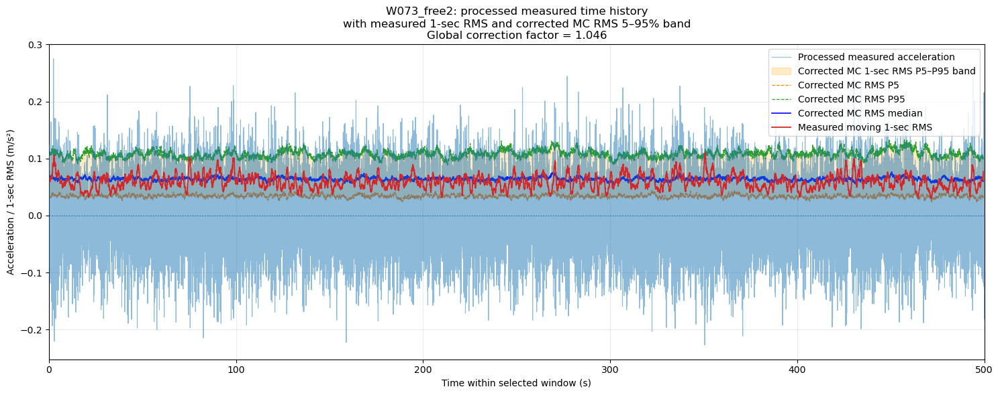

In [53]:
# ================================================================
# ONE EXPERIMENT:
# PROCESSED MEASURED TIME HISTORY
# + MEASURED 1-SEC RMS
# + CORRECTED MC 1-SEC RMS 5-95% BAND
#
# Run this AFTER the previous preprocessing / bias code.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# SETTINGS
# ================================================================

SELECTED_TEST = 2            # choose 1, 2, 3, or 4
GLOBAL_CORRECTION_FACTOR = 1.046

LOWER_PERCENTILE = 5.0
UPPER_PERCENTILE = 95.0

PLOT_MC_RMS_MEDIAN = True    # optional median RMS line
SAVE_FIGURE = False
FIGURE_DPI = 300


# ================================================================
# CHECK REQUIRED OBJECTS
# ================================================================

required_names = [
    "test_settings",
    "data_folder",
    "target_sensor",
    "mc_time",
    "mc_hht",
    "processed_mc_accelerations",
    "number_of_simulations",
    "load_measured_sensor",
    "preprocess_measured_signal",
    "select_window",
    "calculate_moving_rms",
    "RMS_WINDOW_SECONDS",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise NameError(
        "Run the previous preprocessing / bias code first.\n"
        "Missing objects:\n" + "\n".join(missing_names)
    )


# ================================================================
# SETTINGS FOR SELECTED TEST
# ================================================================

if SELECTED_TEST not in test_settings:
    raise ValueError(
        f"SELECTED_TEST must be one of {list(test_settings.keys())}"
    )

settings = test_settings[SELECTED_TEST]

measured_duration = float(settings["duration"])
start_time, end_time = settings["window"]
selected_duration = end_time - start_time

mat_file = data_folder / f"W073_free{SELECTED_TEST}.mat"


# ================================================================
# LOAD AND PREPROCESS MEASURED SIGNAL
# ================================================================

measured_acceleration_raw = load_measured_sensor(
    mat_file=mat_file,
    sensor_number=target_sensor,
)

measured_processed = preprocess_measured_signal(
    acceleration=measured_acceleration_raw,
    duration=measured_duration,
)

measured_time_full = measured_processed["time"]
measured_acceleration_full = measured_processed["acceleration"]
measured_dt = float(measured_processed["dt"])

(
    measured_time_window,
    measured_acceleration_window,
) = select_window(
    time=measured_time_full,
    acceleration=measured_acceleration_full,
    start_time=start_time,
    end_time=end_time,
)


# ================================================================
# MEASURED MOVING 1-SEC RMS
# ================================================================

(
    measured_rms_time,
    measured_rms_history,
) = calculate_moving_rms(
    acceleration=measured_acceleration_window,
    dt=measured_dt,
    window_seconds=RMS_WINDOW_SECONDS,
)


# ================================================================
# EXTRACT AND CORRECT THE SAME WINDOW FROM EVERY MC REALIZATION
# ================================================================

corrected_mc_windows = []

for simulation_index in range(number_of_simulations):

    (
        simulated_time_window,
        simulated_acceleration_window,
    ) = select_window(
        time=mc_time,
        acceleration=processed_mc_accelerations[simulation_index],
        start_time=start_time,
        end_time=end_time,
    )

    corrected_mc_windows.append(
        simulated_acceleration_window * GLOBAL_CORRECTION_FACTOR
    )

corrected_mc_windows = np.asarray(
    corrected_mc_windows,
    dtype=float,
)


# ================================================================
# MOVING 1-SEC RMS FOR ALL CORRECTED MC REALIZATIONS
# ================================================================

corrected_mc_rms_histories = []

for simulation_index in range(number_of_simulations):

    (
        simulated_rms_time,
        simulated_rms_history,
    ) = calculate_moving_rms(
        acceleration=corrected_mc_windows[simulation_index],
        dt=mc_hht,
        window_seconds=RMS_WINDOW_SECONDS,
    )

    corrected_mc_rms_histories.append(
        simulated_rms_history
    )

corrected_mc_rms_histories = np.asarray(
    corrected_mc_rms_histories,
    dtype=float,
)


# ================================================================
# POINTWISE MC RMS STATISTICS
# ================================================================

mc_rms_p5 = np.percentile(
    corrected_mc_rms_histories,
    LOWER_PERCENTILE,
    axis=0,
)

mc_rms_p95 = np.percentile(
    corrected_mc_rms_histories,
    UPPER_PERCENTILE,
    axis=0,
)

mc_rms_median = np.percentile(
    corrected_mc_rms_histories,
    50,
    axis=0,
)


# ================================================================
# PRINT SUMMARY
# ================================================================

print(f"\nW073_free{SELECTED_TEST}")
print("=" * 55)
print(f"Window                     = {start_time:.0f}-{end_time:.0f} s")
print(f"Correction factor          = {GLOBAL_CORRECTION_FACTOR:.3f}")
print(f"Measured peak absolute     = {np.max(np.abs(measured_acceleration_window)):.6f} m/s²")
print(f"Measured peak 1-sec RMS    = {np.max(measured_rms_history):.6f} m/s²")
print(f"Mean MC peak 1-sec RMS     = {np.mean(np.max(corrected_mc_rms_histories, axis=1)):.6f} m/s²")


# ================================================================
# PLOT
# ================================================================

plt.figure(figsize=(15, 6))

# ------------------------------------------------
# Processed measured time history
# ------------------------------------------------
plt.plot(
    measured_time_window,
    measured_acceleration_window,
    linewidth=0.8,
    alpha=0.5,
    label="Processed measured acceleration",
    zorder=5,
)

# ------------------------------------------------
# MC RMS 5-95% band
# ------------------------------------------------
plt.fill_between(
    simulated_rms_time,
    mc_rms_p5,
    mc_rms_p95,
    color="orange",
    alpha=0.22,
    label=f"Corrected MC 1-sec RMS P{LOWER_PERCENTILE:.0f}–P{UPPER_PERCENTILE:.0f} band",
    zorder=2,
)

plt.plot(
    simulated_rms_time,
    mc_rms_p5,
    linestyle="--",
    linewidth=0.9,
    label=f"Corrected MC RMS P{LOWER_PERCENTILE:.0f}",
    zorder=3,
)

plt.plot(
    simulated_rms_time,
    mc_rms_p95,
    linestyle="--",
    linewidth=0.9,
    label=f"Corrected MC RMS P{UPPER_PERCENTILE:.0f}",
    zorder=3,
)

# ------------------------------------------------
# Optional MC RMS median
# ------------------------------------------------
if PLOT_MC_RMS_MEDIAN:
    plt.plot(
        simulated_rms_time,
        mc_rms_median,
        linewidth=1.2,
        label="Corrected MC RMS median",
        color="blue",
        zorder=4,
    )

# ------------------------------------------------
# Measured 1-sec RMS
# ------------------------------------------------
plt.plot(
    measured_rms_time,
    measured_rms_history,
    linewidth=1.3,
    label="Measured moving 1-sec RMS",
    zorder=6,
)

plt.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

plt.xlim(0.0, selected_duration)

plt.xlabel("Time within selected window (s)")
plt.ylabel("Acceleration / 1-sec RMS (m/s²)")

plt.title(
    f"W073_free{SELECTED_TEST}: processed measured time history\n"
    f"with measured 1-sec RMS and corrected MC RMS 5–95% band\n"
    f"Global correction factor = {GLOBAL_CORRECTION_FACTOR:.3f}"
)

plt.grid(True, alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ================================================================
# OPTIONAL SAVE
# ================================================================

if SAVE_FIGURE:
    output_name = (
        f"W073_free{SELECTED_TEST}_"
        f"measured_time_history_with_MC_RMS_band.png"
    )
    plt.savefig(
        output_name,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    print(f"Saved: {output_name}")


W073_free1
Window                     = 100-600 s
Correction factor          = 1.046
Number of MC simulations   = 100
Measured peak absolute     = 0.315467 m/s²
Measured peak 1-sec RMS    = 0.133648 m/s²
Mean MC peak 1-sec RMS     = 0.161170 m/s²


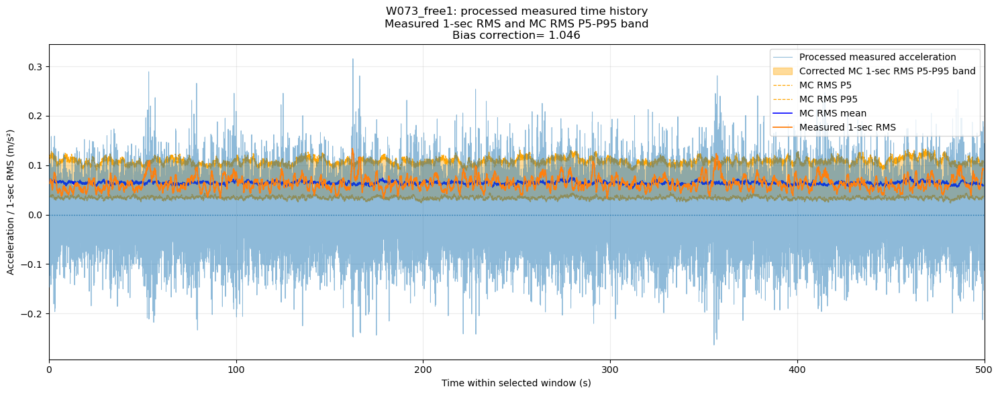


W073_free2
Window                     = 110-610 s
Correction factor          = 1.046
Number of MC simulations   = 100
Measured peak absolute     = 0.274956 m/s²
Measured peak 1-sec RMS    = 0.110566 m/s²
Mean MC peak 1-sec RMS     = 0.161225 m/s²


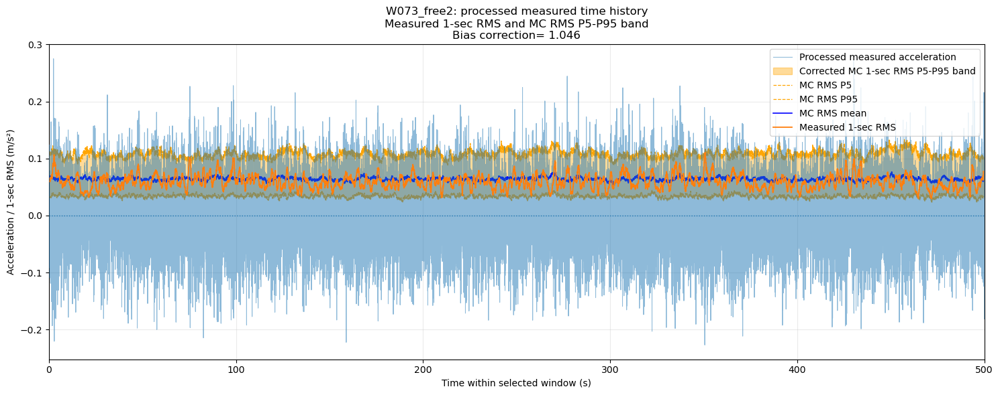


W073_free3
Window                     = 100-600 s
Correction factor          = 1.046
Number of MC simulations   = 100
Measured peak absolute     = 0.291699 m/s²
Measured peak 1-sec RMS    = 0.136640 m/s²
Mean MC peak 1-sec RMS     = 0.161170 m/s²


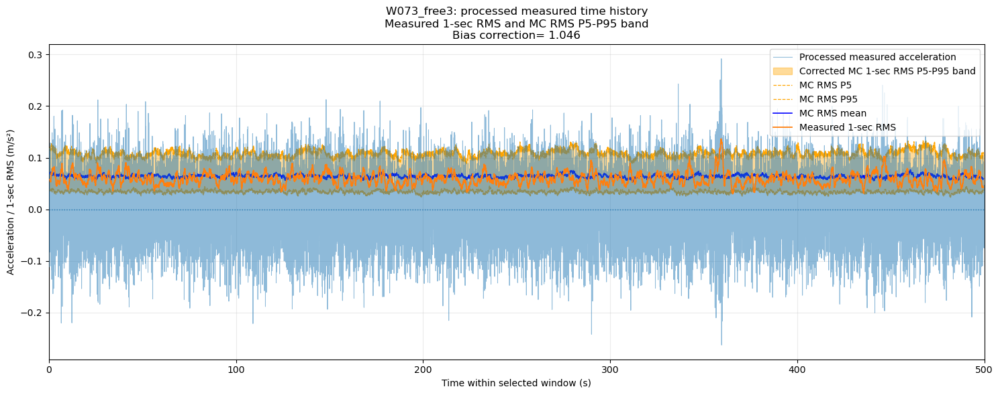


W073_free4
Window                     = 100-600 s
Correction factor          = 1.046
Number of MC simulations   = 100
Measured peak absolute     = 0.253848 m/s²
Measured peak 1-sec RMS    = 0.117081 m/s²
Mean MC peak 1-sec RMS     = 0.161170 m/s²


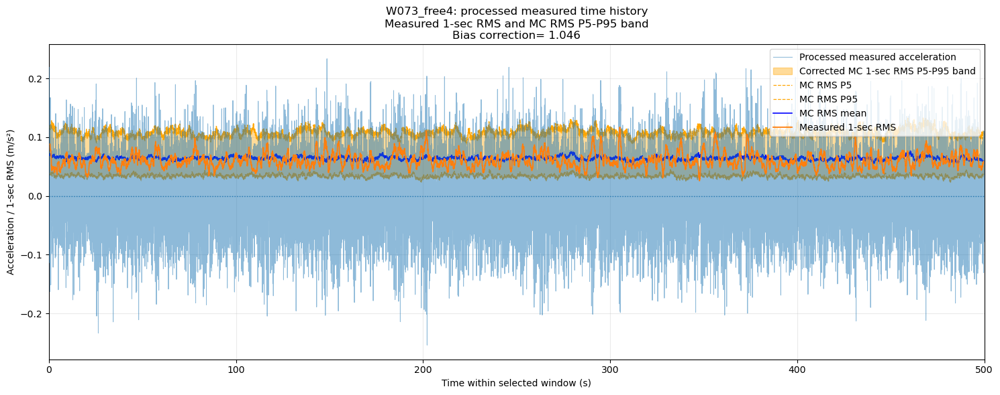

In [56]:
# ================================================================
# ALL FOUR EXPERIMENTS:
# PROCESSED MEASURED TIME HISTORY
# + MEASURED 1-SEC RMS
# + CORRECTED MC 1-SEC RMS P5-P95 BAND
#
# Run this AFTER the previous preprocessing / bias code.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# SETTINGS
# ================================================================

TESTS_TO_PLOT = [1, 2, 3, 4]

GLOBAL_CORRECTION_FACTOR = 1.046

LOWER_PERCENTILE = 5.0
UPPER_PERCENTILE = 95.0

PLOT_MC_RMS_MEDIAN = True

SAVE_FIGURES = False
FIGURE_DPI = 300


# ================================================================
# CHECK REQUIRED OBJECTS
# ================================================================

required_names = [
    "test_settings",
    "data_folder",
    "target_sensor",
    "mc_time",
    "mc_hht",
    "processed_mc_accelerations",
    "number_of_simulations",
    "load_measured_sensor",
    "preprocess_measured_signal",
    "select_window",
    "calculate_moving_rms",
    "RMS_WINDOW_SECONDS",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:

    raise NameError(
        "Run the previous preprocessing / bias code first.\n"
        "Missing objects:\n"
        + "\n".join(
            missing_names
        )
    )


# ================================================================
# CHECK TEST NUMBERS
# ================================================================

for test_number in TESTS_TO_PLOT:

    if test_number not in test_settings:

        raise ValueError(
            f"Test {test_number} is not available.\n"
            f"Available tests: {list(test_settings.keys())}"
        )


# ================================================================
# OPTIONAL STORAGE
# ================================================================

all_experiment_plot_results = {}


# ================================================================
# LOOP THROUGH ALL FOUR EXPERIMENTS
# ================================================================

for test_number in TESTS_TO_PLOT:

    # ------------------------------------------------------------
    # Test settings
    # ------------------------------------------------------------

    settings = test_settings[
        test_number
    ]

    measured_duration = float(
        settings[
            "duration"
        ]
    )

    start_time, end_time = (
        settings[
            "window"
        ]
    )

    selected_duration = (
        end_time
        - start_time
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )


    # ============================================================
    # LOAD AND PREPROCESS MEASURED SIGNAL
    # ============================================================

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    measured_time_full = (
        measured_processed[
            "time"
        ]
    )

    measured_acceleration_full = (
        measured_processed[
            "acceleration"
        ]
    )

    measured_dt = float(
        measured_processed[
            "dt"
        ]
    )

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_time_full,
        acceleration=measured_acceleration_full,
        start_time=start_time,
        end_time=end_time,
    )


    # ============================================================
    # MEASURED MOVING 1-SECOND RMS
    # ============================================================

    (
        measured_rms_time,
        measured_rms_history,
    ) = calculate_moving_rms(
        acceleration=measured_acceleration_window,
        dt=measured_dt,
        window_seconds=RMS_WINDOW_SECONDS,
    )


    # ============================================================
    # EXTRACT AND CORRECT SAME WINDOW FROM EVERY MC REALIZATION
    # ============================================================

    corrected_mc_windows = []

    simulated_time_window = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_simulated_time_window,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        if simulated_time_window is None:

            simulated_time_window = (
                current_simulated_time_window
            )

        elif len(
            current_simulated_time_window
        ) != len(
            simulated_time_window
        ):

            raise ValueError(
                f"W073_free{test_number}: the Monte Carlo "
                "windows do not all have the same length."
            )

        corrected_mc_windows.append(
            simulated_acceleration_window
            * GLOBAL_CORRECTION_FACTOR
        )

    corrected_mc_windows = np.asarray(
        corrected_mc_windows,
        dtype=float,
    )


    # ============================================================
    # MOVING 1-SECOND RMS FOR ALL CORRECTED MC REALIZATIONS
    # ============================================================

    corrected_mc_rms_histories = []

    simulated_rms_time = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_simulated_rms_time,
            simulated_rms_history,
        ) = calculate_moving_rms(
            acceleration=corrected_mc_windows[
                simulation_index
            ],
            dt=mc_hht,
            window_seconds=RMS_WINDOW_SECONDS,
        )

        if simulated_rms_time is None:

            simulated_rms_time = (
                current_simulated_rms_time
            )

        elif len(
            current_simulated_rms_time
        ) != len(
            simulated_rms_time
        ):

            raise ValueError(
                f"W073_free{test_number}: the Monte Carlo "
                "RMS histories do not all have the same length."
            )

        corrected_mc_rms_histories.append(
            simulated_rms_history
        )

    corrected_mc_rms_histories = np.asarray(
        corrected_mc_rms_histories,
        dtype=float,
    )


    # ============================================================
    # POINTWISE MC RMS STATISTICS
    # ============================================================

    mc_rms_p5 = np.percentile(
        corrected_mc_rms_histories,
        LOWER_PERCENTILE,
        axis=0,
    )

    mc_rms_p95 = np.percentile(
        corrected_mc_rms_histories,
        UPPER_PERCENTILE,
        axis=0,
    )

    mc_rms_median = np.percentile(
        corrected_mc_rms_histories,
        50,
        axis=0,
    )


    # ============================================================
    # STORE RESULTS
    # ============================================================

    all_experiment_plot_results[
        test_number
    ] = {
        "measured_time":
            measured_time_window,

        "measured_acceleration":
            measured_acceleration_window,

        "measured_rms_time":
            measured_rms_time,

        "measured_rms_history":
            measured_rms_history,

        "simulated_rms_time":
            simulated_rms_time,

        "corrected_mc_rms_histories":
            corrected_mc_rms_histories,

        "mc_rms_p5":
            mc_rms_p5,

        "mc_rms_p95":
            mc_rms_p95,

        "mc_rms_median":
            mc_rms_median,

        "correction_factor":
            GLOBAL_CORRECTION_FACTOR,
    }


    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    measured_peak_absolute = float(
        np.max(
            np.abs(
                measured_acceleration_window
            )
        )
    )

    measured_peak_rms = float(
        np.max(
            measured_rms_history
        )
    )

    mean_mc_peak_rms = float(
        np.mean(
            np.max(
                corrected_mc_rms_histories,
                axis=1,
            )
        )
    )

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 60
    )

    print(
        f"Window                     = "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    print(
        f"Correction factor          = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    print(
        f"Number of MC simulations   = "
        f"{number_of_simulations}"
    )

    print(
        f"Measured peak absolute     = "
        f"{measured_peak_absolute:.6f} m/s²"
    )

    print(
        f"Measured peak 1-sec RMS    = "
        f"{measured_peak_rms:.6f} m/s²"
    )

    print(
        f"Mean MC peak 1-sec RMS     = "
        f"{mean_mc_peak_rms:.6f} m/s²"
    )


    # ============================================================
    # PLOT THIS EXPERIMENT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(
            15,
            6,
        )
    )


    # ------------------------------------------------------------
    # Processed measured signed acceleration time history
    # ------------------------------------------------------------

    ax.plot(
        measured_time_window,
        measured_acceleration_window,
        linewidth=0.75,
        alpha=0.50,
        label="Processed measured acceleration",
        zorder=5,
    )


    # ------------------------------------------------------------
    # Corrected MC RMS P5-P95 band
    # ------------------------------------------------------------

    ax.fill_between(
        simulated_rms_time,
        mc_rms_p5,
        mc_rms_p95,
        color="orange",
        alpha=0.4,
        label=(
            f"Corrected MC 1-sec RMS "
            f"P{LOWER_PERCENTILE:.0f}-"
            f"P{UPPER_PERCENTILE:.0f} band"
        ),
        zorder=2,
    )


    # ------------------------------------------------------------
    # Dashed P5 and P95 boundaries
    # ------------------------------------------------------------

    ax.plot(
        simulated_rms_time,
        mc_rms_p5,
        color="orange",
        linestyle="--",
        linewidth=0.9,
        label=(
            f"MC RMS "
            f"P{LOWER_PERCENTILE:.0f}"
        ),
        zorder=3,
    )

    ax.plot(
        simulated_rms_time,
        mc_rms_p95,
        color="orange",
        linestyle="--",
        linewidth=0.9,
        label=(
            f"MC RMS "
            f"P{UPPER_PERCENTILE:.0f}"
        ),
        zorder=3,
    )


    # ------------------------------------------------------------
    # Optional corrected MC RMS median
    # ------------------------------------------------------------

    if PLOT_MC_RMS_MEDIAN:

        ax.plot(
            simulated_rms_time,
            mc_rms_median,
            color="blue",
            linewidth=1.2,
            label="MC RMS mean",
            zorder=4,
        )


    # ------------------------------------------------------------
    # Measured moving 1-second RMS
    # ------------------------------------------------------------

    ax.plot(
        measured_rms_time,
        measured_rms_history,
        linewidth=1.3,
        label="Measured 1-sec RMS",
        zorder=6,
    )


    # ------------------------------------------------------------
    # Axes and labels
    # ------------------------------------------------------------

    ax.axhline(
        0.0,
        linestyle=":",
        linewidth=1.0,
    )

    ax.set_xlim(
        0.0,
        selected_duration,
    )

    ax.set_xlabel(
        "Time within selected window (s)"
    )

    ax.set_ylabel(
        "Acceleration / 1-sec RMS (m/s²)"
    )

    ax.set_title(
        f"W073_free{test_number}: processed measured time history\n"
        f"Measured 1-sec RMS and MC RMS "
        f"P{LOWER_PERCENTILE:.0f}-P{UPPER_PERCENTILE:.0f} band\n"
        f"Bias correction= "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend(
        loc="upper right",
    )

    plt.tight_layout()


    # ============================================================
    # OPTIONAL SAVE
    # ============================================================

    if SAVE_FIGURES:

        output_name = (
            f"W073_free{test_number}_"
            f"measured_time_history_with_MC_RMS_band.png"
        )

        fig.savefig(
            output_name,
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

        print(
            f"Saved: {output_name}"
        )


    plt.show()


W073_free1
Window                         = 100-600 s
Correction factor              = 1.046
Measured retained peaks        = 3263
Measured peak absolute         = 0.315467 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


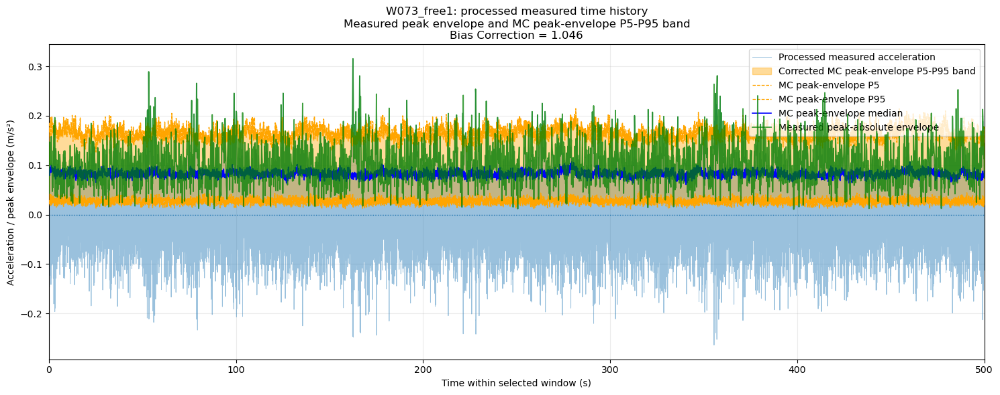


W073_free2
Window                         = 110-610 s
Correction factor              = 1.046
Measured retained peaks        = 3646
Measured peak absolute         = 0.274956 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


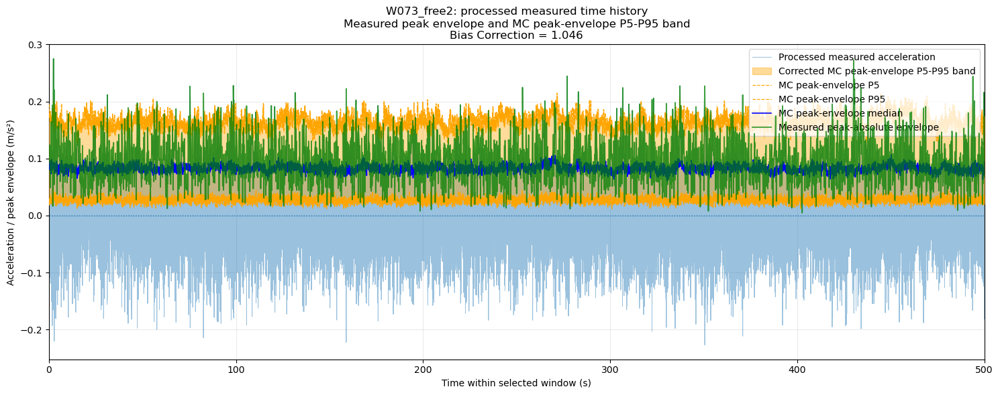


W073_free3
Window                         = 100-600 s
Correction factor              = 1.046
Measured retained peaks        = 3374
Measured peak absolute         = 0.291699 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


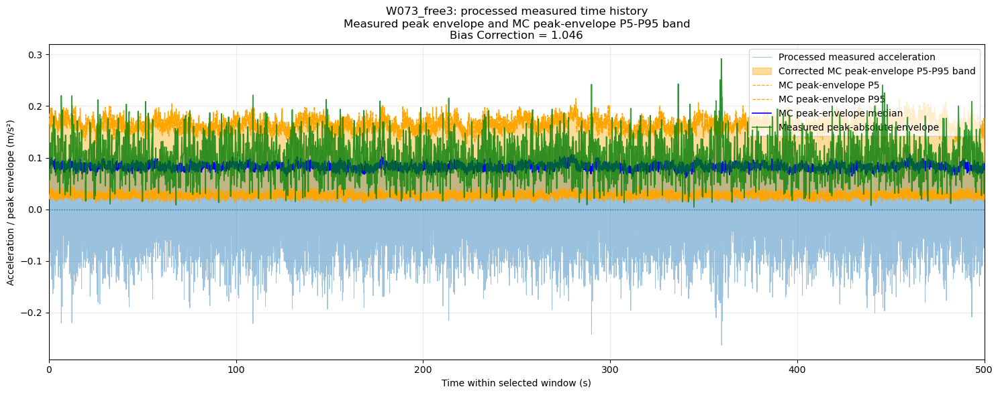


W073_free4
Window                         = 100-600 s
Correction factor              = 1.046
Measured retained peaks        = 3673
Measured peak absolute         = 0.253848 m/s²
Mean corrected-MC peak absolute = 0.286575 m/s²


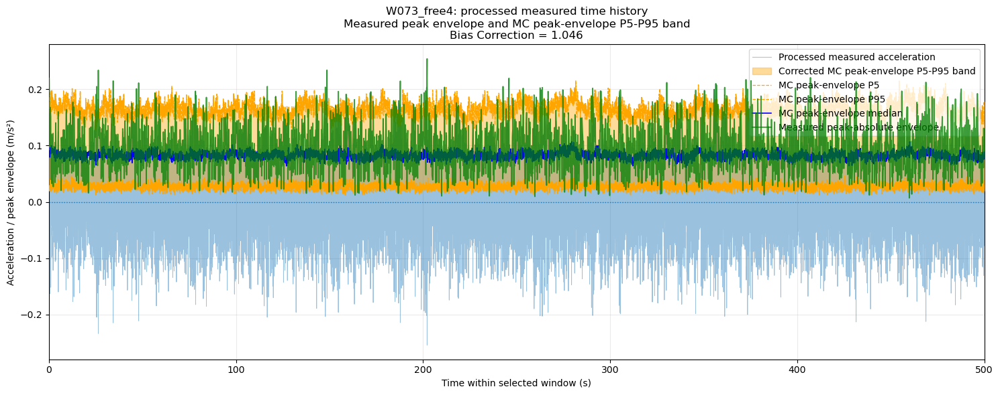

In [59]:
# ================================================================
# ALL FOUR EXPERIMENTS:
# PROCESSED MEASURED TIME HISTORY
# + MEASURED PEAK-ABSOLUTE ENVELOPE
# + CORRECTED MC PEAK-ENVELOPE P5-P95 BAND
#
# Run this AFTER the previous preprocessing / bias code.
#
# Definition used here:
#   1. Take the absolute value of an acceleration time history.
#   2. Find its local peaks.
#   3. Linearly interpolate between the local peaks to obtain a
#      continuous peak-envelope time history.
#
# Each corrected Monte Carlo realization therefore produces one
# peak-envelope time history. At each time step, the code calculates
# the P5, median, and P95 across all Monte Carlo peak envelopes.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks


# ================================================================
# SETTINGS
# ================================================================

TESTS_TO_PLOT = [1, 2, 3, 4]

GLOBAL_CORRECTION_FACTOR = 1.046

LOWER_PERCENTILE = 5.0
UPPER_PERCENTILE = 95.0

# Minimum time between retained peaks.
#
# 0.10 s allows at most about 10 retained absolute peaks per second.
# Increase this value for a smoother envelope.
# Set it to None to retain every local maximum.
MIN_PEAK_DISTANCE_SECONDS = 0.10

# Optional minimum peak prominence in m/s².
# Use None to impose no prominence threshold.
MIN_PEAK_PROMINENCE = None

PLOT_MC_ENVELOPE_MEDIAN = True

SAVE_FIGURES = False
FIGURE_DPI = 300


# ================================================================
# CHECK REQUIRED OBJECTS
# ================================================================

required_names = [
    "test_settings",
    "data_folder",
    "target_sensor",
    "mc_time",
    "mc_hht",
    "processed_mc_accelerations",
    "number_of_simulations",
    "load_measured_sensor",
    "preprocess_measured_signal",
    "select_window",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:

    raise NameError(
        "Run the previous preprocessing / bias code first.\n"
        "Missing objects:\n"
        + "\n".join(
            missing_names
        )
    )


# ================================================================
# PEAK-ENVELOPE FUNCTION
# ================================================================

def calculate_peak_absolute_envelope(
    acceleration,
    dt,
    minimum_peak_distance_seconds=0.10,
    minimum_peak_prominence=None,
):
    """
    Calculate a continuous upper envelope of |acceleration|.

    The function finds local maxima of the absolute acceleration and
    linearly interpolates between them.

    Parameters
    ----------
    acceleration : array-like
        Signed acceleration time history.

    dt : float
        Time step in seconds.

    minimum_peak_distance_seconds : float or None
        Minimum permitted time between retained peaks. Set to None
        to retain every local maximum.

    minimum_peak_prominence : float or None
        Optional minimum peak prominence in acceleration units.

    Returns
    -------
    envelope : ndarray
        Continuous peak-absolute envelope.

    peak_indices : ndarray
        Indices of the retained local peaks.

    peak_values : ndarray
        Absolute acceleration values at the retained peaks.
    """

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()

    if acceleration.ndim != 1:

        raise ValueError(
            "Acceleration must be one-dimensional."
        )

    if len(acceleration) < 3:

        raise ValueError(
            "At least three acceleration samples are required."
        )

    if dt <= 0.0:

        raise ValueError(
            "Time step must be positive."
        )

    absolute_acceleration = np.abs(
        acceleration
    )

    peak_arguments = {}

    if minimum_peak_distance_seconds is not None:

        distance_samples = max(
            1,
            int(
                round(
                    minimum_peak_distance_seconds
                    / dt
                )
            ),
        )

        peak_arguments[
            "distance"
        ] = distance_samples

    if minimum_peak_prominence is not None:

        peak_arguments[
            "prominence"
        ] = minimum_peak_prominence

    peak_indices, _ = find_peaks(
        absolute_acceleration,
        **peak_arguments,
    )

    if len(peak_indices) == 0:

        # Degenerate fallback: use a constant envelope.
        envelope = np.full_like(
            absolute_acceleration,
            np.max(
                absolute_acceleration
            ),
            dtype=float,
        )

        return (
            envelope,
            np.asarray(
                [
                    int(
                        np.argmax(
                            absolute_acceleration
                        )
                    )
                ],
                dtype=int,
            ),
            np.asarray(
                [
                    float(
                        np.max(
                            absolute_acceleration
                        )
                    )
                ],
                dtype=float,
            ),
        )

    peak_values = absolute_acceleration[
        peak_indices
    ]

    # Extend the first and last retained peak values to the ends of
    # the selected record. This avoids artificial envelope collapse
    # at t = 0 and at the final time.
    interpolation_indices = np.concatenate(
        (
            [0],
            peak_indices,
            [len(absolute_acceleration) - 1],
        )
    )

    interpolation_values = np.concatenate(
        (
            [peak_values[0]],
            peak_values,
            [peak_values[-1]],
        )
    )

    sample_indices = np.arange(
        len(
            absolute_acceleration
        ),
        dtype=float,
    )

    envelope = np.interp(
        sample_indices,
        interpolation_indices,
        interpolation_values,
    )

    # Numerical safeguard: the envelope should never fall below
    # the original absolute acceleration.
    envelope = np.maximum(
        envelope,
        absolute_acceleration,
    )

    return (
        envelope,
        peak_indices,
        peak_values,
    )


# ================================================================
# CHECK TEST NUMBERS
# ================================================================

for test_number in TESTS_TO_PLOT:

    if test_number not in test_settings:

        raise ValueError(
            f"Test {test_number} is not available.\n"
            f"Available tests: {list(test_settings.keys())}"
        )


# ================================================================
# OPTIONAL STORAGE
# ================================================================

all_peak_envelope_results = {}


# ================================================================
# LOOP THROUGH ALL FOUR EXPERIMENTS
# ================================================================

for test_number in TESTS_TO_PLOT:

    settings = test_settings[
        test_number
    ]

    measured_duration = float(
        settings[
            "duration"
        ]
    )

    start_time, end_time = (
        settings[
            "window"
        ]
    )

    selected_duration = (
        end_time
        - start_time
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )


    # ============================================================
    # LOAD AND PREPROCESS MEASURED SIGNAL
    # ============================================================

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    measured_time_full = (
        measured_processed[
            "time"
        ]
    )

    measured_acceleration_full = (
        measured_processed[
            "acceleration"
        ]
    )

    measured_dt = float(
        measured_processed[
            "dt"
        ]
    )

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_time_full,
        acceleration=measured_acceleration_full,
        start_time=start_time,
        end_time=end_time,
    )


    # ============================================================
    # MEASURED PEAK-ABSOLUTE ENVELOPE
    # ============================================================

    (
        measured_peak_envelope,
        measured_peak_indices,
        measured_peak_values,
    ) = calculate_peak_absolute_envelope(
        acceleration=measured_acceleration_window,
        dt=measured_dt,
        minimum_peak_distance_seconds=(
            MIN_PEAK_DISTANCE_SECONDS
        ),
        minimum_peak_prominence=(
            MIN_PEAK_PROMINENCE
        ),
    )


    # ============================================================
    # EXTRACT, CORRECT, AND ENVELOPE EVERY MC REALIZATION
    # ============================================================

    corrected_mc_windows = []
    corrected_mc_peak_envelopes = []

    simulated_time_window = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_simulated_time_window,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        if simulated_time_window is None:

            simulated_time_window = (
                current_simulated_time_window
            )

        elif len(
            current_simulated_time_window
        ) != len(
            simulated_time_window
        ):

            raise ValueError(
                f"W073_free{test_number}: the Monte Carlo "
                "windows do not all have the same length."
            )

        corrected_mc_window = (
            simulated_acceleration_window
            * GLOBAL_CORRECTION_FACTOR
        )

        (
            corrected_mc_peak_envelope,
            _,
            _,
        ) = calculate_peak_absolute_envelope(
            acceleration=corrected_mc_window,
            dt=mc_hht,
            minimum_peak_distance_seconds=(
                MIN_PEAK_DISTANCE_SECONDS
            ),
            minimum_peak_prominence=(
                MIN_PEAK_PROMINENCE
            ),
        )

        corrected_mc_windows.append(
            corrected_mc_window
        )

        corrected_mc_peak_envelopes.append(
            corrected_mc_peak_envelope
        )

    corrected_mc_windows = np.asarray(
        corrected_mc_windows,
        dtype=float,
    )

    corrected_mc_peak_envelopes = np.asarray(
        corrected_mc_peak_envelopes,
        dtype=float,
    )


    # ============================================================
    # POINTWISE MC PEAK-ENVELOPE STATISTICS
    # ============================================================

    mc_envelope_p5 = np.percentile(
        corrected_mc_peak_envelopes,
        LOWER_PERCENTILE,
        axis=0,
    )

    mc_envelope_p95 = np.percentile(
        corrected_mc_peak_envelopes,
        UPPER_PERCENTILE,
        axis=0,
    )

    mc_envelope_median = np.percentile(
        corrected_mc_peak_envelopes,
        50,
        axis=0,
    )


    # ============================================================
    # STORE RESULTS
    # ============================================================

    all_peak_envelope_results[
        test_number
    ] = {
        "measured_time":
            measured_time_window,

        "measured_acceleration":
            measured_acceleration_window,

        "measured_peak_envelope":
            measured_peak_envelope,

        "measured_peak_indices":
            measured_peak_indices,

        "measured_peak_values":
            measured_peak_values,

        "simulated_time":
            simulated_time_window,

        "corrected_mc_windows":
            corrected_mc_windows,

        "corrected_mc_peak_envelopes":
            corrected_mc_peak_envelopes,

        "mc_envelope_p5":
            mc_envelope_p5,

        "mc_envelope_p95":
            mc_envelope_p95,

        "mc_envelope_median":
            mc_envelope_median,

        "correction_factor":
            GLOBAL_CORRECTION_FACTOR,
    }


    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    measured_peak_absolute = float(
        np.max(
            np.abs(
                measured_acceleration_window
            )
        )
    )

    mean_mc_peak_absolute = float(
        np.mean(
            np.max(
                np.abs(
                    corrected_mc_windows
                ),
                axis=1,
            )
        )
    )

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 60
    )

    print(
        f"Window                         = "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    print(
        f"Correction factor              = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    print(
        f"Measured retained peaks        = "
        f"{len(measured_peak_indices)}"
    )

    print(
        f"Measured peak absolute         = "
        f"{measured_peak_absolute:.6f} m/s²"
    )

    print(
        f"Mean corrected-MC peak absolute = "
        f"{mean_mc_peak_absolute:.6f} m/s²"
    )


    # ============================================================
    # PLOT THIS EXPERIMENT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(
            15,
            6,
        )
    )


    # ------------------------------------------------------------
    # Processed measured signed acceleration time history
    # ------------------------------------------------------------

    ax.plot(
        measured_time_window,
        measured_acceleration_window,
        linewidth=0.70,
        alpha=0.45,
        label="Processed measured acceleration",
        zorder=2,
    )


    # ------------------------------------------------------------
    # Corrected MC peak-envelope P5-P95 band
    # ------------------------------------------------------------

    ax.fill_between(
        simulated_time_window,
        mc_envelope_p5,
        mc_envelope_p95,
        color="orange",
        alpha=0.4,
        label=(
            f"Corrected MC peak-envelope "
            f"P{LOWER_PERCENTILE:.0f}-"
            f"P{UPPER_PERCENTILE:.0f} band"
        ),
        zorder=3,
    )


    # ------------------------------------------------------------
    # Dashed P5 and P95 boundaries
    # ------------------------------------------------------------

    ax.plot(
        simulated_time_window,
        mc_envelope_p5,
        color="orange",
        linestyle="--",
        linewidth=0.9,
        label=(
            f"MC peak-envelope "
            f"P{LOWER_PERCENTILE:.0f}"
        ),
        zorder=4,
    )

    ax.plot(
        simulated_time_window,
        mc_envelope_p95,
        color="orange",
        linestyle="--",
        linewidth=0.9,
        label=(
            f"MC peak-envelope "
            f"P{UPPER_PERCENTILE:.0f}"
        ),
        zorder=4,
    )


    # ------------------------------------------------------------
    # Optional corrected MC peak-envelope median
    # ------------------------------------------------------------

    if PLOT_MC_ENVELOPE_MEDIAN:

        ax.plot(
            simulated_time_window,
            mc_envelope_median,
            color="blue",
            linewidth=1.2,
            label="MC peak-envelope median",
            zorder=5,
        )


    # ------------------------------------------------------------
    # Measured peak-absolute envelope
    # ------------------------------------------------------------

    ax.plot(
        measured_time_window,
        measured_peak_envelope,
        linewidth=1.3,
        label="Measured peak-absolute envelope",
        color="green",
        alpha=0.75,
        zorder=6,
    )


    # ------------------------------------------------------------
    # Axes and labels
    # ------------------------------------------------------------

    ax.axhline(
        0.0,
        linestyle=":",
        linewidth=1.0,
    )

    ax.set_xlim(
        0.0,
        selected_duration,
    )

    ax.set_xlabel(
        "Time within selected window (s)"
    )

    ax.set_ylabel(
        "Acceleration / peak envelope (m/s²)"
    )

    ax.set_title(
        f"W073_free{test_number}: processed measured time history\n"
        f"Measured peak envelope and MC peak-envelope "
        f"P{LOWER_PERCENTILE:.0f}-P{UPPER_PERCENTILE:.0f} band\n"
        f"Bias Correction = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend(
        loc="upper right",
    )

    plt.tight_layout()


    # ============================================================
    # OPTIONAL SAVE
    # ============================================================

    if SAVE_FIGURES:

        output_name = (
            f"W073_free{test_number}_"
            f"measured_time_history_with_MC_peak_envelope_band.png"
        )

        fig.savefig(
            output_name,
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

        print(
            f"Saved: {output_name}"
        )

    plt.show()


W073_free1
Window                         = 100-600 s
Correction factor              = 1.046
Number of MC realizations      = 100
Measured P95 absolute          = 0.127299 m/s²
Maximum pointwise MC P95       = 0.196345 m/s²


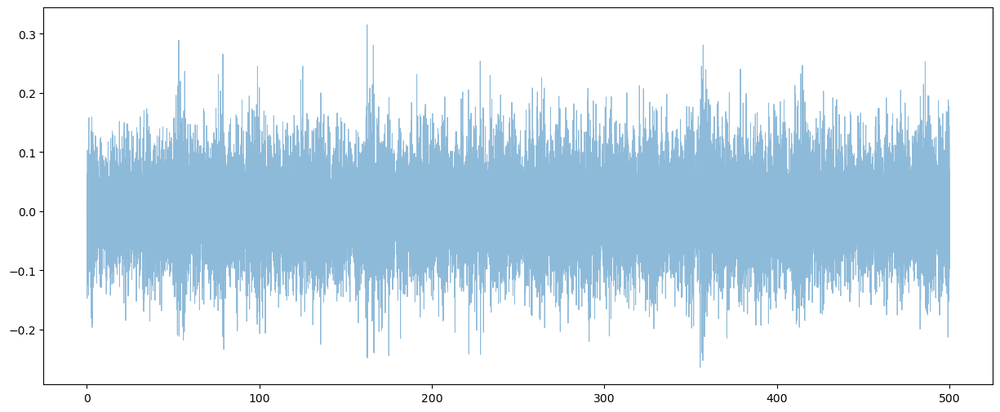

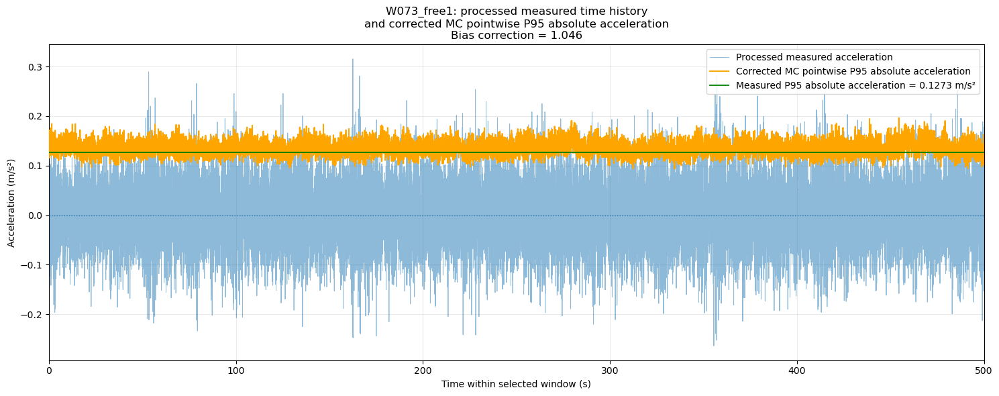


W073_free2
Window                         = 110-610 s
Correction factor              = 1.046
Number of MC realizations      = 100
Measured P95 absolute          = 0.119176 m/s²
Maximum pointwise MC P95       = 0.196345 m/s²


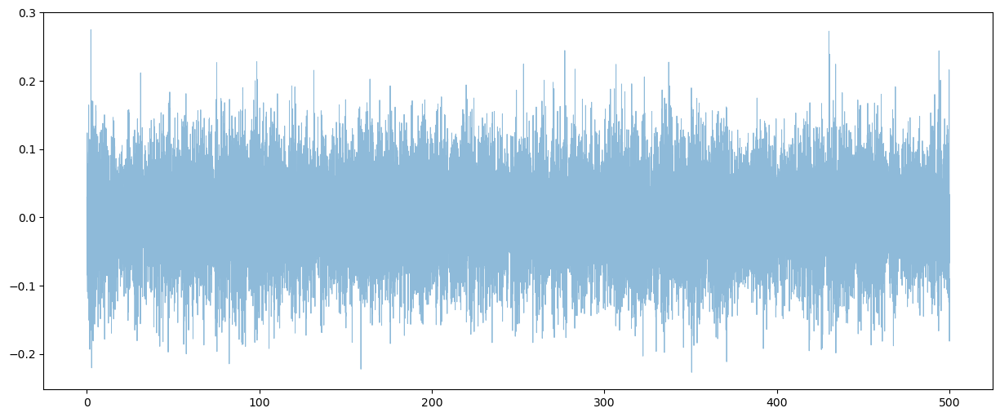

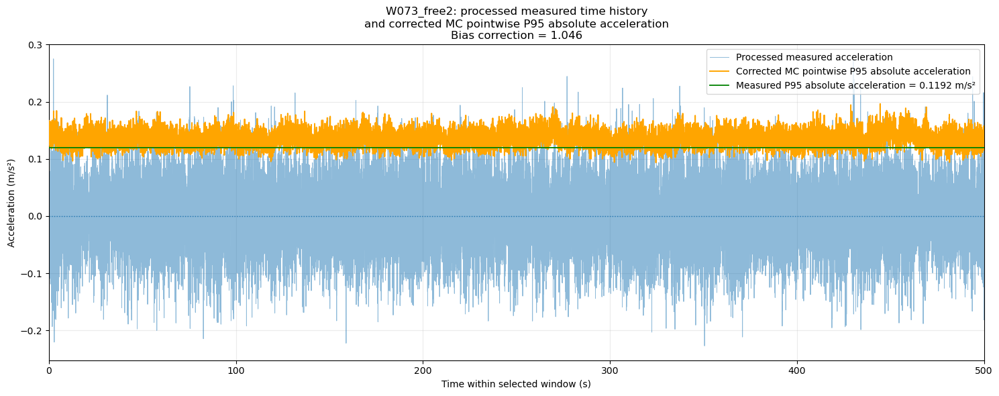


W073_free3
Window                         = 100-600 s
Correction factor              = 1.046
Number of MC realizations      = 100
Measured P95 absolute          = 0.119336 m/s²
Maximum pointwise MC P95       = 0.196345 m/s²


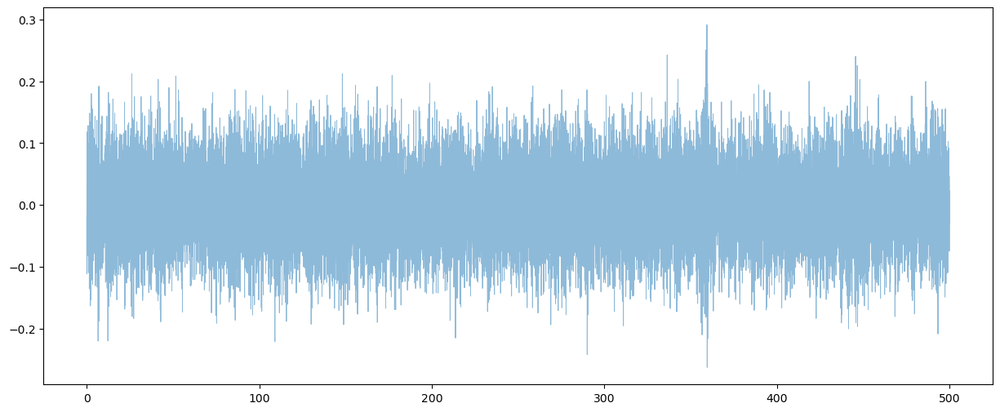

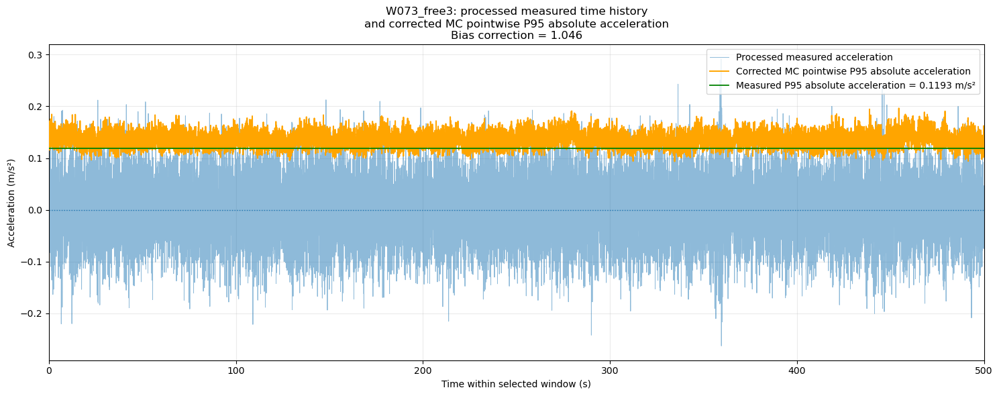


W073_free4
Window                         = 100-600 s
Correction factor              = 1.046
Number of MC realizations      = 100
Measured P95 absolute          = 0.120953 m/s²
Maximum pointwise MC P95       = 0.196345 m/s²


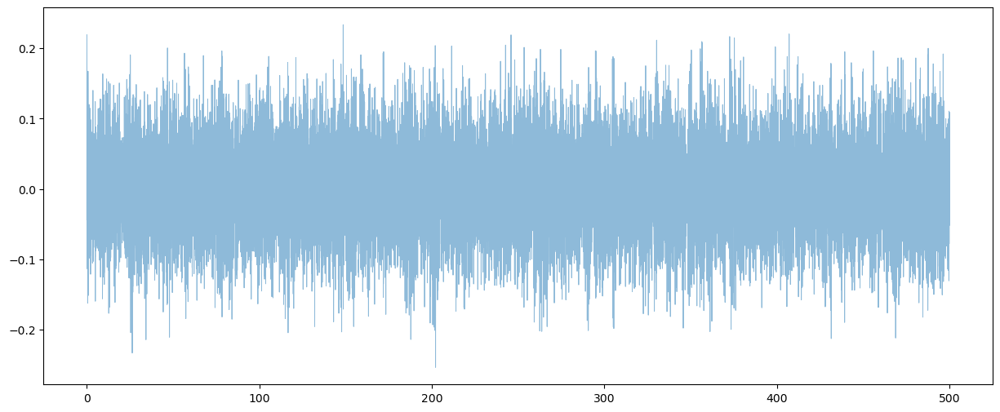

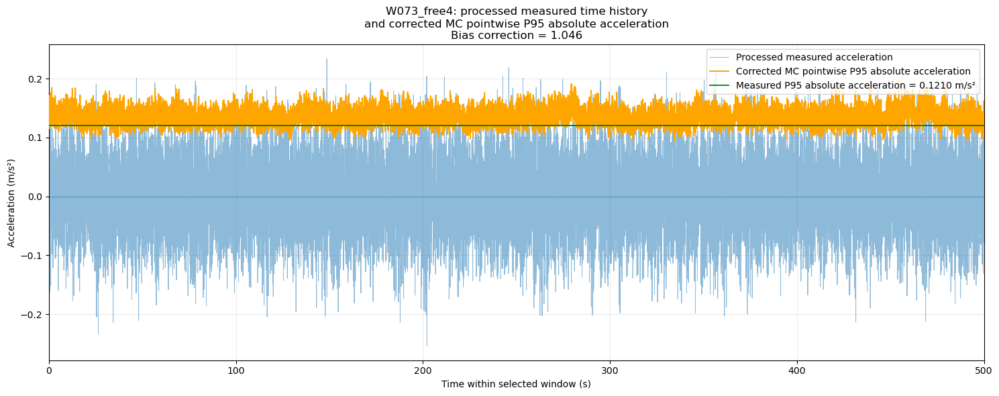

In [62]:
# ================================================================
# ALL FOUR EXPERIMENTS:
# PROCESSED MEASURED TIME HISTORY
# + POINTWISE CORRECTED-MC P95 ABSOLUTE ACCELERATION HISTORY
#
# Run this AFTER the previous preprocessing / bias code.
#
# At each time step t:
#
#   MC P95 absolute acceleration(t)
#       = P95 across all corrected MC values |a_i(t)|
#
# This produces ONE pointwise P95 MC time history for each experiment.
#
# The processed measured signal is plotted as a signed time history.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# SETTINGS
# ================================================================

TESTS_TO_PLOT = [1, 2, 3, 4]

GLOBAL_CORRECTION_FACTOR = 1.046

LOWER_PERCENTILE = 5.0
UPPER_PERCENTILE = 95.0

# Optional supporting curves
PLOT_MC_P5_P95_BAND = True
PLOT_MC_MEDIAN_ABSOLUTE = True

SAVE_FIGURES = False
FIGURE_DPI = 300


# ================================================================
# CHECK REQUIRED OBJECTS
# ================================================================

required_names = [
    "test_settings",
    "data_folder",
    "target_sensor",
    "mc_time",
    "processed_mc_accelerations",
    "number_of_simulations",
    "load_measured_sensor",
    "preprocess_measured_signal",
    "select_window",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:

    raise NameError(
        "Run the previous preprocessing / bias code first.\n"
        "Missing objects:\n"
        + "\n".join(
            missing_names
        )
    )


# ================================================================
# CHECK TEST NUMBERS
# ================================================================

for test_number in TESTS_TO_PLOT:

    if test_number not in test_settings:

        raise ValueError(
            f"Test {test_number} is not available.\n"
            f"Available tests: {list(test_settings.keys())}"
        )


# ================================================================
# OPTIONAL STORAGE
# ================================================================

all_pointwise_p95_results = {}


# ================================================================
# LOOP THROUGH ALL FOUR EXPERIMENTS
# ================================================================

for test_number in TESTS_TO_PLOT:

    settings = test_settings[
        test_number
    ]

    measured_duration = float(
        settings[
            "duration"
        ]
    )

    start_time, end_time = (
        settings[
            "window"
        ]
    )

    selected_duration = (
        end_time
        - start_time
    )

    mat_file = data_folder / (
        f"W073_free{test_number}.mat"
    )


    # ============================================================
    # LOAD AND PREPROCESS MEASURED SIGNAL
    # ============================================================

    measured_acceleration_raw = (
        load_measured_sensor(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )

    measured_processed = (
        preprocess_measured_signal(
            acceleration=measured_acceleration_raw,
            duration=measured_duration,
        )
    )

    (
        measured_time_window,
        measured_acceleration_window,
    ) = select_window(
        time=measured_processed[
            "time"
        ],
        acceleration=measured_processed[
            "acceleration"
        ],
        start_time=start_time,
        end_time=end_time,
    )


    # ============================================================
    # EXTRACT AND CORRECT THE SAME WINDOW FROM EVERY MC RUN
    # ============================================================

    corrected_mc_windows = []

    simulated_time_window = None

    for simulation_index in range(
        number_of_simulations
    ):

        (
            current_simulated_time_window,
            simulated_acceleration_window,
        ) = select_window(
            time=mc_time,
            acceleration=processed_mc_accelerations[
                simulation_index
            ],
            start_time=start_time,
            end_time=end_time,
        )

        if simulated_time_window is None:

            simulated_time_window = (
                current_simulated_time_window
            )

        elif len(
            current_simulated_time_window
        ) != len(
            simulated_time_window
        ):

            raise ValueError(
                f"W073_free{test_number}: the Monte Carlo "
                "windows do not all have the same length."
            )

        corrected_mc_windows.append(
            simulated_acceleration_window
            * GLOBAL_CORRECTION_FACTOR
        )

    corrected_mc_windows = np.asarray(
        corrected_mc_windows,
        dtype=float,
    )


    # ============================================================
    # POINTWISE ABSOLUTE-ACCELERATION STATISTICS
    #
    # Shape before percentile:
    #     number_of_simulations × number_of_time_steps
    #
    # axis=0 means the percentile is calculated across the MC
    # realizations independently at every time step.
    # ============================================================

    corrected_mc_absolute = np.abs(
        corrected_mc_windows
    )

    mc_absolute_p5 = np.percentile(
        corrected_mc_absolute,
        LOWER_PERCENTILE,
        axis=0,
    )

    mc_absolute_median = np.percentile(
        corrected_mc_absolute,
        50,
        axis=0,
    )

    mc_absolute_p95 = np.percentile(
        corrected_mc_absolute,
        UPPER_PERCENTILE,
        axis=0,
    )


    # ============================================================
    # MEASURED GLOBAL P95 ABSOLUTE VALUE
    #
    # This is one scalar calculated over the complete selected
    # measured window. It is included as an optional horizontal
    # reference because there is only one measured realization.
    # ============================================================

    measured_p95_absolute = float(
        np.percentile(
            np.abs(
                measured_acceleration_window
            ),
            95,
        )
    )


    # ============================================================
    # STORE RESULTS
    # ============================================================

    all_pointwise_p95_results[
        test_number
    ] = {
        "correction_factor":
            GLOBAL_CORRECTION_FACTOR,

        "measured_time":
            measured_time_window,

        "measured_acceleration":
            measured_acceleration_window,

        "measured_p95_absolute":
            measured_p95_absolute,

        "simulated_time":
            simulated_time_window,

        "corrected_mc_windows":
            corrected_mc_windows,

        "mc_absolute_p5":
            mc_absolute_p5,

        "mc_absolute_median":
            mc_absolute_median,

        "mc_absolute_p95":
            mc_absolute_p95,
    }


    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    print(
        f"\nW073_free{test_number}"
    )

    print(
        "=" * 60
    )

    print(
        f"Window                         = "
        f"{start_time:.0f}-{end_time:.0f} s"
    )

    print(
        f"Correction factor              = "
        f"{GLOBAL_CORRECTION_FACTOR:.3f}"
    )

    print(
        f"Number of MC realizations      = "
        f"{number_of_simulations}"
    )

    print(
        f"Measured P95 absolute          = "
        f"{measured_p95_absolute:.6f} m/s²"
    )

    print(
        f"Maximum pointwise MC P95       = "
        f"{np.max(mc_absolute_p95):.6f} m/s²"
    )


    # ============================================================
    # PLOT THIS EXPERIMENT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(
            15,
            6,
        )
    )


    # ------------------------------------------------------------
    # Processed measured signed acceleration
    # ------------------------------------------------------------

    ax.plot(
        measured_time_window,
        measured_acceleration_window,
        linewidth=0.70,
        alpha=0.50,
        label="Processed measured acceleration",
        zorder=2,
    )


    # ------------------------------------------------------------
    # Optional pointwise MC P5-P95 absolute band
    # ------------------------------------------------------------

    if PLOT_MC_P5_P95_BAND:

            # ================================================================
        # POINTWISE MC P95 ABSOLUTE ACCELERATION
        # ================================================================

        corrected_mc_absolute = np.abs(
            corrected_mc_windows
        )

        # At every time step, calculate P95 across all MC realizations
        mc_absolute_p95 = np.percentile(
            corrected_mc_absolute,
            95,
            axis=0,
        )


        # ================================================================
        # MEASURED P95 ABSOLUTE ACCELERATION
        # ================================================================

        measured_p95_absolute = float(
            np.percentile(
                np.abs(
                    measured_acceleration_window
                ),
                95,
            )
        )


        # ================================================================
        # PLOT
        # ================================================================

        fig, ax = plt.subplots(
            figsize=(15, 6)
        )


        # ------------------------------------------------
        # Processed measured signed acceleration
        # ------------------------------------------------

        ax.plot(
            measured_time_window,
            measured_acceleration_window,
            linewidth=0.70,
            alpha=0.50,
            label="Processed measured acceleration",
            zorder=2,
        )


        # ------------------------------------------------
        # Corrected MC pointwise P95 absolute acceleration
        # ------------------------------------------------

        ax.plot(
            simulated_time_window,
            mc_absolute_p95,
            color="orange",
            linewidth=1.4,
            label="Corrected MC pointwise P95 absolute acceleration",
            zorder=5,
        )


        # ------------------------------------------------
        # Measured overall P95 absolute acceleration
        # ------------------------------------------------

        ax.axhline(
            measured_p95_absolute,
            color="green",
            linewidth=1.3,
            label=(
                f"Measured P95 absolute acceleration = "
                f"{measured_p95_absolute:.4f} m/s²"
            ),
            zorder=6,
        )


        # ------------------------------------------------
        # Axes
        # ------------------------------------------------

        ax.axhline(
            0.0,
            linestyle=":",
            linewidth=1.0,
        )

        ax.set_xlim(
            0.0,
            selected_duration,
        )

        ax.set_xlabel(
            "Time within selected window (s)"
        )

        ax.set_ylabel(
            "Acceleration (m/s²)"
        )

        ax.set_title(
            f"W073_free{test_number}: processed measured time history\n"
            f"and corrected MC pointwise P95 absolute acceleration\n"
            f"Bias correction = {GLOBAL_CORRECTION_FACTOR:.3f}"
        )

        ax.grid(
            True,
            alpha=0.25,
        )

        ax.legend(
            loc="upper right",
        )

        plt.tight_layout()
        plt.show()